Connected to geo_env (Python 3.11.9)

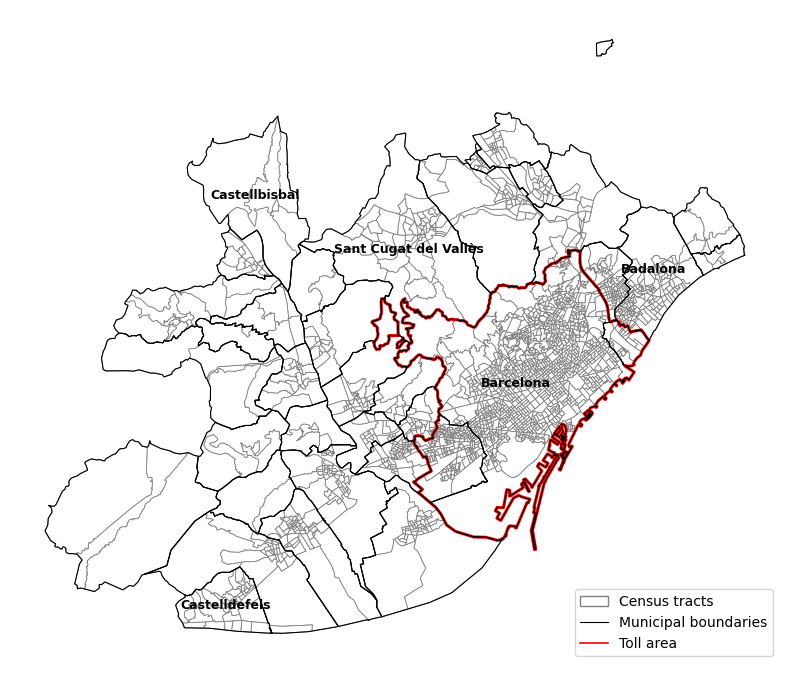

                            OLS Regression Results                            
Dep. Variable:                  log_h   R-squared:                       0.163
Model:                            OLS   Adj. R-squared:                  0.163
Method:                 Least Squares   F-statistic:                     329.2
Date:                Thu, 12 Feb 2026   Prob (F-statistic):           2.37e-67
Time:                        09:47:58   Log-Likelihood:                -2167.1
No. Observations:                1688   AIC:                             4338.
Df Residuals:                    1686   BIC:                             4349.
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const         -5.3751      0.281    -19.105      0.0

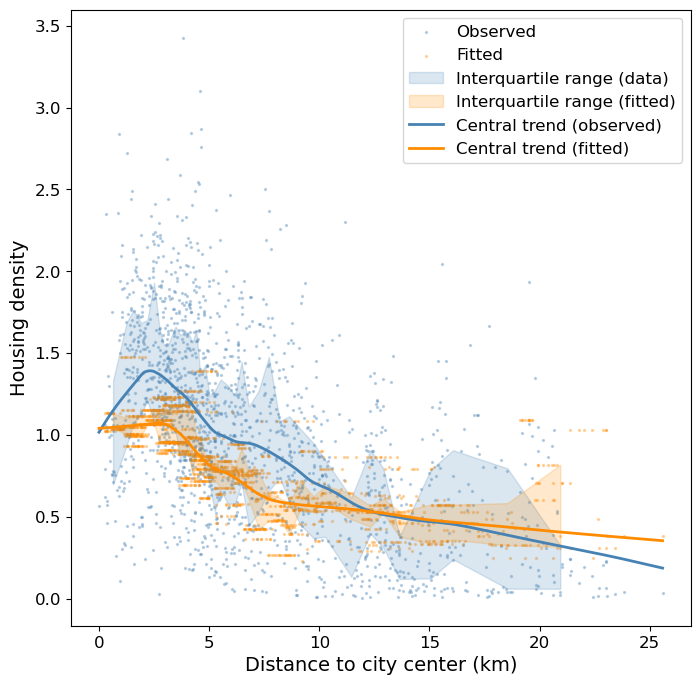

FIXED_COST_CAR:  163.82038719410997
LAMBDA:  272.8823655623842


KeyError: 'share_car'

In [ ]:
import numpy as np 
from copy import deepcopy
from scipy.sparse import csr_matrix # type: ignore
import pickle
import datetime

from outcomes import *
from ABM import *
from import_data import * # type: ignore
from calibration import * # type: ignore
from model import * # type: ignore
from plotting_tools import * # type: ignore
from import_transport import *
from policy_support import *

### SCENARIOS

scenario = "baseline"

#scenario = "exemption_trips_inside_zone"    #DONE
#scenario = "tax_question_P17"               #DONE
#scenario = "increasing_knowledge"           #DONE
#scenario = "instant_welfare_adjust"         #DONE
#scenario = "discount_low_income"            #DONE
#scenario = "discount_residents"             #DONE

#scenario = "less_expensive_transport"       #DONE
#scenario = "improve_rodalies"               #DONE
#scenario = "reduce_transport_time"          #DONE

### IMPORT PARAMETERS

path_data = "../data_barcelona/"
option_function = "Cobb-Douglas"

LOGISTIC_PARAM_WELFARE = -0.3
LOGISTIC_PARAM_QOL = 0.3

#Time
year = 0
MAX_YEAR = 20

#Policy impact model
INTEREST_RATE = 0.05
PRICE_TIME = 10 #euros/h - later modulated by income level
WORKING_DAYS = 40 #20 days per month, with 2 trips per day
PRICE_FUEL = 0.11 #euros/km
center = "0801901025"
SOFT_RENT = 50
DIFF_SPEED_CONGESTION = 10

#ABM
SCALE_ABM = 1/100 #Nb of agents in the ABM
PROBA_MOVE = 0.2
INERTIA_OPINION = 0.8 #inertia

### IMPORT DATA

#Import data
gdf = import_data(path_data, center, option = "SECTION") #"DISTRICT" or "SECTION" - Active population: 1.4M
gdf = import_jobs(gdf, path_data)
gdf = import_land_use(gdf, path_data)
gdf = import_ppl_per_hh(gdf, path_data)
gdf = import_rent_and_size(gdf, path_data)
Y_median, gdf = import_income_new(gdf, path_data)
gdf = import_amenities(gdf, path_data, 0, 0)
employment_centers = gpd.read_file(path_data + "cluster_employment_UEA.shp")
employment_centers["cluster"] = employment_centers.index
jobs_in_toll_area, houses_in_toll_area, zone_tax = import_tax_zone(gdf, employment_centers)
plot_base_map(gdf)

#Multiple income groups
income_levels = ["LOW", "MED", "HIGH"]
wage_factors = {"LOW": 0.6, "MED": 1.0, "HIGH": 1.4}
pop = {
    "LOW": np.nansum(gdf["pop"] * gdf["share_low_income"] / 100),
    "MED": np.nansum(gdf["pop"] * (100 - gdf["share_high_income"] - gdf["share_low_income"]) / 100),
    "HIGH": np.nansum(gdf["pop"] * gdf["share_high_income"] / 100),
}

#Prepare variables
gdf["size"] = gdf["size_census"] #gdf["size_census"] #gdf["size_AMB"]
gdf.loc[gdf["pop"] == 0, "pop"] = 1
gdf.loc[gdf["rent_m2"] == 0, "rent_m2"] = np.nanmin(gdf.loc[gdf["rent_m2"]>0, "rent_m2"])
gdf.loc[np.isnan(gdf["rent_m2"]), "rent_m2"] = np.nanmin(gdf.loc[gdf["rent_m2"]>0, "rent_m2"])
gdf.loc[np.isnan(gdf["size"]), "size"] = np.nansum(gdf.loc[~np.isnan(gdf["size"]), "size"] * gdf.loc[~np.isnan(gdf["size"]), "pop"]) / np.nansum(gdf.loc[~np.isnan(gdf["size"]), "pop"])

#Import transport data
#import_transport_times_poly(gdf, datetime.datetime(2025, 7, 15, 8, 0, 0), center, path_data, employment_centers) #datetime.datetime(2025, 7, 15, 8, 0, 0)
travel_time_matrix_car, travel_time_matrix_transit = load_transport_times_poly(gdf, path_data, center)
travel_time_matrix_car = load_distance_car_poly(travel_time_matrix_car, gdf, employment_centers, jobs_in_toll_area, houses_in_toll_area, zone_tax)
gdf = import_cost_transit(gdf)
travel_time_matrix_transit = travel_time_matrix_transit.merge(gdf[['ID', 'monthly_cost_transit']].rename(columns={'ID': 'from_id'}), on='from_id', how='left')

travel_time_matrix_car["uncongested_speed"] = (travel_time_matrix_car.distance_car / 1000) / (travel_time_matrix_car.travel_time / 60)
travel_time_matrix_car["speed"] = travel_time_matrix_car["uncongested_speed"] - DIFF_SPEED_CONGESTION
travel_time_matrix_car.loc[travel_time_matrix_car["speed"] < 10, "speed"] = 10
travel_time_matrix_car.travel_time = ((travel_time_matrix_car.distance_car / 1000) / travel_time_matrix_car["speed"]) * 60

### CALIBRATION POLICY SUPPORT

#BETA_OPINION, INITIAL_OPINION = import_opinion_parameters(path_data, scenario)
#BETA_PRICE, INITIAL_PRICE, INITIAL_CC, INITIAL_WELFARE, INITIAL_QOL, INITIAL_KNOWLEDGE = import_price_parameters(path_data, scenario)


### CALIBRATION POLICY IMPACT MODEL

#Calibration of B and KAPPA
gdf["land"] = gdf["urb_area"]

mask = ((gdf["rent_m2"] < 25) &(gdf["rent_m2"] > 7)&
        (gdf["pop"] > 484.0)&
        (~np.isnan(gdf["size"]))
        &(~np.isnan(gdf["pop"]))
        &((gdf["pop"] > 0))
        )

B, KAPPA, SIGMA = calibrate_b_kappa(gdf, mask, INTEREST_RATE, option_function, option_calib = "housing")

#Transport cost calibration
#gdf, FIXED_COST_CAR, LAMBDA, ARRAY_WAGE_LOW, ARRAY_WAGE_MED, ARRAY_WAGE_HIGH = compute_cost_car_poly_i(gdf, Y_median, import_trans_mode, PRICE_TIME, WORKING_DAYS, PRICE_FUEL, travel_time_matrix_car, travel_time_matrix_transit, employment_centers, path_data, jobs_in_toll_area, houses_in_toll_area, income_levels, wage_factors, scenario, compute_error_transport_poly)
#with open(path_data + "calib_trans_poly_i_UEA_v2.pkl", "wb") as f:
#    pickle.dump((FIXED_COST_CAR, LAMBDA, ARRAY_WAGE_LOW, ARRAY_WAGE_MED, ARRAY_WAGE_HIGH), f)
with open(path_data + "calib_trans_poly_i_UEA_v2.pkl", "rb") as f:
    FIXED_COST_CAR, LAMBDA, ARRAY_WAGE_LOW, ARRAY_WAGE_MED, ARRAY_WAGE_HIGH = pickle.load(f)
print("FIXED_COST_CAR: ", FIXED_COST_CAR)
print("LAMBDA: ", LAMBDA)
compute_error_transport_poly([FIXED_COST_CAR, LAMBDA] + list(ARRAY_WAGE_LOW) + list(ARRAY_WAGE_MED) + list(ARRAY_WAGE_HIGH), employment_centers, gdf, travel_time_matrix_car, travel_time_matrix_transit, PRICE_TIME, WORKING_DAYS, PRICE_FUEL, jobs_in_toll_area, houses_in_toll_area, income_levels, wage_factors, scenario, Y_median)
del compute_transport_cost_logit, compute_cost_car_logit

#Compute transport cost
gdf, workers_per_cluster, travel_matrix = compute_transport_cost_poly_i(gdf, travel_time_matrix_car, travel_time_matrix_transit, PRICE_TIME, WORKING_DAYS, FIXED_COST_CAR, PRICE_FUEL, LAMBDA, ARRAY_WAGE_LOW, ARRAY_WAGE_MED, ARRAY_WAGE_HIGH, jobs_in_toll_area, houses_in_toll_area, 0, income_levels, wage_factors, scenario)
print("Modal share of public transport (%):", round(100 * sum(np.nansum(gdf[f"transport_mode_{lvl}"] * gdf[f"pop_{lvl}"]) for lvl in income_levels) / sum(np.nansum(gdf[f"pop_{lvl}"]) for lvl in income_levels)))
print("Modal share of public transport (%):", round(100 * (np.nansum(gdf["transport_mode_HIGH"] * gdf["pop_HIGH"])) / (np.nansum(gdf["pop_HIGH"]))))
print("Modal share of public transport (%):", round(100 * (np.nansum(gdf[f"transport_mode_MED"] * gdf[f"pop_MED"])) / (np.nansum(gdf[f"pop_MED"]))))
print("Modal share of public transport (%):", round(100 * (np.nansum(gdf[f"transport_mode_LOW"] * gdf[f"pop_LOW"])) / (np.nansum(gdf[f"pop_LOW"]))))
plot_transport_cost_i(gdf, "_HIGH")
plot_transport_mode_i(gdf, "_HIGH")
plot_employment(gdf, employment_centers, employment_centers['employment'] * 0.0015)

#Calibrate beta and amenities
def compute_log_likelihood(x):
    print(x)
    return calibration_utility_amenity2(x, gdf, income_levels, SOFT_RENT, 0, 0)

calib_beta = scipy.optimize.minimize(compute_log_likelihood, [0.3, 100, 500, 900], bounds=[(0.25,0.5), (0,None), (0,None), (0,None)]) #[0.45, 100, 500, 900] #[0.3, 224, 386, 553]
BETA = calib_beta.x[0]
print("BETA:", BETA)
amenities = calibration_utility_amenity(calib_beta.x, gdf, income_levels, SOFT_RENT, 1, 1)
gdf = gdf.merge(amenities, on = "ID", how = "left")
gdf.loc[np.isnan(gdf["amenities"]), "amenities"] = 1
gdf.loc[np.isnan(gdf["amenities_improved_rodalies"]), "amenities_improved_rodalies"] = 1

# Solve the model
def compute_error_in_population_from_utility(u):
    """ Compute error in population associated to utility u"""

    return compute_error_in_population(u, gdf["amenities"], [pop[lvl] for lvl in income_levels], BETA, gdf["wage_LOW"], gdf["wage_MED"], gdf["wage_HIGH"], gdf["transport_cost_LOW"], gdf["transport_cost_MED"], gdf["transport_cost_HIGH"], B, KAPPA, SIGMA, INTEREST_RATE, gdf["urb_area"], SOFT_RENT, False, option_function)

solving_model = scipy.optimize.minimize(compute_error_in_population_from_utility, [100, 180, 300], bounds=[(0,None), (0,None), (0,None)], method = "Nelder-Mead") #np.array([399,690,995]) np.array([370,690,800]) #[180, 420, 600]

if solving_model.fun < 1:
    R, q, n, w, R_group, q_group = compute_outcomes(solving_model.x, gdf, BETA, B, KAPPA, SIGMA, INTEREST_RATE, SOFT_RENT, income_levels, compute_rents, compute_dwelling_size, compute_population, option_function)
else:
    raise ValueError("Minimization failed!")

share_col = {"LOW": "share_low_income", "MED": None, "HIGH": "share_high_income"}
density_residual = {
    lvl: np.log(
        (gdf["pop"] * (gdf[share_col[lvl]] / 100 if share_col[lvl] else (100 - gdf["share_low_income"] - gdf["share_high_income"]) / 100))
        / (w[lvl] * n)
    )
    for lvl in income_levels
}
rent_residual = np.log(gdf["rent_m2"] / R)
size_residual = np.log(gdf["size"] / q)

# Plot the result of the calibration
#print_maps(gdf, n, q, R)
plot_line_charts(gdf, n, q, R)

#initial state
def compute_error_in_population_from_utility(u):
    """ Compute error in population associated to utility u"""

    return compute_error_in_population(u, gdf["amenities"], [pop[lvl] for lvl in income_levels], BETA, gdf["wage_LOW"], gdf["wage_MED"], gdf["wage_HIGH"], gdf["transport_cost_LOW"], gdf["transport_cost_MED"], gdf["transport_cost_HIGH"], B, KAPPA, SIGMA, INTEREST_RATE, gdf["urb_area"], SOFT_RENT, True, option_function, rent_residual, density_residual, size_residual)

solving_model = scipy.optimize.minimize(compute_error_in_population_from_utility, solving_model.x)

if solving_model.fun < 1:

    R, q, n, w, R_group, q_group = compute_outcomes(solving_model.x, gdf, BETA, B, KAPPA, SIGMA, INTEREST_RATE, SOFT_RENT, income_levels, compute_rents, compute_dwelling_size, compute_population, option_function)

    R = R * np.exp(rent_residual)
    q = q * np.exp(size_residual)
    n_group = {lvl: n * w[lvl] * np.exp(density_residual[lvl]) for lvl in ["LOW", "MED", "HIGH"]}
    n = np.nansum(list(n_group.values()), axis=0)
    n[np.isnan(n)] = 0
    for lvl in income_levels:
        n_group[lvl][np.isnan(n_group[lvl])] = 0

else:
    raise ValueError("Minimization failed!")

plot_line_charts(gdf, n, q, R)

# ABM: translate outputs at the household level
N = {lvl: round(pop[lvl] * SCALE_ABM) for lvl in income_levels}
#support = {lvl: INITIAL_OPINION * np.ones(N[lvl]) for lvl in income_levels}
indiv_loc_matrix = {
    lvl: compute_indiv_loc_matrix2(
        N[lvl], len(gdf), (n_group[lvl] * SCALE_ABM).to_numpy()
    )
    for lvl in income_levels
}

rent_indiv = {lvl: indiv_loc_matrix[lvl] @ R_group[lvl].to_numpy() for lvl in income_levels}
dwelling_size_indiv = {lvl: indiv_loc_matrix[lvl] @ q_group[lvl] for lvl in income_levels}

utility = {}

for lvl in income_levels:
    u = compute_utility_manually(
        indiv_loc_matrix[lvl] @ gdf[f"wage_{lvl}"],
        indiv_loc_matrix[lvl] @ gdf[f"transport_cost_{lvl}"],
        dwelling_size_indiv[lvl],
        rent_indiv[lvl],
        BETA, indiv_loc_matrix[lvl] @ gdf["amenities"]
    )
    u[np.isnan(u)] = 0
    utility[lvl] = u

housing_indiv = {
    lvl: dwelling_size_indiv[lvl] @ csr_matrix(indiv_loc_matrix[lvl])
    for lvl in income_levels
}

# Save outputs
save_housing = {lvl: np.zeros((len(gdf), MAX_YEAR)) for lvl in income_levels}
save_rent = {lvl: np.zeros((N[lvl], MAX_YEAR)) for lvl in income_levels}
save_dwelling_size = {lvl: np.zeros((N[lvl], MAX_YEAR)) for lvl in income_levels}
save_transport_mode = {lvl: np.zeros((N[lvl], MAX_YEAR)) for lvl in income_levels}
save_utility = {lvl: np.zeros((N[lvl], MAX_YEAR)) for lvl in income_levels}

for lvl in income_levels:
    save_housing[lvl][:, 0] = deepcopy(housing_indiv[lvl])
    save_rent[lvl][:, 0] = deepcopy(rent_indiv[lvl])
    save_dwelling_size[lvl][:, 0] = deepcopy(dwelling_size_indiv[lvl])
    save_transport_mode[lvl][:, 0] = deepcopy(indiv_loc_matrix[lvl] @ gdf[f"transport_mode_{lvl}"])
    save_utility[lvl][:, 0] = deepcopy(utility[lvl])

save_population = np.zeros((len(gdf), MAX_YEAR))
save_population[:, 0] = np.sum([np.nansum(indiv_loc_matrix[lvl], 0) for lvl in income_levels], axis=0)
save_population_lvl = {lvl: np.zeros((len(gdf), MAX_YEAR)) for lvl in income_levels}
for lvl in income_levels:
    save_population_lvl[lvl][:, 0] = np.nansum(indiv_loc_matrix[lvl], 0)

save_tax = np.zeros(MAX_YEAR)
save_tax[0] = 0
save_emissions = np.zeros(MAX_YEAR)
save_score_welfare = {lvl: np.zeros((N[lvl], MAX_YEAR)) for lvl in income_levels}
save_score_qol = {lvl: np.zeros((N[lvl], MAX_YEAR)) for lvl in income_levels}
save_score_congestion = {lvl: np.zeros((N[lvl], MAX_YEAR)) for lvl in income_levels}
save_median_support = np.zeros(MAX_YEAR)
qol_in_zone = np.zeros(MAX_YEAR)
qol_out_zone = np.zeros(MAX_YEAR)
vkm_in_zone = np.zeros(MAX_YEAR)
vkm_out_zone = np.zeros(MAX_YEAR)
total_vkm = np.zeros(MAX_YEAR)
total_vkm_lvl = np.empty(MAX_YEAR, dtype=object)
vkm_in_zone_lvl = np.empty(MAX_YEAR, dtype=object)
vkm_out_zone_lvl = np.empty(MAX_YEAR, dtype=object)
mode_shares_lvl = {lvl: np.full(MAX_YEAR, np.nan) for lvl in income_levels}
avg_vkm_lvl = {lvl: np.full(MAX_YEAR, np.nan) for lvl in income_levels}
avg_vkm_in_zone_lvl = {lvl: np.full(MAX_YEAR, np.nan) for lvl in income_levels}
avg_vkm_out_zone_lvl = {lvl: np.full(MAX_YEAR, np.nan) for lvl in income_levels}
live_and_work_in_toll_lvl = {lvl: np.full(MAX_YEAR, np.nan) for lvl in income_levels}
live_out_and_work_in_toll_lvl = {lvl: np.full(MAX_YEAR, np.nan) for lvl in income_levels}
live_in_toll_and_work_out_lvl = {lvl: np.full(MAX_YEAR, np.nan) for lvl in income_levels}
live_out_and_work_out_lvl = {lvl: np.full(MAX_YEAR, np.nan) for lvl in income_levels}
avg_wage_lvl = {lvl: np.full(MAX_YEAR, np.nan) for lvl in income_levels}
avg_tcost_lvl = {lvl: np.full(MAX_YEAR, np.nan) for lvl in income_levels}
avg_rent_lvl = {lvl: np.full(MAX_YEAR, np.nan) for lvl in income_levels}
avg_dsize_lvl = {lvl: np.full(MAX_YEAR, np.nan) for lvl in income_levels}

tax_revenues = np.zeros(MAX_YEAR)

save_emissions[0], total_vkm[0], tax_revenues[0], _, _, total_vkm_lvl[0] = compute_emissions(gdf, travel_matrix, indiv_loc_matrix, income_levels, jobs_in_toll_area, houses_in_toll_area, 0, WORKING_DAYS, 0, SCALE_ABM)
qol_in_zone[0], qol_out_zone[0], vkm_in_zone[0], vkm_out_zone[0], vkm_in_zone_lvl[0], vkm_out_zone_lvl[0] = compute_qol_congestion(gdf, travel_matrix, indiv_loc_matrix, income_levels)

### DECOMPOSITION TRANSPORT

gdf["live_in_toll"] = (gdf.ID.isin(houses_in_toll_area))
for lvl in income_levels:
    s = (travel_matrix.loc[travel_matrix.to_id.isin(jobs_in_toll_area),
                      ["from_id", f"proba_center_{lvl}"]].groupby("from_id")[f"proba_center_{lvl}"].sum())
    gdf = gdf.merge(s, left_on="ID", right_on="from_id", how="left").rename(columns={f"proba_center_{lvl}": f"work_in_toll_{lvl}"}).fillna(0)

for lvl in income_levels:
    #mode share
    mode_shares_lvl[lvl][0] = np.nansum(gdf[f"transport_mode_{lvl}"] * np.nansum(indiv_loc_matrix[lvl], 0)) / np.nansum(np.nansum(indiv_loc_matrix[lvl], 0))
    #distances
    avg_vkm_lvl[lvl][0] = (total_vkm_lvl[0][lvl] / (np.nansum(gdf[f"transport_mode_{lvl}"] * np.nansum(indiv_loc_matrix[lvl], 0))))
    avg_vkm_in_zone_lvl[lvl][0] = vkm_in_zone_lvl[0][lvl] / (np.nansum(gdf[f"transport_mode_{lvl}"] * np.nansum(indiv_loc_matrix[lvl], 0)))
    avg_vkm_out_zone_lvl[lvl][0] = vkm_out_zone_lvl[0][lvl] / (np.nansum(gdf[f"transport_mode_{lvl}"] * np.nansum(indiv_loc_matrix[lvl], 0)))
    #repartition
    gdf[f"live_and_work_in_toll_{lvl}"] = (gdf["live_in_toll"] == True) * gdf[f"work_in_toll_{lvl}"]
    gdf[f"live_out_and_work_in_toll_{lvl}"] = (gdf["live_in_toll"] == False) * gdf[f"work_in_toll_{lvl}"]
    gdf[f"live_in_toll_and_work_out_{lvl}"] = (gdf["live_in_toll"] == True) * (1 - gdf[f"work_in_toll_{lvl}"])
    gdf[f"live_out_and_work_out_toll_{lvl}"] = (gdf["live_in_toll"] == False) * (1 - gdf[f"work_in_toll_{lvl}"])
    live_and_work_in_toll_lvl[lvl][0] = np.nansum(save_population_lvl[lvl][:,0] * gdf[f"live_and_work_in_toll_{lvl}"]) / N[lvl]
    live_out_and_work_in_toll_lvl[lvl][0] = np.nansum(save_population_lvl[lvl][:,0] * gdf[f"live_out_and_work_in_toll_{lvl}"]) / N[lvl]
    live_in_toll_and_work_out_lvl[lvl][0] = np.nansum(save_population_lvl[lvl][:,0] * gdf[f"live_in_toll_and_work_out_{lvl}"]) / N[lvl]
    live_out_and_work_out_lvl[lvl][0] = np.nansum(save_population_lvl[lvl][:,0] * gdf[f"live_out_and_work_out_toll_{lvl}"]) / N[lvl]
    #decompo util
    avg_wage_lvl[lvl][0] = np.nanmean(indiv_loc_matrix[lvl] @ gdf[f"wage_{lvl}"])
    avg_tcost_lvl[lvl][0] = np.nanmean(indiv_loc_matrix[lvl] @ gdf[f"transport_cost_{lvl}"])
    avg_rent_lvl[lvl][0] = np.nanmean(rent_indiv[lvl])
    avg_dsize_lvl[lvl][0] = np.nanmean(dwelling_size_indiv[lvl])
BETA_CONG = DIFF_SPEED_CONGESTION/total_vkm[0]

year = year + 1
#plot_distance_distrib_check(income_levels, travel_matrix, "HIGH")

tax_revenue_here = 137000000
subvention_here = 137000000
efficiency = 0
discount = 12.79346
time_discount = 0

### FIRST SIMULATION TO COMPUTE UTILITY LOSSES

gdf_init, _, _ = compute_transport_cost_poly_i(gdf, travel_time_matrix_car, travel_time_matrix_transit, PRICE_TIME, WORKING_DAYS, FIXED_COST_CAR, PRICE_FUEL, LAMBDA, ARRAY_WAGE_LOW, ARRAY_WAGE_MED, ARRAY_WAGE_HIGH, jobs_in_toll_area, houses_in_toll_area, 0, income_levels, wage_factors, "baseline", 0, 0)
 
utility_init = {lvl: compute_utility_manually(gdf_init[f"wage_{lvl}"],
                                              gdf_init[f"transport_cost_{lvl}"],
                                              q_group[f"{lvl}"],
                                              R_group[f"{lvl}"],
                                              BETA, gdf["amenities"]
                                              ) for lvl in income_levels}

gdf_tax, _, _ = compute_transport_cost_poly_i(gdf, travel_time_matrix_car, travel_time_matrix_transit, PRICE_TIME, WORKING_DAYS, FIXED_COST_CAR, PRICE_FUEL, LAMBDA, ARRAY_WAGE_LOW, ARRAY_WAGE_MED, ARRAY_WAGE_HIGH, jobs_in_toll_area, houses_in_toll_area, 0.5, income_levels, wage_factors, "baseline", 0, 0)
 
utility_tax = {lvl: compute_utility_manually(gdf_tax[f"wage_{lvl}"],
                                              gdf_tax[f"transport_cost_{lvl}"],
                                              q_group[f"{lvl}"],
                                              R_group[f"{lvl}"],
                                              BETA, gdf["amenities"]
                                              ) for lvl in income_levels}

for lvl in income_levels:
    gdf[f"score_welfare_{lvl.lower()}"] = compute_score(compute_change_in_welfare(utility_init[lvl], utility_tax[lvl]), LOGISTIC_PARAM_WELFARE)

expected_welfare_loss = gdf[["ID", "geometry"] + [f"score_welfare_{lvl.lower()}" for lvl in income_levels]]

### CALIBRATION POLICY SUPPORT

In [ ]:
def compute_error_transport_poly(x, employment_centers, gdf, travel_time_matrix_car, travel_time_matrix_transit, PRICE_TIME, WORKING_DAYS, PRICE_FUEL, jobs_in_toll_area, houses_in_toll_area, income_levels, wage_factors, scenario, Y_median, import_trans_mode, path_data):

    trans_mode = import_trans_mode(path_data)

    gdf = gdf.merge(trans_mode.loc[:,["code_city", "share_car"]], on = "code_city", how = "left")
    
    FIXED_COST_CAR = x[0]
    LAMBDA = x[1]
    n_centers = len(employment_centers)
    ARRAY_WAGE_LOW = x[2:2 + n_centers]
    ARRAY_WAGE_MED = x[2 + n_centers:2 + 2 * n_centers]
    ARRAY_WAGE_HIGH = x[2 + 2 * n_centers:]

    gdf_here, employed_results, travel_matrix = compute_transport_cost_poly_i(gdf, travel_time_matrix_car, travel_time_matrix_transit, PRICE_TIME, WORKING_DAYS, FIXED_COST_CAR, PRICE_FUEL, LAMBDA, ARRAY_WAGE_LOW, ARRAY_WAGE_MED, ARRAY_WAGE_HIGH, jobs_in_toll_area, houses_in_toll_area, 0, income_levels, wage_factors, scenario)
        
    car_use_data = (gdf_here["share_car"] * gdf_here["pop"])
    car_use_estimated = np.sum((1 - gdf_here[f"transport_mode_{lvl}"]) * gdf_here[f"pop_{lvl}"] for lvl in income_levels)
    error_mode_by_tract = np.nansum(np.abs(car_use_estimated - car_use_data))
    print(f"x = {x}")
    print(f"error_mode_by_tract = {error_mode_by_tract}")

    gdf_valid = gdf_here.dropna(subset=["share_car"])
    error_mode_AMB = np.abs(np.nansum(np.sum((1 - gdf_valid[f"transport_mode_{lvl}"]) * gdf_valid[f"pop_{lvl}"] for lvl in income_levels)) - np.nansum(gdf_valid["share_car"] * gdf_valid["pop"]))
    print(f"error_mode_AMB = {error_mode_AMB}") #Error on transport mode by census tract = {error2}") #Error on transport mode at AMB level
        
    employed_results = employed_results.merge(employment_centers, left_index = True, right_on = "cluster")
    error_employment = np.nansum(np.abs(employed_results[[f"employed_{lvl}" for lvl in income_levels]].sum(axis=1) - employed_results["employment"])) / 2
    print(f"error_employment = {error_employment}") #Error on transport mode by census tract = {error2}") #Error on transport mode at AMB level
        
    error_wage = 0
    for lvl in income_levels:
        estimated_wage = np.nansum(gdf_here[f"pop_{lvl}"] * gdf_here[f"wage_{lvl}"]) / np.nansum(gdf_here[f"pop_{lvl}"])
        print(f"estimated_wage_{lvl}", estimated_wage)
        error_wage += np.abs(Y_median * wage_factors[lvl] - estimated_wage) * np.nansum(gdf_here[f"pop_{lvl}"])
    error_wage /= np.nansum([gdf_here[f"pop_{lvl}"] for lvl in income_levels])
    print(f"error_wage = {error_wage}") #Error on transport mode by census tract = {error2}") #Error on transport mode at AMB level
        
    estimated_wage_spatial = sum(gdf_here[f"pop_{lvl}"] * gdf_here[f"wage_{lvl}"] for lvl in income_levels) / \
        sum([gdf_here[f"pop_{lvl}"] for lvl in income_levels])
    error_spatial_wage = np.nansum(gdf["pop"] * np.abs(estimated_wage_spatial - gdf["net_income_median"])) / np.nansum(gdf["pop"])
    print(f"error_spatial_wage = {error_spatial_wage}")
        
    return (error_mode_by_tract + error_mode_AMB + error_employment + error_wage + error_spatial_wage)


def compute_cost_car_poly_i(gdf, Y_median, import_trans_mode, PRICE_TIME, WORKING_DAYS, PRICE_FUEL, travel_time_matrix_car, travel_time_matrix_transit, employment_centers, path_data, jobs_in_toll_area, houses_in_toll_area, income_levels, wage_factors, scenario, compute_error_transport_poly):
    """ Calibrate the fixed cost of private car to match the transport modes data """

    init_wage = np.array([3126, 2905, 3040, 2976, 2903, 2979, 2869, 3005])
    init_wage = init_wage * Y_median / np.nanmean(init_wage)
    x0 = [200, 250] + (init_wage * 0.6).tolist() + (init_wage).tolist() + (init_wage * 1.4).tolist()
    bounds = [(0, 300), (0, 400)] + [(0, 10000)] * 3 * len(np.unique(employment_centers.cluster))
    
    def compute_error_transport_poly_here(x):
        return compute_error_transport_poly(x, employment_centers, gdf, travel_time_matrix_car, travel_time_matrix_transit, PRICE_TIME, WORKING_DAYS, PRICE_FUEL, jobs_in_toll_area, houses_in_toll_area, income_levels, wage_factors, scenario, Y_median, import_trans_mode, path_data)
    
    solving_transport = scipy.optimize.minimize(compute_error_transport_poly_here, x0=x0, method='L-BFGS-B', bounds=bounds)
    FIXED_COST_CAR = solving_transport.x[0]
    LAMBDA = solving_transport.x[1]
    n_centers = len(employment_centers)
    ARRAY_WAGE_LOW = solving_transport.x[2:2 + n_centers]
    ARRAY_WAGE_MED = solving_transport.x[2 + n_centers:2 + 2 * n_centers]
    ARRAY_WAGE_HIGH = solving_transport.x[2 + 2 * n_centers:]
    
    return gdf, FIXED_COST_CAR, LAMBDA, ARRAY_WAGE_LOW, ARRAY_WAGE_MED, ARRAY_WAGE_HIGH

In [ ]:
compute_error_transport_poly([FIXED_COST_CAR, LAMBDA] + list(ARRAY_WAGE_LOW) + list(ARRAY_WAGE_MED) + list(ARRAY_WAGE_HIGH), employment_centers, gdf, travel_time_matrix_car, travel_time_matrix_transit, PRICE_TIME, WORKING_DAYS, PRICE_FUEL, jobs_in_toll_area, houses_in_toll_area, income_levels, wage_factors, scenario, Y_median, import_trans_mode, path_data)
del compute_transport_cost_logit, compute_cost_car_logit

x = [163.82038719410997, 272.8823655623842, 1217.547833652027, 1083.8637622952474, 1176.3982997108822, 1143.1014843247895, 1102.7664528553696, 1145.3441090232523, 1070.0601865511678, 1160.7826199361386, 2057.2361281649073, 1793.1339040527403, 1968.8588652719645, 1904.7414313954043, 1829.7697687369591, 1902.4625984919328, 1775.9808292114892, 1934.1073721387563, 2835.789375301733, 2553.3076630181295, 2735.1635967597886, 2659.10343542602, 2574.9743022055727, 2656.594899766492, 2527.937100797948, 2690.233076708076]
error_mode_by_tract = 67832.24222935288
error_mode_AMB = 8.149072527885437e-09
error_employment = 5508.00000000004
estimated_wage_LOW 1157.9642985077337
estimated_wage_MED 1960.3437938474374
estimated_wage_HIGH 2733.810605820421
error_wage = 63.072061534688956
error_spatial_wage = 294.3856540023757


<ipython-input-2-12989a94eb6e>:17: DeprecationWarning: Calling np.sum(generator) is deprecated, and in the future will give a different result. Use np.sum(np.fromiter(generator)) or the python sum builtin instead.
  car_use_estimated = np.sum((1 - gdf_here[f"transport_mode_{lvl}"]) * gdf_here[f"pop_{lvl}"] for lvl in income_levels)
<ipython-input-2-12989a94eb6e>:23: DeprecationWarning: Calling np.sum(generator) is deprecated, and in the future will give a different result. Use np.sum(np.fromiter(generator)) or the python sum builtin instead.
  error_mode_AMB = np.abs(np.nansum(np.sum((1 - gdf_valid[f"transport_mode_{lvl}"]) * gdf_valid[f"pop_{lvl}"] for lvl in income_levels)) - np.nansum(gdf_valid["share_car"] * gdf_valid["pop"]))


Modal share of public transport (%): 53
Modal share of public transport (%): 49
Modal share of public transport (%): 54
Modal share of public transport (%): 59


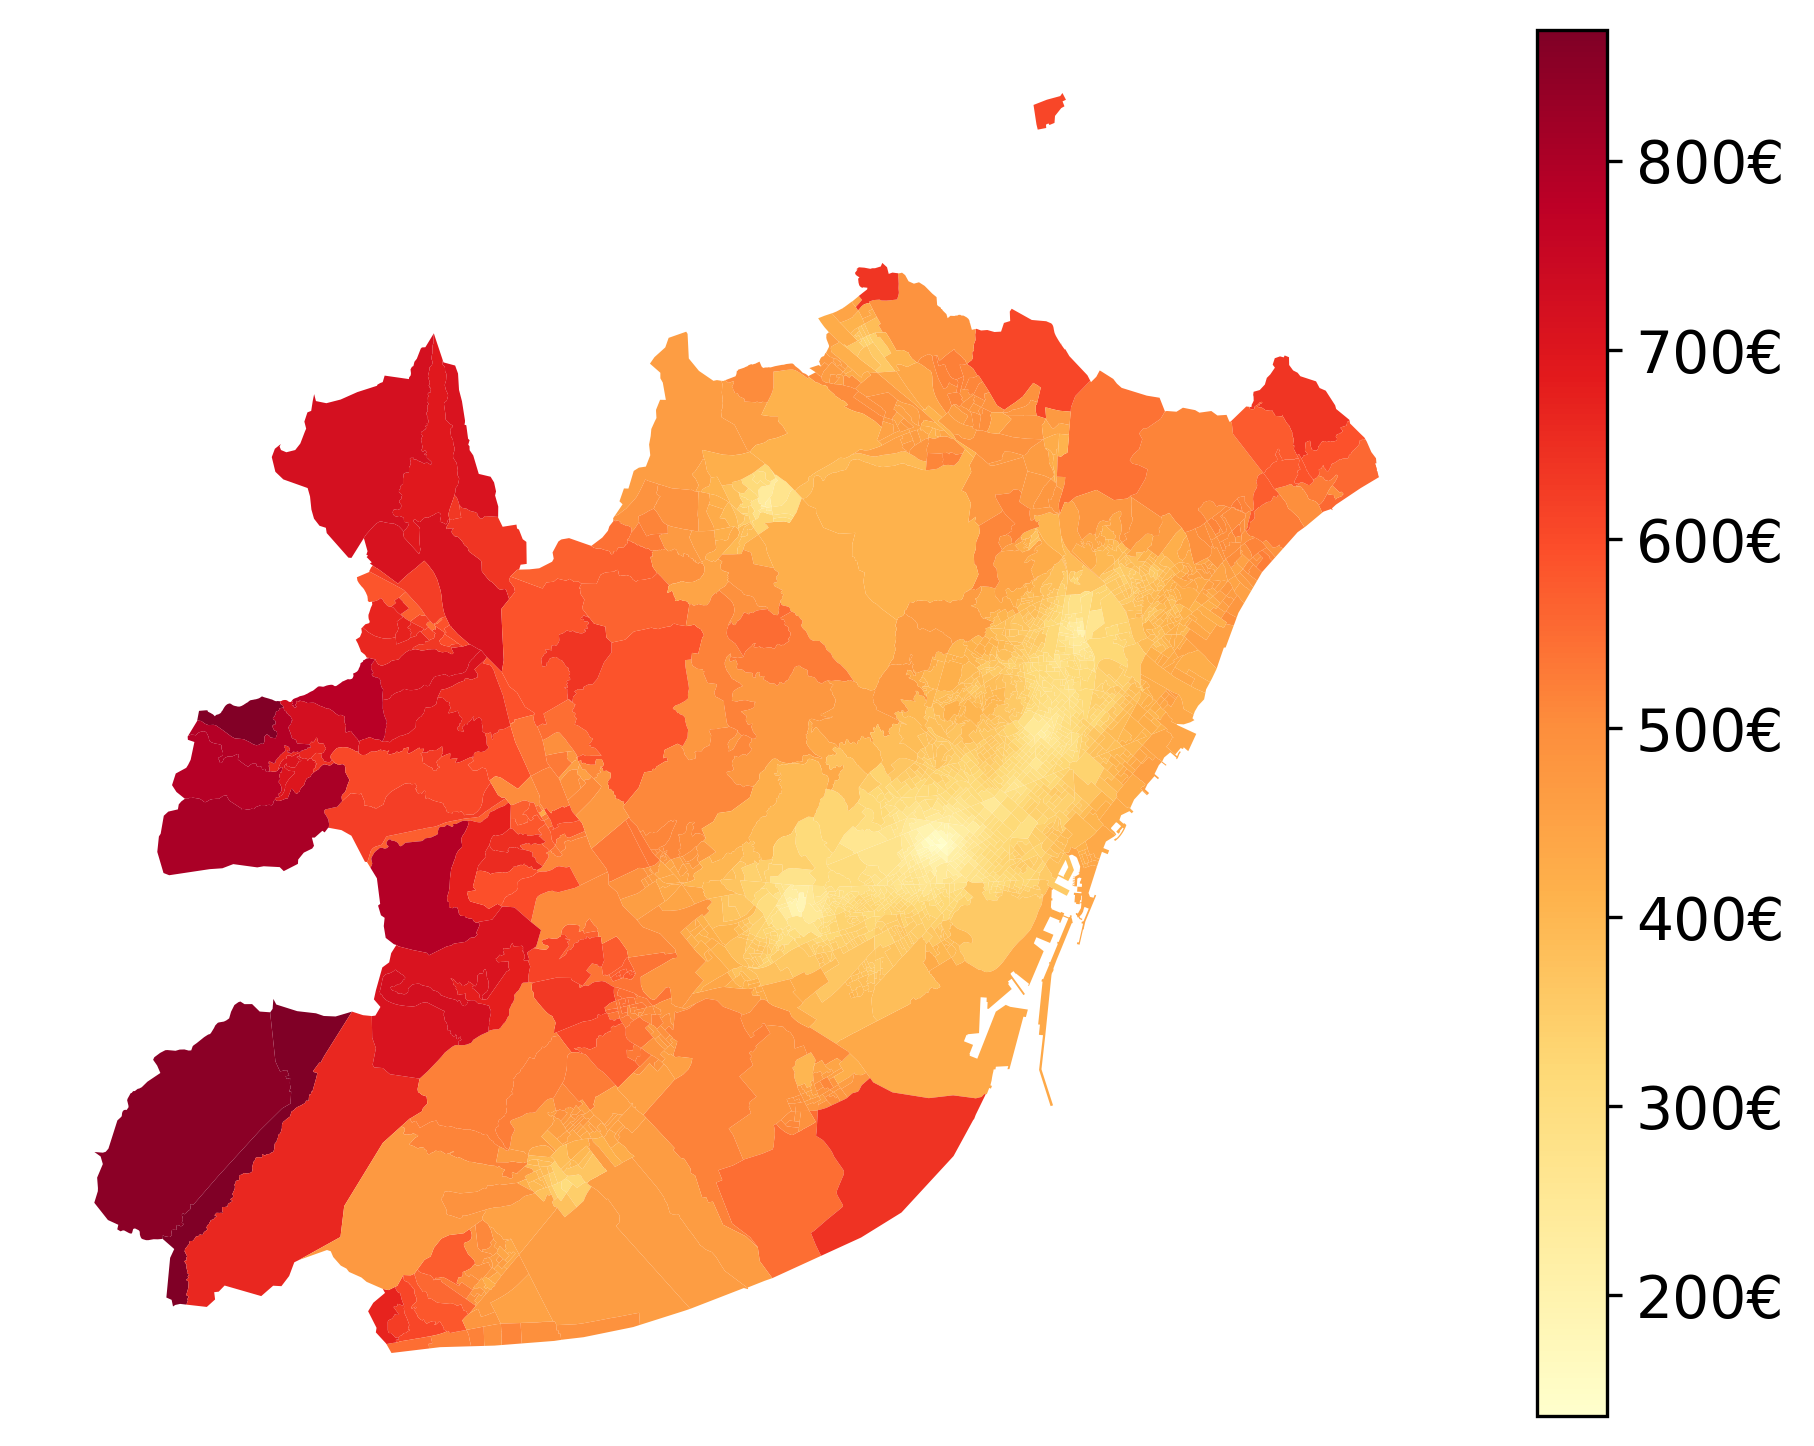

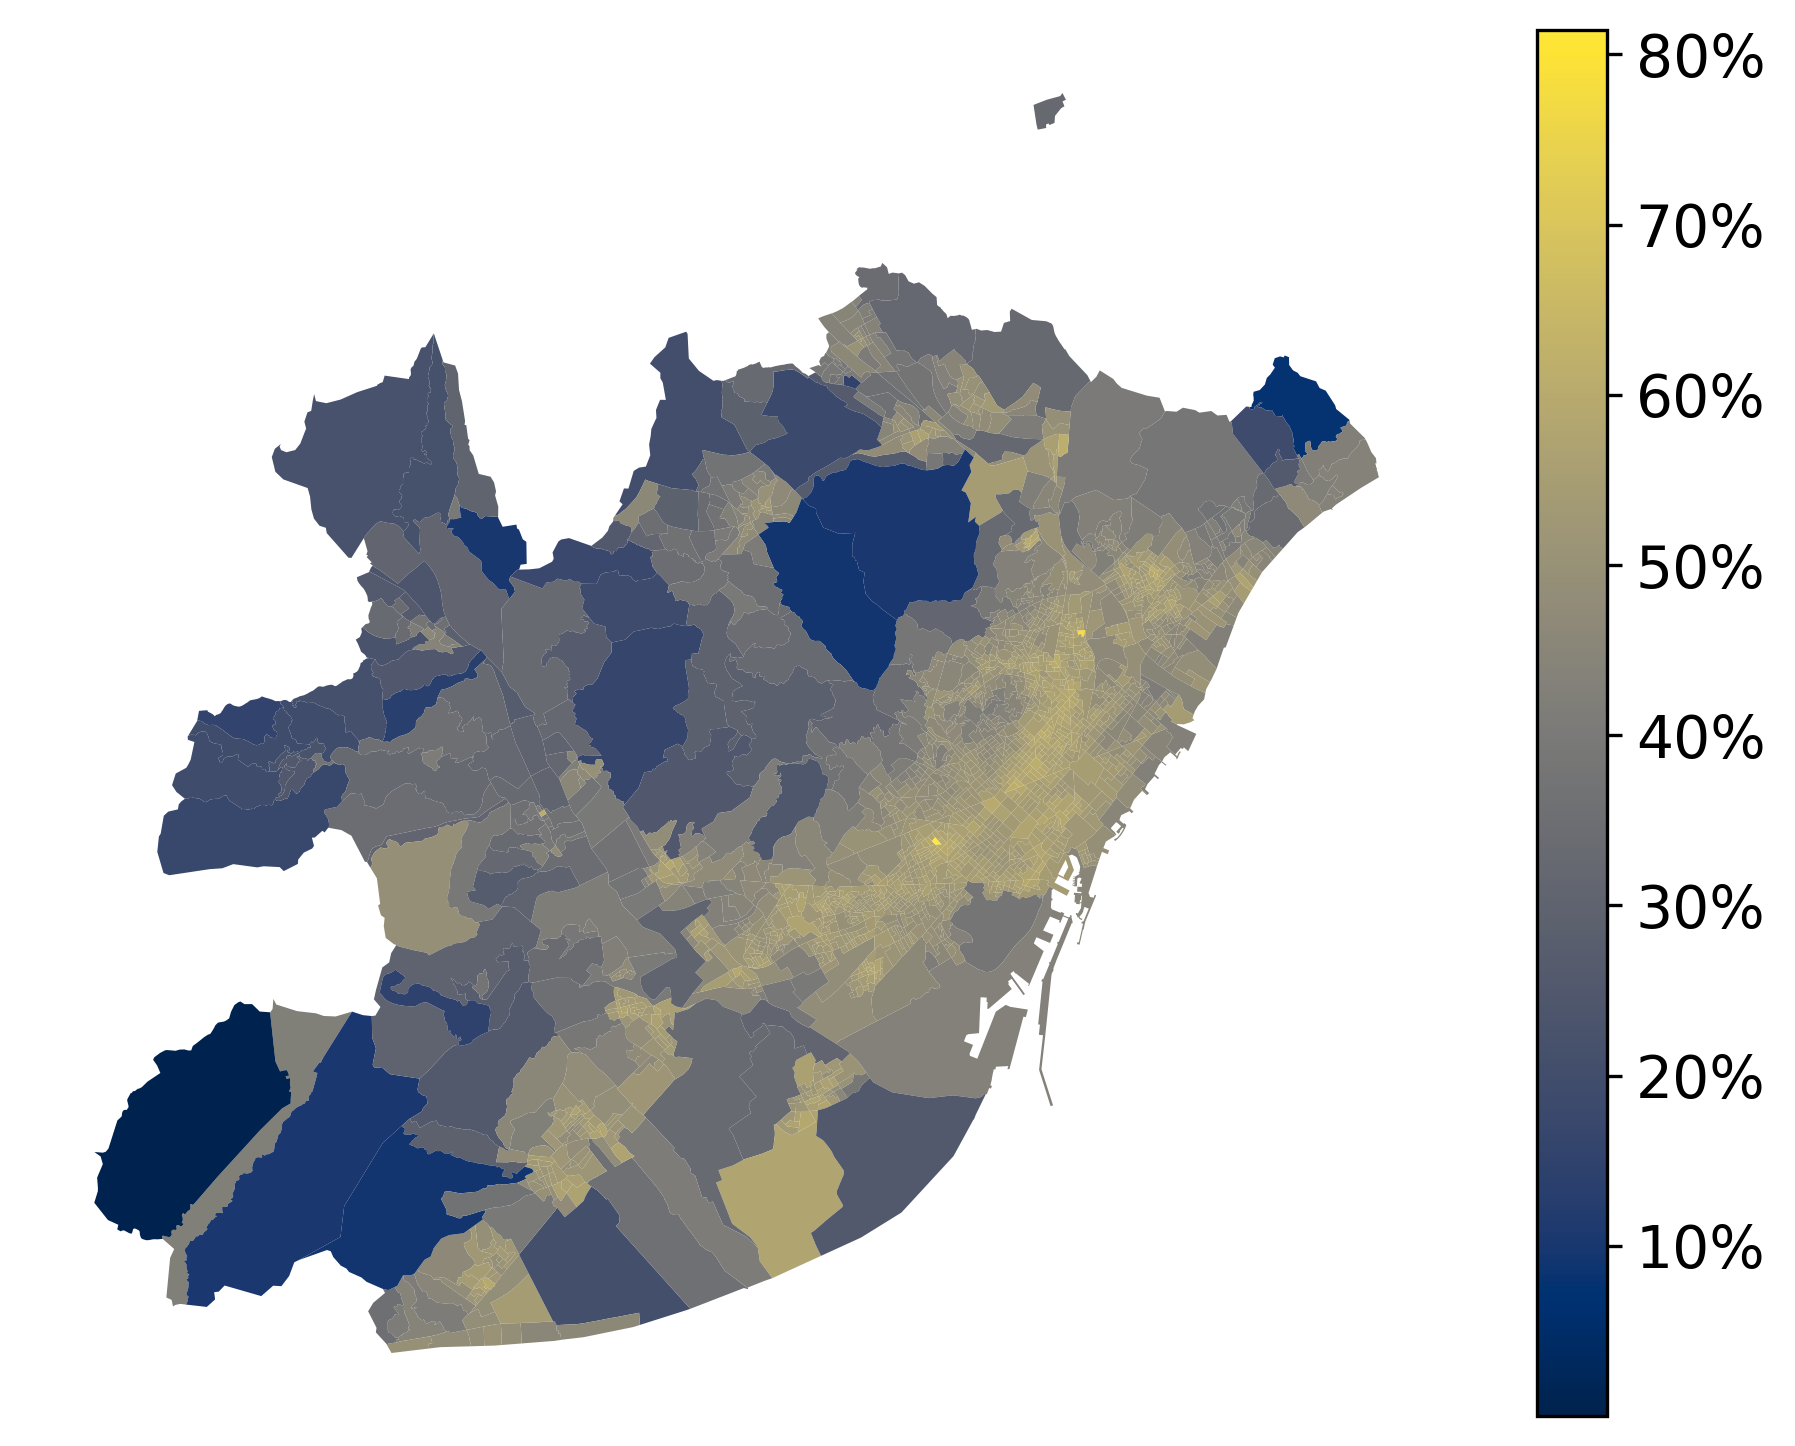

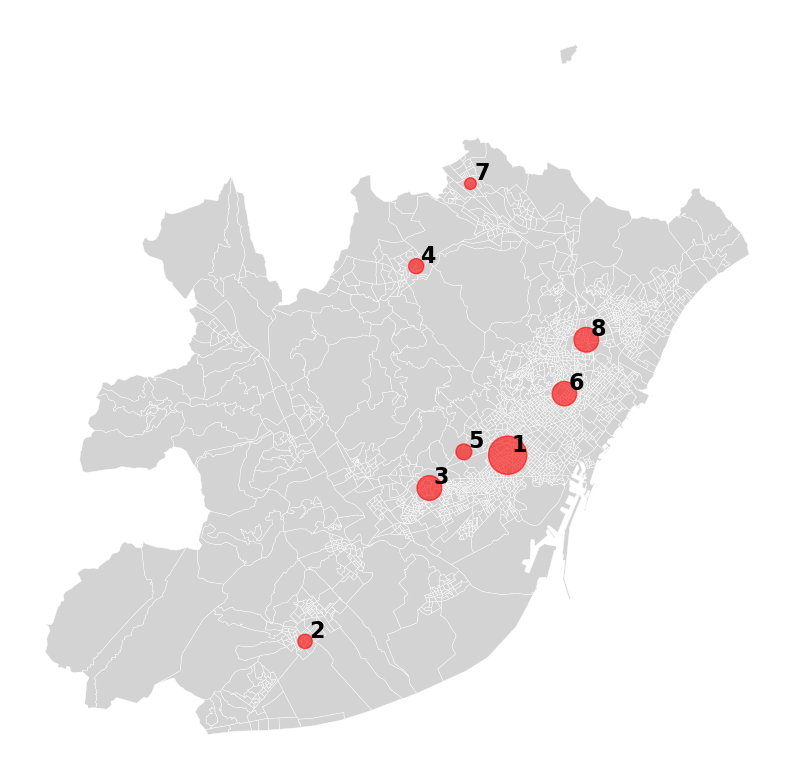

In [ ]:
#Compute transport cost
gdf, workers_per_cluster, travel_matrix = compute_transport_cost_poly_i(gdf, travel_time_matrix_car, travel_time_matrix_transit, PRICE_TIME, WORKING_DAYS, FIXED_COST_CAR, PRICE_FUEL, LAMBDA, ARRAY_WAGE_LOW, ARRAY_WAGE_MED, ARRAY_WAGE_HIGH, jobs_in_toll_area, houses_in_toll_area, 0, income_levels, wage_factors, scenario)
print("Modal share of public transport (%):", round(100 * sum(np.nansum(gdf[f"transport_mode_{lvl}"] * gdf[f"pop_{lvl}"]) for lvl in income_levels) / sum(np.nansum(gdf[f"pop_{lvl}"]) for lvl in income_levels)))
print("Modal share of public transport (%):", round(100 * (np.nansum(gdf["transport_mode_HIGH"] * gdf["pop_HIGH"])) / (np.nansum(gdf["pop_HIGH"]))))
print("Modal share of public transport (%):", round(100 * (np.nansum(gdf[f"transport_mode_MED"] * gdf[f"pop_MED"])) / (np.nansum(gdf[f"pop_MED"]))))
print("Modal share of public transport (%):", round(100 * (np.nansum(gdf[f"transport_mode_LOW"] * gdf[f"pop_LOW"])) / (np.nansum(gdf[f"pop_LOW"]))))
plot_transport_cost_i(gdf, "_HIGH")
plot_transport_mode_i(gdf, "_HIGH")
plot_employment(gdf, employment_centers, employment_centers['employment'] * 0.0015)

In [ ]:
#Calibrate beta and amenities
def compute_log_likelihood(x):
    print(x)
    return calibration_utility_amenity2(x, gdf, income_levels, SOFT_RENT, 0, 0)

calib_beta = scipy.optimize.minimize(compute_log_likelihood, [0.3, 100, 500, 900], bounds=[(0.25,0.5), (0,None), (0,None), (0,None)]) #[0.45, 100, 500, 900] #[0.3, 224, 386, 553]
BETA = calib_beta.x[0]
print("BETA:", BETA)
amenities = calibration_utility_amenity(calib_beta.x, gdf, income_levels, SOFT_RENT, 1, 1)
gdf = gdf.merge(amenities, on = "ID", how = "left")
gdf.loc[np.isnan(gdf["amenities"]), "amenities"] = 1
gdf.loc[np.isnan(gdf["amenities_improved_rodalies"]), "amenities_improved_rodalies"] = 1

[3.e-01 1.e+02 5.e+02 9.e+02]
scoreDwellingSize: -631.1795503653093
scoreAmenities: -3000.6230315513553
log_sorting: -169931.10071632825
[3.0000001e-01 1.0000000e+02 5.0000000e+02 9.0000000e+02]
scoreDwellingSize: -631.1795149806571
scoreAmenities: -3000.6230315513553
log_sorting: -169931.1011663117
[3.e-01 1.e+02 5.e+02 9.e+02]
scoreDwellingSize: -631.1795503209861
scoreAmenities: -3000.623031551355
log_sorting: -169931.100716507
[3.e-01 1.e+02 5.e+02 9.e+02]
scoreDwellingSize: -631.1795503730675
scoreAmenities: -3000.623031551355
log_sorting: -169931.10071709723
[3.e-01 1.e+02 5.e+02 9.e+02]
scoreDwellingSize: -631.1795503659239
scoreAmenities: -3000.6230315513553
log_sorting: -169931.1007158812
[2.99448075e-01 9.98515765e+01 4.99142582e+02 9.00492753e+02]
scoreDwellingSize: -633.1724248568325
scoreAmenities: -3000.6230315513553
log_sorting: -169815.20078831882
[2.99448085e-01 9.98515765e+01 4.99142582e+02 9.00492753e+02]
scoreDwellingSize: -633.17238954196
scoreAmenities: -3000.6230

c:\Users\1738037\AppData\Local\anaconda3\envs\geo_env\Lib\site-packages\numpy\lib\nanfunctions.py:1741: RuntimeWarning: invalid value encountered in subtract
  np.subtract(arr, avg, out=arr, casting='unsafe', where=where)
c:\Users\1738037\OneDrive - UAB\1- CLIMGROW Charlotte\1- PSC cities\code_barcelona\calibration.py:87: RuntimeWarning: Mean of empty slice
  epsilon_size = max(np.nanmean(diff_size[mask]**2), 1e-12)


In [ ]:
# Solve the model
def compute_error_in_population_from_utility(u):
    """ Compute error in population associated to utility u"""

    return compute_error_in_population(u, gdf["amenities"], [pop[lvl] for lvl in income_levels], BETA, gdf["wage_LOW"], gdf["wage_MED"], gdf["wage_HIGH"], gdf["transport_cost_LOW"], gdf["transport_cost_MED"], gdf["transport_cost_HIGH"], B, KAPPA, SIGMA, INTEREST_RATE, gdf["urb_area"], SOFT_RENT, False, option_function)

solving_model = scipy.optimize.minimize(compute_error_in_population_from_utility, [100, 180, 300], bounds=[(0,None), (0,None), (0,None)], method = "Nelder-Mead") #np.array([399,690,995]) np.array([370,690,800]) #[180, 420, 600]

if solving_model.fun < 1:
    R, q, n, w, R_group, q_group = compute_outcomes(solving_model.x, gdf, BETA, B, KAPPA, SIGMA, INTEREST_RATE, SOFT_RENT, income_levels, compute_rents, compute_dwelling_size, compute_population, option_function)
else:
    raise ValueError("Minimization failed!")

share_col = {"LOW": "share_low_income", "MED": None, "HIGH": "share_high_income"}
density_residual = {
    lvl: np.log(
        (gdf["pop"] * (gdf[share_col[lvl]] / 100 if share_col[lvl] else (100 - gdf["share_low_income"] - gdf["share_high_income"]) / 100))
        / (w[lvl] * n)
    )
    for lvl in income_levels
}
rent_residual = np.log(gdf["rent_m2"] / R)
size_residual = np.log(gdf["size"] / q)

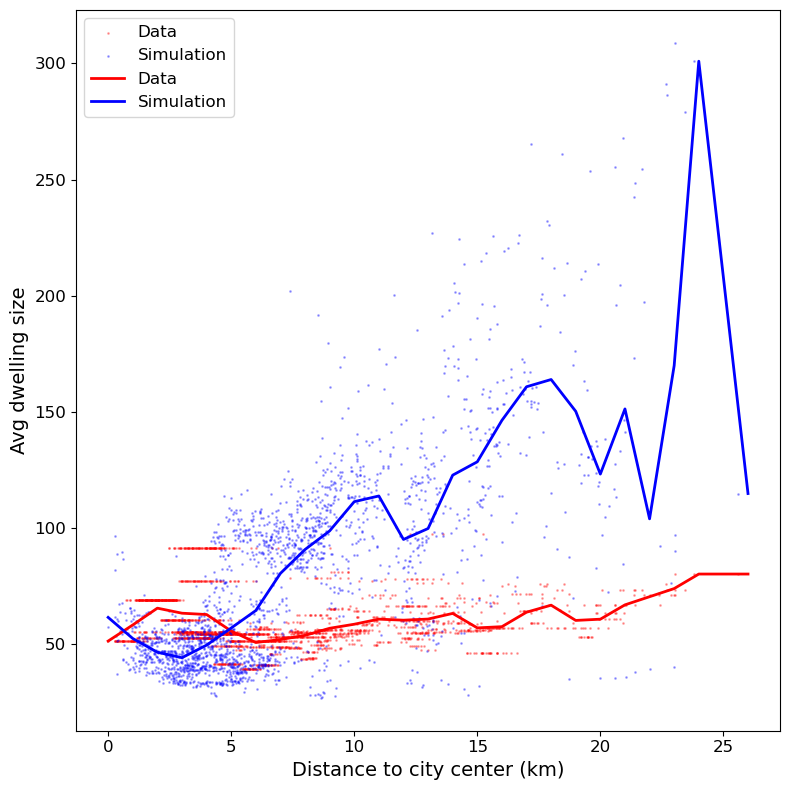

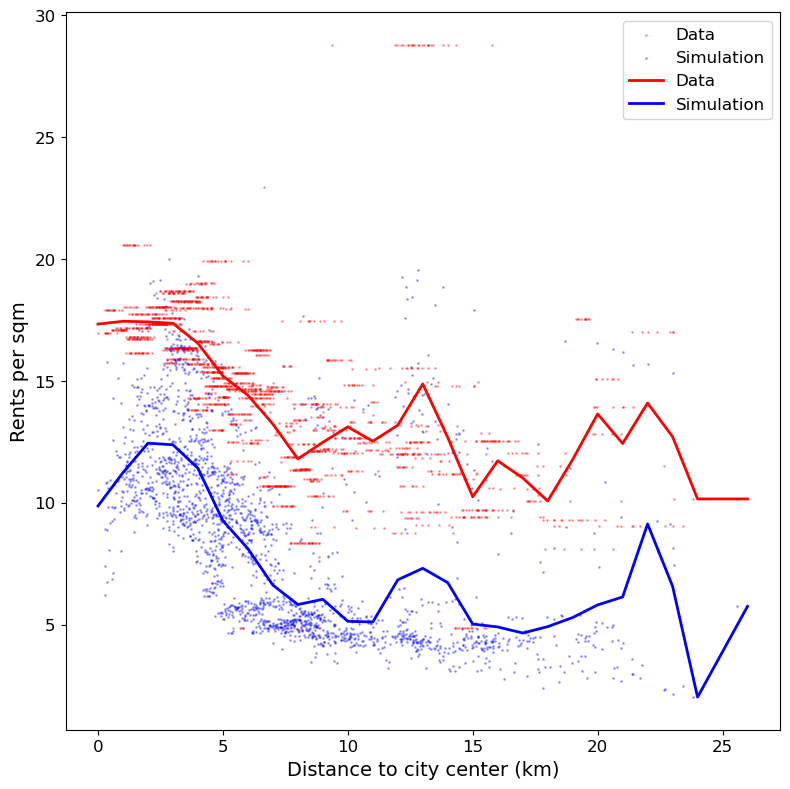

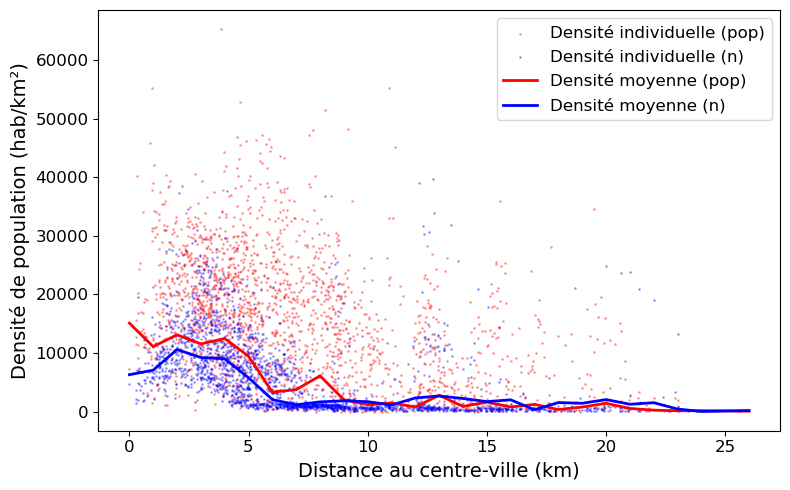

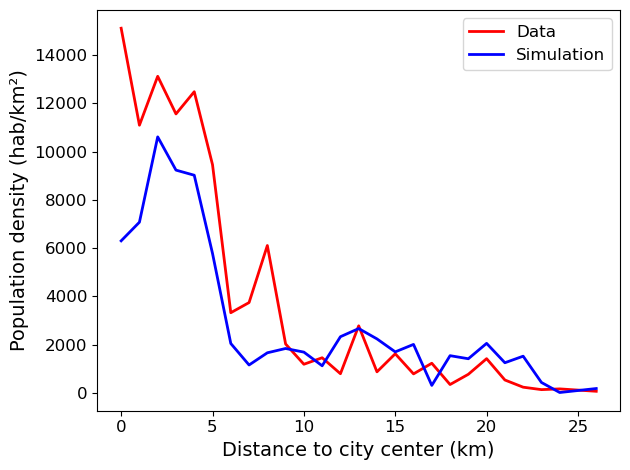

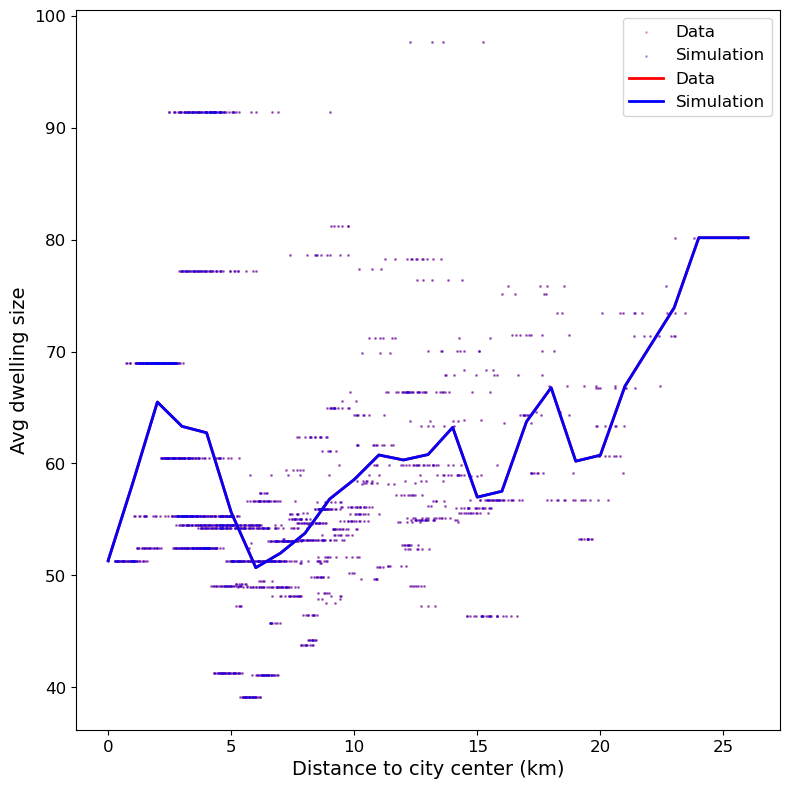

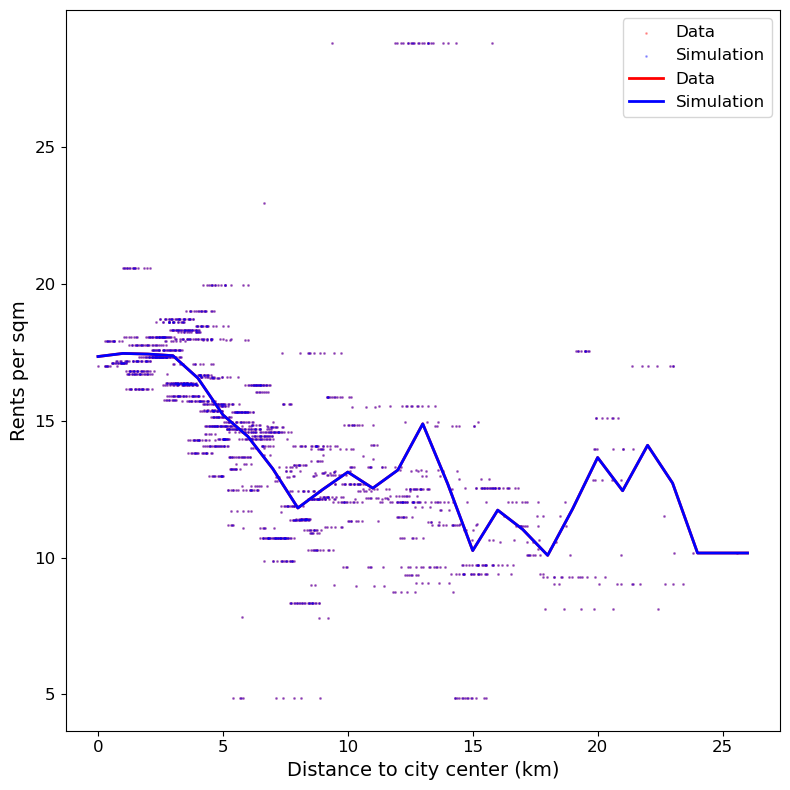

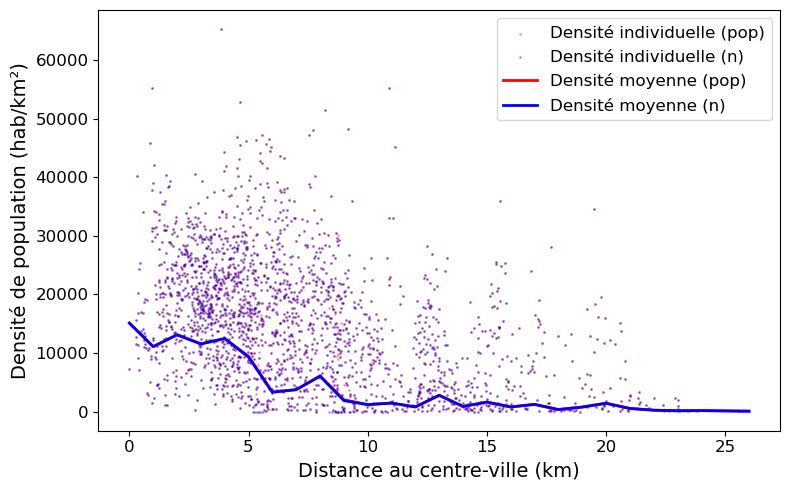

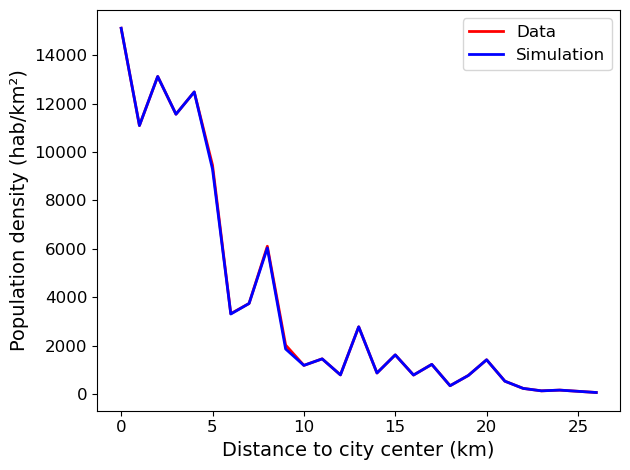

In [ ]:
plot_line_charts(gdf, n, q, R)

#initial state
def compute_error_in_population_from_utility(u):
    """ Compute error in population associated to utility u"""

    return compute_error_in_population(u, gdf["amenities"], [pop[lvl] for lvl in income_levels], BETA, gdf["wage_LOW"], gdf["wage_MED"], gdf["wage_HIGH"], gdf["transport_cost_LOW"], gdf["transport_cost_MED"], gdf["transport_cost_HIGH"], B, KAPPA, SIGMA, INTEREST_RATE, gdf["urb_area"], SOFT_RENT, True, option_function, rent_residual, density_residual, size_residual)

solving_model = scipy.optimize.minimize(compute_error_in_population_from_utility, solving_model.x)

if solving_model.fun < 1:

    R, q, n, w, R_group, q_group = compute_outcomes(solving_model.x, gdf, BETA, B, KAPPA, SIGMA, INTEREST_RATE, SOFT_RENT, income_levels, compute_rents, compute_dwelling_size, compute_population, option_function)

    R = R * np.exp(rent_residual)
    q = q * np.exp(size_residual)
    n_group = {lvl: n * w[lvl] * np.exp(density_residual[lvl]) for lvl in ["LOW", "MED", "HIGH"]}
    n = np.nansum(list(n_group.values()), axis=0)
    n[np.isnan(n)] = 0
    for lvl in income_levels:
        n_group[lvl][np.isnan(n_group[lvl])] = 0

else:
    raise ValueError("Minimization failed!")

plot_line_charts(gdf, n, q, R)

# ABM: translate outputs at the household level
N = {lvl: round(pop[lvl] * SCALE_ABM) for lvl in income_levels}
#support = {lvl: INITIAL_OPINION * np.ones(N[lvl]) for lvl in income_levels}
indiv_loc_matrix = {
    lvl: compute_indiv_loc_matrix2(
        N[lvl], len(gdf), (n_group[lvl] * SCALE_ABM).to_numpy()
    )
    for lvl in income_levels
}

rent_indiv = {lvl: indiv_loc_matrix[lvl] @ R_group[lvl].to_numpy() for lvl in income_levels}
dwelling_size_indiv = {lvl: indiv_loc_matrix[lvl] @ q_group[lvl] for lvl in income_levels}

utility = {}

for lvl in income_levels:
    u = compute_utility_manually(
        indiv_loc_matrix[lvl] @ gdf[f"wage_{lvl}"],
        indiv_loc_matrix[lvl] @ gdf[f"transport_cost_{lvl}"],
        dwelling_size_indiv[lvl],
        rent_indiv[lvl],
        BETA, indiv_loc_matrix[lvl] @ gdf["amenities"]
    )
    u[np.isnan(u)] = 0
    utility[lvl] = u

housing_indiv = {
    lvl: dwelling_size_indiv[lvl] @ csr_matrix(indiv_loc_matrix[lvl])
    for lvl in income_levels
}

# Save outputs
save_housing = {lvl: np.zeros((len(gdf), MAX_YEAR)) for lvl in income_levels}
save_rent = {lvl: np.zeros((N[lvl], MAX_YEAR)) for lvl in income_levels}
save_dwelling_size = {lvl: np.zeros((N[lvl], MAX_YEAR)) for lvl in income_levels}
save_transport_mode = {lvl: np.zeros((N[lvl], MAX_YEAR)) for lvl in income_levels}
save_utility = {lvl: np.zeros((N[lvl], MAX_YEAR)) for lvl in income_levels}

for lvl in income_levels:
    save_housing[lvl][:, 0] = deepcopy(housing_indiv[lvl])
    save_rent[lvl][:, 0] = deepcopy(rent_indiv[lvl])
    save_dwelling_size[lvl][:, 0] = deepcopy(dwelling_size_indiv[lvl])
    save_transport_mode[lvl][:, 0] = deepcopy(indiv_loc_matrix[lvl] @ gdf[f"transport_mode_{lvl}"])
    save_utility[lvl][:, 0] = deepcopy(utility[lvl])

save_population = np.zeros((len(gdf), MAX_YEAR))
save_population[:, 0] = np.sum([np.nansum(indiv_loc_matrix[lvl], 0) for lvl in income_levels], axis=0)
save_population_lvl = {lvl: np.zeros((len(gdf), MAX_YEAR)) for lvl in income_levels}
for lvl in income_levels:
    save_population_lvl[lvl][:, 0] = np.nansum(indiv_loc_matrix[lvl], 0)

save_tax = np.zeros(MAX_YEAR)
save_tax[0] = 0
save_emissions = np.zeros(MAX_YEAR)
save_score_welfare = {lvl: np.zeros((N[lvl], MAX_YEAR)) for lvl in income_levels}
save_score_qol = {lvl: np.zeros((N[lvl], MAX_YEAR)) for lvl in income_levels}
save_score_congestion = {lvl: np.zeros((N[lvl], MAX_YEAR)) for lvl in income_levels}
save_median_support = np.zeros(MAX_YEAR)
qol_in_zone = np.zeros(MAX_YEAR)
qol_out_zone = np.zeros(MAX_YEAR)
vkm_in_zone = np.zeros(MAX_YEAR)
vkm_out_zone = np.zeros(MAX_YEAR)
total_vkm = np.zeros(MAX_YEAR)
total_vkm_lvl = np.empty(MAX_YEAR, dtype=object)
vkm_in_zone_lvl = np.empty(MAX_YEAR, dtype=object)
vkm_out_zone_lvl = np.empty(MAX_YEAR, dtype=object)
mode_shares_lvl = {lvl: np.full(MAX_YEAR, np.nan) for lvl in income_levels}
avg_vkm_lvl = {lvl: np.full(MAX_YEAR, np.nan) for lvl in income_levels}
avg_vkm_in_zone_lvl = {lvl: np.full(MAX_YEAR, np.nan) for lvl in income_levels}
avg_vkm_out_zone_lvl = {lvl: np.full(MAX_YEAR, np.nan) for lvl in income_levels}
live_and_work_in_toll_lvl = {lvl: np.full(MAX_YEAR, np.nan) for lvl in income_levels}
live_out_and_work_in_toll_lvl = {lvl: np.full(MAX_YEAR, np.nan) for lvl in income_levels}
live_in_toll_and_work_out_lvl = {lvl: np.full(MAX_YEAR, np.nan) for lvl in income_levels}
live_out_and_work_out_lvl = {lvl: np.full(MAX_YEAR, np.nan) for lvl in income_levels}
avg_wage_lvl = {lvl: np.full(MAX_YEAR, np.nan) for lvl in income_levels}
avg_tcost_lvl = {lvl: np.full(MAX_YEAR, np.nan) for lvl in income_levels}
avg_rent_lvl = {lvl: np.full(MAX_YEAR, np.nan) for lvl in income_levels}
avg_dsize_lvl = {lvl: np.full(MAX_YEAR, np.nan) for lvl in income_levels}

tax_revenues = np.zeros(MAX_YEAR)

save_emissions[0], total_vkm[0], tax_revenues[0], _, _, total_vkm_lvl[0] = compute_emissions(gdf, travel_matrix, indiv_loc_matrix, income_levels, jobs_in_toll_area, houses_in_toll_area, 0, WORKING_DAYS, 0, SCALE_ABM)
qol_in_zone[0], qol_out_zone[0], vkm_in_zone[0], vkm_out_zone[0], vkm_in_zone_lvl[0], vkm_out_zone_lvl[0] = compute_qol_congestion(gdf, travel_matrix, indiv_loc_matrix, income_levels)

### DECOMPOSITION TRANSPORT

gdf["live_in_toll"] = (gdf.ID.isin(houses_in_toll_area))
for lvl in income_levels:
    s = (travel_matrix.loc[travel_matrix.to_id.isin(jobs_in_toll_area),
                      ["from_id", f"proba_center_{lvl}"]].groupby("from_id")[f"proba_center_{lvl}"].sum())
    gdf = gdf.merge(s, left_on="ID", right_on="from_id", how="left").rename(columns={f"proba_center_{lvl}": f"work_in_toll_{lvl}"}).fillna(0)

for lvl in income_levels:
    #mode share
    mode_shares_lvl[lvl][0] = np.nansum(gdf[f"transport_mode_{lvl}"] * np.nansum(indiv_loc_matrix[lvl], 0)) / np.nansum(np.nansum(indiv_loc_matrix[lvl], 0))
    #distances
    avg_vkm_lvl[lvl][0] = (total_vkm_lvl[0][lvl] / (np.nansum(gdf[f"transport_mode_{lvl}"] * np.nansum(indiv_loc_matrix[lvl], 0))))
    avg_vkm_in_zone_lvl[lvl][0] = vkm_in_zone_lvl[0][lvl] / (np.nansum(gdf[f"transport_mode_{lvl}"] * np.nansum(indiv_loc_matrix[lvl], 0)))
    avg_vkm_out_zone_lvl[lvl][0] = vkm_out_zone_lvl[0][lvl] / (np.nansum(gdf[f"transport_mode_{lvl}"] * np.nansum(indiv_loc_matrix[lvl], 0)))
    #repartition
    gdf[f"live_and_work_in_toll_{lvl}"] = (gdf["live_in_toll"] == True) * gdf[f"work_in_toll_{lvl}"]
    gdf[f"live_out_and_work_in_toll_{lvl}"] = (gdf["live_in_toll"] == False) * gdf[f"work_in_toll_{lvl}"]
    gdf[f"live_in_toll_and_work_out_{lvl}"] = (gdf["live_in_toll"] == True) * (1 - gdf[f"work_in_toll_{lvl}"])
    gdf[f"live_out_and_work_out_toll_{lvl}"] = (gdf["live_in_toll"] == False) * (1 - gdf[f"work_in_toll_{lvl}"])
    live_and_work_in_toll_lvl[lvl][0] = np.nansum(save_population_lvl[lvl][:,0] * gdf[f"live_and_work_in_toll_{lvl}"]) / N[lvl]
    live_out_and_work_in_toll_lvl[lvl][0] = np.nansum(save_population_lvl[lvl][:,0] * gdf[f"live_out_and_work_in_toll_{lvl}"]) / N[lvl]
    live_in_toll_and_work_out_lvl[lvl][0] = np.nansum(save_population_lvl[lvl][:,0] * gdf[f"live_in_toll_and_work_out_{lvl}"]) / N[lvl]
    live_out_and_work_out_lvl[lvl][0] = np.nansum(save_population_lvl[lvl][:,0] * gdf[f"live_out_and_work_out_toll_{lvl}"]) / N[lvl]
    #decompo util
    avg_wage_lvl[lvl][0] = np.nanmean(indiv_loc_matrix[lvl] @ gdf[f"wage_{lvl}"])
    avg_tcost_lvl[lvl][0] = np.nanmean(indiv_loc_matrix[lvl] @ gdf[f"transport_cost_{lvl}"])
    avg_rent_lvl[lvl][0] = np.nanmean(rent_indiv[lvl])
    avg_dsize_lvl[lvl][0] = np.nanmean(dwelling_size_indiv[lvl])
BETA_CONG = DIFF_SPEED_CONGESTION/total_vkm[0]

year = year + 1
#plot_distance_distrib_check(income_levels, travel_matrix, "HIGH")

tax_revenue_here = 137000000
subvention_here = 137000000
efficiency = 0
discount = 12.79346
time_discount = 0

In [ ]:
gdf_init, _, _ = compute_transport_cost_poly_i(gdf, travel_time_matrix_car, travel_time_matrix_transit, PRICE_TIME, WORKING_DAYS, FIXED_COST_CAR, PRICE_FUEL, LAMBDA, ARRAY_WAGE_LOW, ARRAY_WAGE_MED, ARRAY_WAGE_HIGH, jobs_in_toll_area, houses_in_toll_area, 0, income_levels, wage_factors, "baseline", 0, 0)
 
utility_init = {lvl: compute_utility_manually(gdf_init[f"wage_{lvl}"],
                                              gdf_init[f"transport_cost_{lvl}"],
                                              q_group[f"{lvl}"],
                                              R_group[f"{lvl}"],
                                              BETA, gdf["amenities"]
                                              ) for lvl in income_levels}

gdf_tax, _, _ = compute_transport_cost_poly_i(gdf, travel_time_matrix_car, travel_time_matrix_transit, PRICE_TIME, WORKING_DAYS, FIXED_COST_CAR, PRICE_FUEL, LAMBDA, ARRAY_WAGE_LOW, ARRAY_WAGE_MED, ARRAY_WAGE_HIGH, jobs_in_toll_area, houses_in_toll_area, 0.5, income_levels, wage_factors, "baseline", 0, 0)
 
utility_tax = {lvl: compute_utility_manually(gdf_tax[f"wage_{lvl}"],
                                              gdf_tax[f"transport_cost_{lvl}"],
                                              q_group[f"{lvl}"],
                                              R_group[f"{lvl}"],
                                              BETA, gdf["amenities"]
                                              ) for lvl in income_levels}

for lvl in income_levels:
    gdf[f"score_welfare_{lvl.lower()}"] = compute_score(compute_change_in_welfare(utility_init[lvl], utility_tax[lvl]), LOGISTIC_PARAM_WELFARE)

expected_welfare_loss = gdf[["ID", "geometry"] + [f"score_welfare_{lvl.lower()}" for lvl in income_levels]]

### CALIBRATION POLICY SUPPORT

In [ ]:
def weighted_median(values, weights):
    # Sort values and weights by values
    sorted_idx = np.argsort(values)
    values, weights = values[sorted_idx], weights[sorted_idx]

    # Compute cumulative weights
    cum_weights = np.cumsum(weights) / np.sum(weights)

    # Find first value where cum_weight >= 0.5
    return values[cum_weights >= 0.5][0]

SignificanceResult(statistic=0.6035851309092074, pvalue=3.229002034877782e-98)


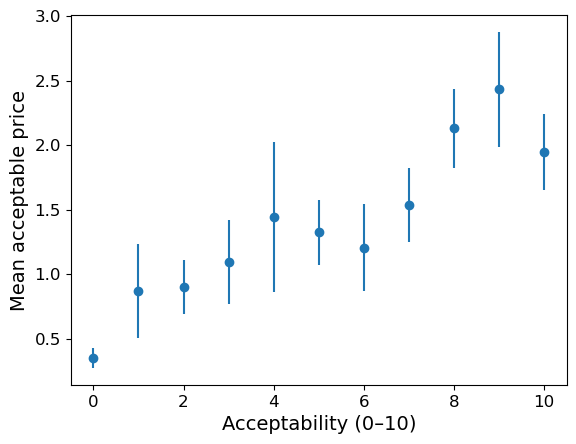

c:\Users\1738037\OneDrive - UAB\1- CLIMGROW Charlotte\1- PSC cities\code_barcelona\plotting_tools.py:288: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  df_reg.groupby('bin').apply(lambda g: pd.Series({
c:\Users\1738037\OneDrive - UAB\1- CLIMGROW Charlotte\1- PSC cities\code_barcelona\plotting_tools.py:288: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  df_reg.groupby('bin').apply(lambda g: pd.Series({


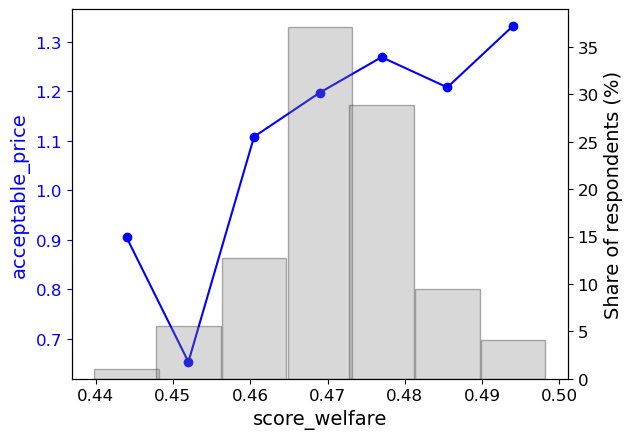

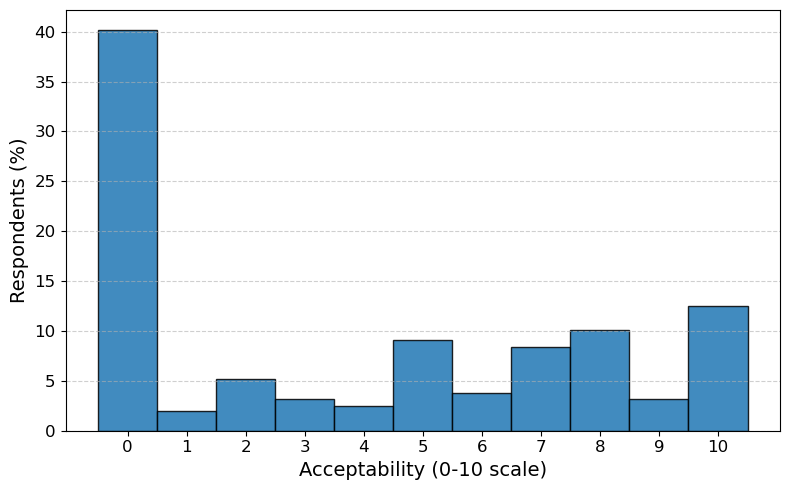

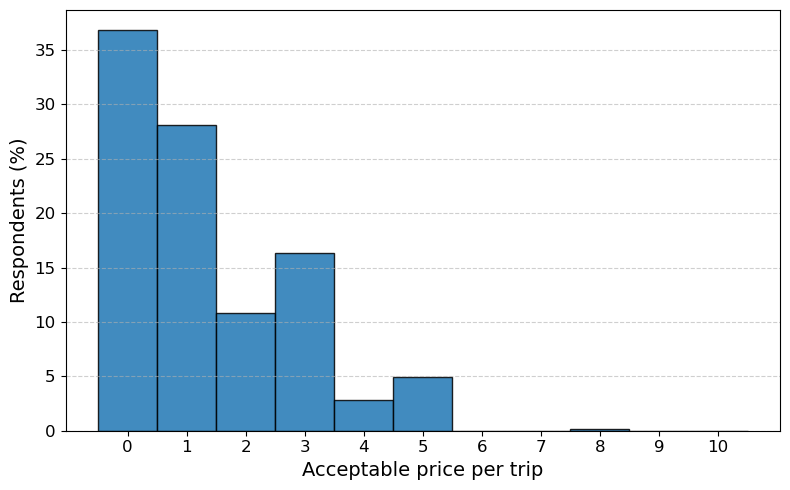

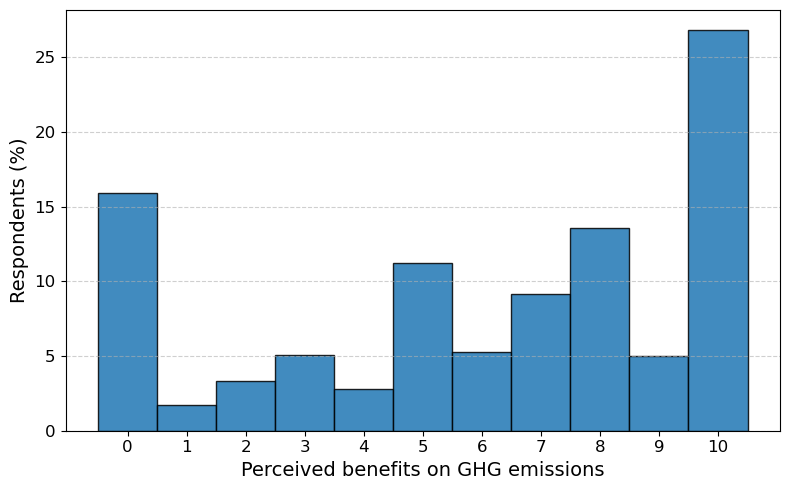

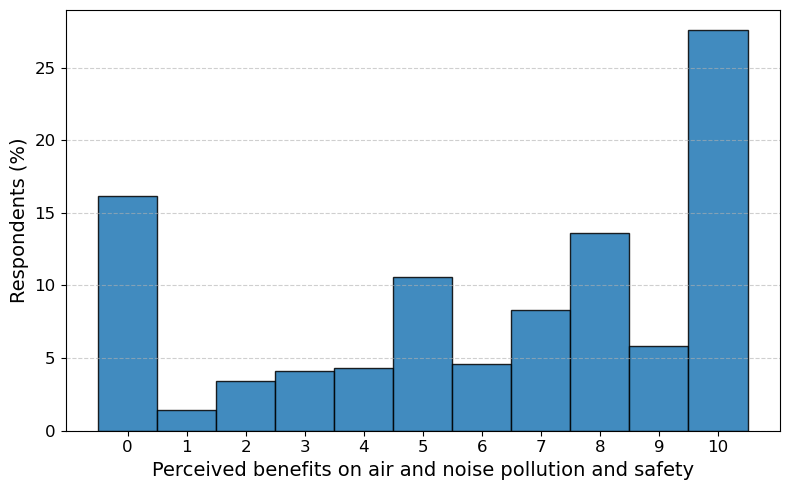

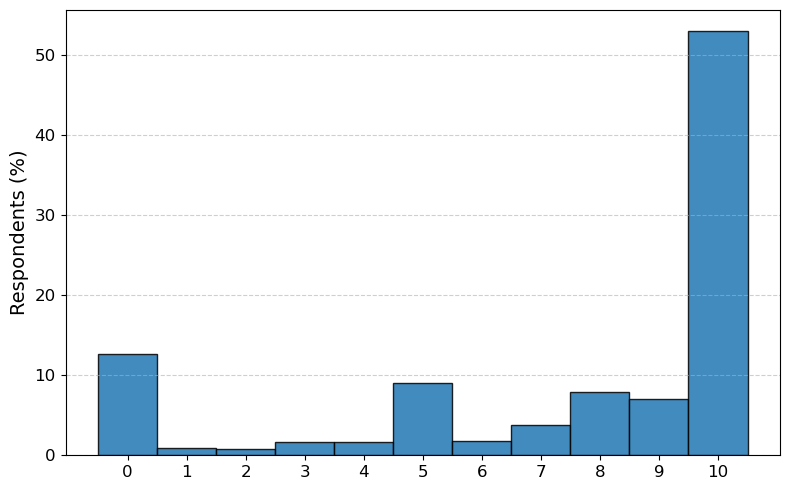

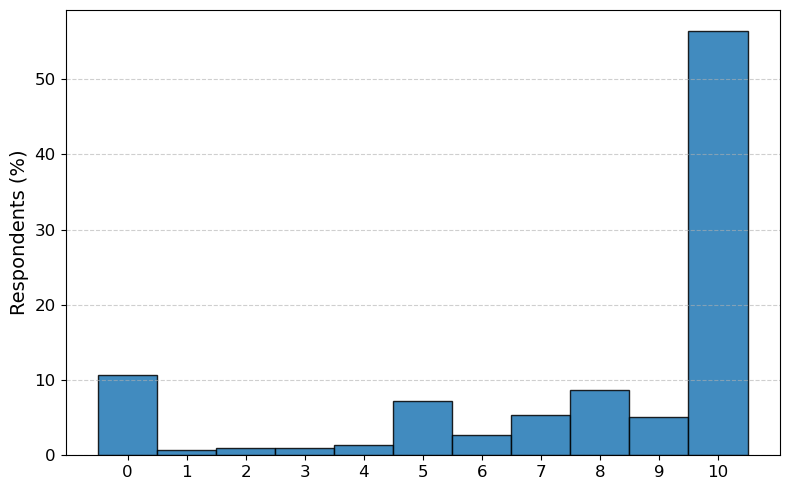

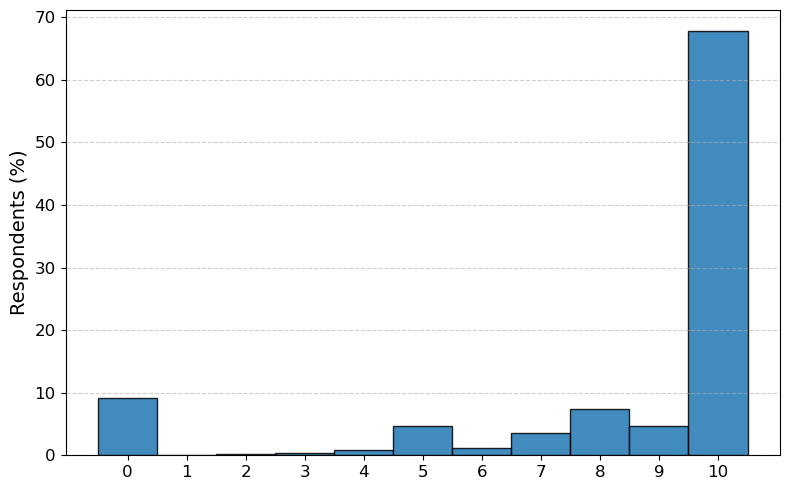

In [ ]:
#import survey
df_reg, meta = pyreadstat.read_sav(path_data + '040023 En moviment pel clima 2025_V01 - còpia.sav')

#add income variable (Joan)
income_var = pd.read_excel(path_data + "MOBCLIMA_amb_renda_codipaisINE.xlsx")
df_reg = df_reg.merge(income_var.loc[:,["NUME", "categoria_quintils", "ingressos_estimats"]], on = "NUME")

#add welfare losses
df_reg = gpd.GeoDataFrame(df_reg, geometry = gpd.points_from_xy(df_reg.GEO_X, df_reg.GEO_Y), crs="EPSG:4326")
df_reg = df_reg.to_crs(expected_welfare_loss.crs)
df_reg = gpd.sjoin(df_reg, expected_welfare_loss, predicate="within")

#prepare variables

#dependent var 1: acceptability
df_reg.rename(columns={'P22_4': 'acceptability'}, inplace=True)
df_reg = df_reg.loc[~np.isnan(df_reg.acceptability) & (df_reg.acceptability < 97)]

#dependent var 2: acceptable price
df_reg.rename(columns={'P18': 'acceptable_price'}, inplace=True)

df_reg = df_reg.loc[~np.isnan(df_reg.acceptable_price) & (df_reg.acceptable_price < 20)]
df_reg.acceptable_price = df_reg.acceptable_price / 2

print(spearmanr(df_reg["acceptability"], df_reg["acceptable_price"], nan_policy="omit"))

# 4. Conditional means with 95% CI
summary = (
    df_reg.groupby("acceptability")["acceptable_price"]
    .agg(["mean", "std", "count"])
)
summary["se"] = summary["std"] / (summary["count"] ** 0.5)

plt.figure()
plt.errorbar(
    summary.index,
    summary["mean"],
    yerr=1.96 * summary["se"],
    fmt="o"
)
plt.xlabel("Acceptability (0–10)")
plt.ylabel("Mean acceptable price")
plt.show()

#explanatory vars

df_reg.rename(columns={'P21_3': 'climate_change'}, inplace=True)
df_reg = df_reg.loc[~np.isnan(df_reg.climate_change) & (df_reg.climate_change < 80)]

df_reg.rename(columns={'P21_2': 'quality_of_life'}, inplace=True)
df_reg = df_reg.loc[~np.isnan(df_reg.quality_of_life) & (df_reg.quality_of_life < 80)]

df_reg["LOW"] = (df_reg.ingressos_estimats  < 11550) * 1
df_reg["HIGH"] = (df_reg.ingressos_estimats > 26950) * 1

df_reg["score_welfare"] = df_reg["score_welfare_low"] * df_reg["LOW"] + df_reg["score_welfare_high"] * df_reg["HIGH"]+ df_reg["score_welfare_med"] * (1 - df_reg["HIGH"] - df_reg["LOW"])
df_reg["vehicle_ownership_license"] = 1 * (((df_reg.P34A > 0) &(df_reg.P33A  == 1))| ((df_reg.P34B > 0) &(df_reg.P33B  == 1)) |((df_reg.P34C > 0) &(df_reg.P33A  == 1))) 
df_reg["score_welfare_vehicle_ownership_license"] = df_reg["score_welfare"]
df_reg.loc[df_reg["vehicle_ownership_license"] == 0, "score_welfare_vehicle_ownership_license"] = 0.5

#Export plots
plot_mobility_loss("score_welfare","acceptable_price", df_reg)
 
def plot_hist_survey(df_reg, var, xlabel):

    plt.figure(figsize=(8, 5))
    bins = np.arange(-0.5, 11.5, 1)  
    plt.hist(
        df_reg[var],
        weights=(df_reg["PESAIX"] / df_reg["PESAIX"].sum()) * 100,
        bins=bins,
        color='#1f77b4',
        alpha=0.85,
        edgecolor='black'  # clearer bar separation
    )

    plt.xlabel(xlabel, fontsize=14)
    plt.ylabel('Respondents (%)', fontsize=14)

    plt.xticks(range(0, 11), fontsize=12)
    plt.yticks(fontsize=12)
    plt.grid(axis='y', linestyle='--', alpha=0.6)

    plt.tight_layout()
    plt.show()

plot_hist_survey(df_reg, 'acceptability', 'Acceptability (0-10 scale)')
plot_hist_survey(df_reg, 'acceptable_price', 'Acceptable price per trip')
plot_hist_survey(df_reg, 'climate_change', 'Perceived benefits on GHG emissions')
plot_hist_survey(df_reg, 'quality_of_life', 'Perceived benefits on air and noise pollution and safety')
plot_hist_survey(df_reg.loc[~np.isnan(df_reg.P20_1) & (df_reg.P20_1 < 97)], 'P20_1', '')
plot_hist_survey(df_reg.loc[~np.isnan(df_reg.P20_4) & (df_reg.P20_4 < 97)], 'P20_4', '')
plot_hist_survey(df_reg.loc[~np.isnan(df_reg.P20_7) & (df_reg.P20_7 < 97)], 'P20_7', '')

In [ ]:
df_reg[["climate_change", "quality_of_life", "acceptability"]] = df_reg[["climate_change", "quality_of_life", "acceptability"]] / 10

X = df_reg[["climate_change", "quality_of_life", "score_welfare", "LOW", "HIGH"]]
X = sm.add_constant(X)
y_acceptability = df_reg["acceptability"].values.reshape(-1, 1).flatten()
y_price = (df_reg["acceptable_price"].values.reshape(-1, 1)).flatten()

model_acceptability = sm.WLS(y_acceptability, X, weights=df_reg['PESAIX']).fit()
print(model_acceptability.summary())

                            WLS Regression Results                            
Dep. Variable:                      y   R-squared:                       0.418
Model:                            WLS   Adj. R-squared:                  0.415
Method:                 Least Squares   F-statistic:                     136.5
Date:                Thu, 12 Feb 2026   Prob (F-statistic):          4.72e-109
Time:                        09:52:50   Log-Likelihood:                -263.60
No. Observations:                 955   AIC:                             539.2
Df Residuals:                     949   BIC:                             568.4
Df Model:                           5                                         
Covariance Type:            nonrobust                                         
                      coef    std err          t      P>|t|      [0.025      0.975]
-----------------------------------------------------------------------------------
const               0.6895      0.515     

In [ ]:
model_price = sm.WLS(y_price, X, weights=df_reg['PESAIX']).fit()
print(model_price.summary())

                            WLS Regression Results                            
Dep. Variable:                      y   R-squared:                       0.211
Model:                            WLS   Adj. R-squared:                  0.207
Method:                 Least Squares   F-statistic:                     50.74
Date:                Thu, 12 Feb 2026   Prob (F-statistic):           1.14e-46
Time:                        09:53:06   Log-Likelihood:                -1631.3
No. Observations:                 955   AIC:                             3275.
Df Residuals:                     949   BIC:                             3304.
Df Model:                           5                                         
Covariance Type:            nonrobust                                         
                      coef    std err          t      P>|t|      [0.025      0.975]
-----------------------------------------------------------------------------------
const              -3.6052      2.157     

In [ ]:
df_reg["vehicle_ownership_license"]

0       1
1       1
2       0
3       1
5       1
       ..
1096    1
1097    1
1098    0
1099    0
1100    0
Name: vehicle_ownership_license, Length: 955, dtype: int32

In [ ]:
X = df_reg[["climate_change", "quality_of_life", "score_welfare", "LOW", "HIGH", "vehicle_ownership_license"]]
X = sm.add_constant(X)
y_acceptability = df_reg["acceptability"].values.reshape(-1, 1).flatten()
y_price = (df_reg["acceptable_price"].values.reshape(-1, 1)).flatten()

model_acceptability = sm.WLS(y_acceptability, X, weights=df_reg['PESAIX']).fit()
print(model_acceptability.summary())

                             WLS Regression Results                            
Dep. Variable:                       y   R-squared:                       0.424
Model:                             WLS   Adj. R-squared:                  0.421
Method:                  Least Squares   F-statistic:                     116.5
Date:              jeu., 12 févr. 2026   Prob (F-statistic):          4.08e-110
Time:                         09:55:38   Log-Likelihood:                -258.58
No. Observations:                  955   AIC:                             531.2
Df Residuals:                      948   BIC:                             565.2
Df Model:                            6                                         
Covariance Type:             nonrobust                                         
                                coef    std err          t      P>|t|      [0.025      0.975]
---------------------------------------------------------------------------------------------
const       

In [ ]:
model_price = sm.WLS(y_price, X, weights=df_reg['PESAIX']).fit()
print(model_price.summary())

                             WLS Regression Results                            
Dep. Variable:                       y   R-squared:                       0.222
Model:                             WLS   Adj. R-squared:                  0.217
Method:                  Least Squares   F-statistic:                     44.96
Date:              jeu., 12 févr. 2026   Prob (F-statistic):           1.58e-48
Time:                         09:55:54   Log-Likelihood:                -1624.9
No. Observations:                  955   AIC:                             3264.
Df Residuals:                      948   BIC:                             3298.
Df Model:                            6                                         
Covariance Type:             nonrobust                                         
                                coef    std err          t      P>|t|      [0.025      0.975]
---------------------------------------------------------------------------------------------
const       

In [ ]:
df_reg.rename(columns={'P02': 'age'}, inplace=True)
df_reg["age"] = 2025 - df_reg["age"]

In [ ]:
df_reg["age"]

0       38.0
1       68.0
2       79.0
3       63.0
5       56.0
        ... 
1096    24.0
1097    20.0
1098    28.0
1099    23.0
1100    19.0
Name: age, Length: 955, dtype: float64

In [ ]:
X = df_reg[["climate_change", "quality_of_life", "score_welfare", "LOW", "HIGH", "vehicle_ownership_license", "age"]]
X = sm.add_constant(X)
y_acceptability = df_reg["acceptability"].values.reshape(-1, 1).flatten()
y_price = (df_reg["acceptable_price"].values.reshape(-1, 1)).flatten()

model_acceptability = sm.WLS(y_acceptability, X, weights=df_reg['PESAIX']).fit()
print(model_acceptability.summary())

                             WLS Regression Results                            
Dep. Variable:                       y   R-squared:                       0.431
Model:                             WLS   Adj. R-squared:                  0.427
Method:                  Least Squares   F-statistic:                     102.4
Date:              jeu., 12 févr. 2026   Prob (F-statistic):          2.17e-111
Time:                         09:58:16   Log-Likelihood:                -253.14
No. Observations:                  955   AIC:                             522.3
Df Residuals:                      947   BIC:                             561.2
Df Model:                            7                                         
Covariance Type:             nonrobust                                         
                                coef    std err          t      P>|t|      [0.025      0.975]
---------------------------------------------------------------------------------------------
const       

In [ ]:
model_price = sm.WLS(y_price, X, weights=df_reg['PESAIX']).fit()
print(model_price.summary())

                             WLS Regression Results                            
Dep. Variable:                       y   R-squared:                       0.228
Model:                             WLS   Adj. R-squared:                  0.222
Method:                  Least Squares   F-statistic:                     39.89
Date:              jeu., 12 févr. 2026   Prob (F-statistic):           2.72e-49
Time:                         09:58:39   Log-Likelihood:                -1621.1
No. Observations:                  955   AIC:                             3258.
Df Residuals:                      947   BIC:                             3297.
Df Model:                            7                                         
Covariance Type:             nonrobust                                         
                                coef    std err          t      P>|t|      [0.025      0.975]
---------------------------------------------------------------------------------------------
const       

In [ ]:
df_reg.rename(columns={'P01': 'man'}, inplace=True)
df_reg["man"] = (df_reg["man"] == 1) * 1

In [ ]:
X = df_reg[["climate_change", "quality_of_life", "score_welfare", "LOW", "HIGH", "vehicle_ownership_license", "age", "man"]]
X = sm.add_constant(X)
y_acceptability = df_reg["acceptability"].values.reshape(-1, 1).flatten()
y_price = (df_reg["acceptable_price"].values.reshape(-1, 1)).flatten()

model_acceptability = sm.WLS(y_acceptability, X, weights=df_reg['PESAIX']).fit()
print(model_acceptability.summary())

                             WLS Regression Results                            
Dep. Variable:                       y   R-squared:                       0.432
Model:                             WLS   Adj. R-squared:                  0.427
Method:                  Least Squares   F-statistic:                     89.85
Date:              jeu., 12 févr. 2026   Prob (F-statistic):          1.14e-110
Time:                         09:59:33   Log-Likelihood:                -252.43
No. Observations:                  955   AIC:                             522.9
Df Residuals:                      946   BIC:                             566.6
Df Model:                            8                                         
Covariance Type:             nonrobust                                         
                                coef    std err          t      P>|t|      [0.025      0.975]
---------------------------------------------------------------------------------------------
const       

In [ ]:
model_price = sm.WLS(y_price, X, weights=df_reg['PESAIX']).fit()
print(model_price.summary())

                             WLS Regression Results                            
Dep. Variable:                       y   R-squared:                       0.229
Model:                             WLS   Adj. R-squared:                  0.223
Method:                  Least Squares   F-statistic:                     35.19
Date:              jeu., 12 févr. 2026   Prob (F-statistic):           6.72e-49
Time:                         09:59:52   Log-Likelihood:                -1620.1
No. Observations:                  955   AIC:                             3258.
Df Residuals:                      946   BIC:                             3302.
Df Model:                            8                                         
Covariance Type:             nonrobust                                         
                                coef    std err          t      P>|t|      [0.025      0.975]
---------------------------------------------------------------------------------------------
const       

In [ ]:
df_reg.rename(columns={'P30': 'education'}, inplace=True)
df_reg = df_reg.loc[~np.isnan(df_reg.education) & (df_reg.education < 6)]

In [ ]:
df_reg.education

0       3.0
1       4.0
2       3.0
3       4.0
5       4.0
       ... 
1096    4.0
1097    4.0
1098    4.0
1099    3.0
1100    3.0
Name: education, Length: 953, dtype: float64

In [ ]:
X = df_reg[["climate_change", "quality_of_life", "score_welfare", "LOW", "HIGH", "vehicle_ownership_license", "age", "man", "education"]]
X = sm.add_constant(X)
y_acceptability = df_reg["acceptability"].values.reshape(-1, 1).flatten()
y_price = (df_reg["acceptable_price"].values.reshape(-1, 1)).flatten()

model_acceptability = sm.WLS(y_acceptability, X, weights=df_reg['PESAIX']).fit()
print(model_acceptability.summary())

                             WLS Regression Results                            
Dep. Variable:                       y   R-squared:                       0.442
Model:                             WLS   Adj. R-squared:                  0.437
Method:                  Least Squares   F-statistic:                     83.09
Date:              jeu., 12 févr. 2026   Prob (F-statistic):          3.12e-113
Time:                         10:01:29   Log-Likelihood:                -242.84
No. Observations:                  953   AIC:                             505.7
Df Residuals:                      943   BIC:                             554.3
Df Model:                            9                                         
Covariance Type:             nonrobust                                         
                                coef    std err          t      P>|t|      [0.025      0.975]
---------------------------------------------------------------------------------------------
const       

In [ ]:
model_price = sm.WLS(y_price, X, weights=df_reg['PESAIX']).fit()
print(model_price.summary())

                             WLS Regression Results                            
Dep. Variable:                       y   R-squared:                       0.231
Model:                             WLS   Adj. R-squared:                  0.223
Method:                  Least Squares   F-statistic:                     31.44
Date:              jeu., 12 févr. 2026   Prob (F-statistic):           2.19e-48
Time:                         10:01:47   Log-Likelihood:                -1616.7
No. Observations:                  953   AIC:                             3253.
Df Residuals:                      943   BIC:                             3302.
Df Model:                            9                                         
Covariance Type:             nonrobust                                         
                                coef    std err          t      P>|t|      [0.025      0.975]
---------------------------------------------------------------------------------------------
const       

In [ ]:
sum(y_price == 0)

338

In [ ]:
sum(y_price > 0)

615

In [ ]:
sum(y_acceptability == 0)

402

In [ ]:
model_price = sm.WLS(y_price == 0, X, weights=df_reg['PESAIX']).fit()
print(model_price.summary())

                             WLS Regression Results                            
Dep. Variable:                       y   R-squared:                       0.267
Model:                             WLS   Adj. R-squared:                  0.260
Method:                  Least Squares   F-statistic:                     38.19
Date:              jeu., 12 févr. 2026   Prob (F-statistic):           4.62e-58
Time:                         10:02:52   Log-Likelihood:                -573.40
No. Observations:                  953   AIC:                             1167.
Df Residuals:                      943   BIC:                             1215.
Df Model:                            9                                         
Covariance Type:             nonrobust                                         
                                coef    std err          t      P>|t|      [0.025      0.975]
---------------------------------------------------------------------------------------------
const       

In [ ]:
model_acceptability = sm.WLS(y_acceptability == 0, X, weights=df_reg['PESAIX']).fit()
print(model_acceptability.summary())

                             WLS Regression Results                            
Dep. Variable:                       y   R-squared:                       0.369
Model:                             WLS   Adj. R-squared:                  0.363
Method:                  Least Squares   F-statistic:                     61.25
Date:              jeu., 12 févr. 2026   Prob (F-statistic):           3.39e-88
Time:                         10:03:23   Log-Likelihood:                -533.99
No. Observations:                  953   AIC:                             1088.
Df Residuals:                      943   BIC:                             1137.
Df Model:                            9                                         
Covariance Type:             nonrobust                                         
                                coef    std err          t      P>|t|      [0.025      0.975]
---------------------------------------------------------------------------------------------
const       

In [ ]:
df_reg["children"] = 1 * ((df_reg.P03B_1 < 18) & (df_reg.P03C_1 == 2)) + 1 * ((df_reg.P03B_2 < 18) & (df_reg.P03C_2 == 2)) + 1 * ((df_reg.P03B_3 < 18) & (df_reg.P03C_3 == 2)) + 1 * ((df_reg.P03B_4 < 18) & (df_reg.P03C_4 == 2)) + 1 * ((df_reg.P03B_5 < 18) & (df_reg.P03C_5 == 2)) + 1 * ((df_reg.P03B_6 < 18) & (df_reg.P03C_6 == 2)) + 1 * ((df_reg.P03B_7 < 18) & (df_reg.P03C_7 == 2)) + 1 * ((df_reg.P03B_8 < 18) & (df_reg.P03C_8 == 2)) + 1 * ((df_reg.P03B_9 < 18) & (df_reg.P03C_9 == 2)) + 1 * ((df_reg.P03B_10 < 18) & (df_reg.P03C_10 == 2))
df_reg["children2"] = 1 * ((df_reg.P03B_1 < 18)) + 1 * ((df_reg.P03B_2 < 18)) + 1 * ((df_reg.P03B_3 < 18)) + 1 * ((df_reg.P03B_4 < 18)) + 1 * ((df_reg.P03B_5 < 18)) + 1 * ((df_reg.P03B_6 < 18)) + 1 * ((df_reg.P03B_7 < 18)) + 1 * ((df_reg.P03B_8 < 18)) + 1 * ((df_reg.P03B_9 < 18)) + 1 * ((df_reg.P03B_10 < 18))

(array([735., 114.,  84.,  14.,   4.,   1.,   1.]),
 array([-0.5,  0.5,  1.5,  2.5,  3.5,  4.5,  5.5,  6.5]),
 <BarContainer object of 7 artists>)

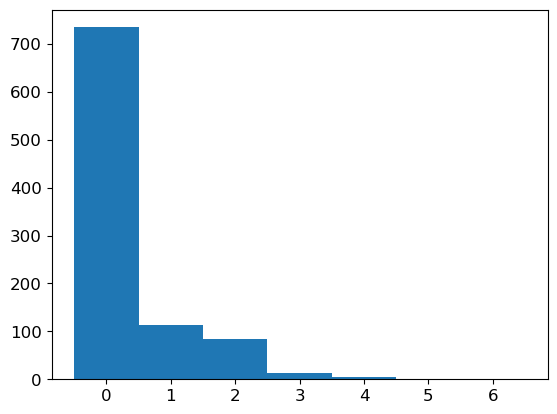

In [ ]:
plt.hist(df_reg["children"], bins = np.arange(df_reg["children"].min(), df_reg["children"].max() + 2) - 0.5)

(array([699., 138.,  93.,  16.,   4.,   2.,   1.]),
 array([-0.5,  0.5,  1.5,  2.5,  3.5,  4.5,  5.5,  6.5]),
 <BarContainer object of 7 artists>)

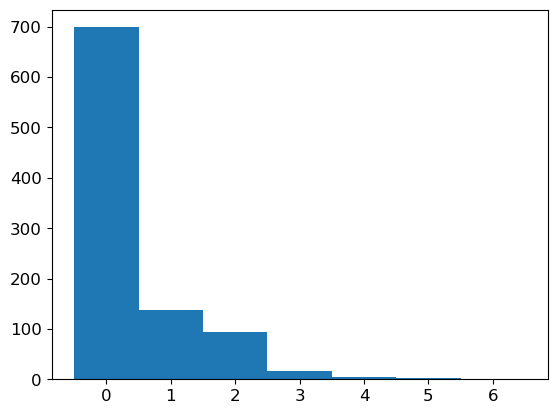

In [ ]:
plt.hist(df_reg["children2"], bins = np.arange(df_reg["children2"].min(), df_reg["children2"].max() + 2) - 0.5)

In [ ]:
X = df_reg[["climate_change", "quality_of_life", "score_welfare", "LOW", "HIGH", "vehicle_ownership_license", "age", "man", "education", "children2"]]
X = sm.add_constant(X)
y_acceptability = df_reg["acceptability"].values.reshape(-1, 1).flatten()
y_price = (df_reg["acceptable_price"].values.reshape(-1, 1)).flatten()

model_acceptability = sm.WLS(y_acceptability, X, weights=df_reg['PESAIX']).fit()
print(model_acceptability.summary())

                             WLS Regression Results                            
Dep. Variable:                       y   R-squared:                       0.444
Model:                             WLS   Adj. R-squared:                  0.438
Method:                  Least Squares   F-statistic:                     75.18
Date:              jeu., 12 févr. 2026   Prob (F-statistic):          7.82e-113
Time:                         10:05:33   Log-Likelihood:                -241.48
No. Observations:                  953   AIC:                             505.0
Df Residuals:                      942   BIC:                             558.4
Df Model:                           10                                         
Covariance Type:             nonrobust                                         
                                coef    std err          t      P>|t|      [0.025      0.975]
---------------------------------------------------------------------------------------------
const       

In [ ]:
model_price = sm.WLS(y_price, X, weights=df_reg['PESAIX']).fit()
print(model_price.summary())

                             WLS Regression Results                            
Dep. Variable:                       y   R-squared:                       0.231
Model:                             WLS   Adj. R-squared:                  0.223
Method:                  Least Squares   F-statistic:                     28.33
Date:              jeu., 12 févr. 2026   Prob (F-statistic):           1.02e-47
Time:                         10:05:56   Log-Likelihood:                -1616.4
No. Observations:                  953   AIC:                             3255.
Df Residuals:                      942   BIC:                             3308.
Df Model:                           10                                         
Covariance Type:             nonrobust                                         
                                coef    std err          t      P>|t|      [0.025      0.975]
---------------------------------------------------------------------------------------------
const       

In [ ]:
X = df_reg[["climate_change", "quality_of_life", "score_welfare", "LOW", "HIGH", "vehicle_ownership_license", "age", "man", "education", "children3"]]
X = sm.add_constant(X)
y_acceptability = df_reg["acceptability"].values.reshape(-1, 1).flatten()
y_price = (df_reg["acceptable_price"].values.reshape(-1, 1)).flatten()

model_acceptability = sm.WLS(y_acceptability, X, weights=df_reg['PESAIX']).fit()
print(model_acceptability.summary())

KeyError: "['children3'] not in index"

In [ ]:
df_reg["children3"] = df_reg["children2"] > 0


X = df_reg[["climate_change", "quality_of_life", "score_welfare", "LOW", "HIGH", "vehicle_ownership_license", "age", "man", "education", "children3"]]
X = sm.add_constant(X)
y_acceptability = df_reg["acceptability"].values.reshape(-1, 1).flatten()
y_price = (df_reg["acceptable_price"].values.reshape(-1, 1)).flatten()

In [ ]:
model_acceptability = sm.WLS(y_acceptability, X, weights=df_reg['PESAIX']).fit()
print(model_acceptability.summary())

ValueError: Pandas data cast to numpy dtype of object. Check input data with np.asarray(data).

In [ ]:
df_reg["children3"] = (df_reg["children2"] > 0) * 1


X = df_reg[["climate_change", "quality_of_life", "score_welfare", "LOW", "HIGH", "vehicle_ownership_license", "age", "man", "education", "children3"]]
X = sm.add_constant(X)
y_acceptability = df_reg["acceptability"].values.reshape(-1, 1).flatten()
y_price = (df_reg["acceptable_price"].values.reshape(-1, 1)).flatten()

model_acceptability = sm.WLS(y_acceptability, X, weights=df_reg['PESAIX']).fit()
print(model_acceptability.summary())

                             WLS Regression Results                            
Dep. Variable:                       y   R-squared:                       0.445
Model:                             WLS   Adj. R-squared:                  0.439
Method:                  Least Squares   F-statistic:                     75.54
Date:              jeu., 12 févr. 2026   Prob (F-statistic):          2.97e-113
Time:                         10:06:48   Log-Likelihood:                -240.50
No. Observations:                  953   AIC:                             503.0
Df Residuals:                      942   BIC:                             556.4
Df Model:                           10                                         
Covariance Type:             nonrobust                                         
                                coef    std err          t      P>|t|      [0.025      0.975]
---------------------------------------------------------------------------------------------
const       

In [ ]:
model_price = sm.WLS(y_price, X, weights=df_reg['PESAIX']).fit()
print(model_price.summary())

                             WLS Regression Results                            
Dep. Variable:                       y   R-squared:                       0.231
Model:                             WLS   Adj. R-squared:                  0.223
Method:                  Least Squares   F-statistic:                     28.28
Date:              jeu., 12 févr. 2026   Prob (F-statistic):           1.23e-47
Time:                         10:07:04   Log-Likelihood:                -1616.6
No. Observations:                  953   AIC:                             3255.
Df Residuals:                      942   BIC:                             3309.
Df Model:                           10                                         
Covariance Type:             nonrobust                                         
                                coef    std err          t      P>|t|      [0.025      0.975]
---------------------------------------------------------------------------------------------
const       

In [ ]:
df_reg.rename(columns={'P35': 'political_ideology'}, inplace=True)
df_reg = df_reg.loc[~np.isnan(df_reg.political_ideology) & (df_reg.political_ideology < 80)]

In [ ]:
X = df_reg[["climate_change", "quality_of_life", "score_welfare", "LOW", "HIGH", "vehicle_ownership_license", "age", "man", "education", "children3", 'political_ideology']]
X = sm.add_constant(X)
y_acceptability = df_reg["acceptability"].values.reshape(-1, 1).flatten()
y_price = (df_reg["acceptable_price"].values.reshape(-1, 1)).flatten()

model_acceptability = sm.WLS(y_acceptability, X, weights=df_reg['PESAIX']).fit()
print(model_acceptability.summary())

                             WLS Regression Results                            
Dep. Variable:                       y   R-squared:                       0.442
Model:                             WLS   Adj. R-squared:                  0.435
Method:                  Least Squares   F-statistic:                     61.37
Date:              jeu., 12 févr. 2026   Prob (F-statistic):          3.56e-100
Time:                         10:08:48   Log-Likelihood:                -215.56
No. Observations:                  865   AIC:                             455.1
Df Residuals:                      853   BIC:                             512.3
Df Model:                           11                                         
Covariance Type:             nonrobust                                         
                                coef    std err          t      P>|t|      [0.025      0.975]
---------------------------------------------------------------------------------------------
const       

In [ ]:
model_price = sm.WLS(y_price, X, weights=df_reg['PESAIX']).fit()
print(model_price.summary())

                             WLS Regression Results                            
Dep. Variable:                       y   R-squared:                       0.251
Model:                             WLS   Adj. R-squared:                  0.241
Method:                  Least Squares   F-statistic:                     26.00
Date:              jeu., 12 févr. 2026   Prob (F-statistic):           7.66e-47
Time:                         10:10:01   Log-Likelihood:                -1446.5
No. Observations:                  865   AIC:                             2917.
Df Residuals:                      853   BIC:                             2974.
Df Model:                           11                                         
Covariance Type:             nonrobust                                         
                                coef    std err          t      P>|t|      [0.025      0.975]
---------------------------------------------------------------------------------------------
const       

In [ ]:
df_reg.rename(columns={'P23': 'institutional_trust'}, inplace=True)
df_reg = df_reg.loc[~np.isnan(df_reg.institutional_trust) & (df_reg.institutional_trust < 80)]

<ipython-input-45-2f77b460c01c>:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_reg.rename(columns={'P23': 'institutional_trust'}, inplace=True)


In [ ]:
X = df_reg[["climate_change", "quality_of_life", "score_welfare", "LOW", "HIGH", "vehicle_ownership_license", "age", "man", "education", "children3", 'political_ideology', 'institutional_trust']]
X = sm.add_constant(X)
y_acceptability = df_reg["acceptability"].values.reshape(-1, 1).flatten()
y_price = (df_reg["acceptable_price"].values.reshape(-1, 1)).flatten()

model_acceptability = sm.WLS(y_acceptability, X, weights=df_reg['PESAIX']).fit()
print(model_acceptability.summary())

                             WLS Regression Results                            
Dep. Variable:                       y   R-squared:                       0.516
Model:                             WLS   Adj. R-squared:                  0.509
Method:                  Least Squares   F-statistic:                     75.42
Date:              jeu., 12 févr. 2026   Prob (F-statistic):          7.39e-125
Time:                         10:10:47   Log-Likelihood:                -153.95
No. Observations:                  862   AIC:                             333.9
Df Residuals:                      849   BIC:                             395.8
Df Model:                           12                                         
Covariance Type:             nonrobust                                         
                                coef    std err          t      P>|t|      [0.025      0.975]
---------------------------------------------------------------------------------------------
const       

In [ ]:
model_price = sm.WLS(y_price, X, weights=df_reg['PESAIX']).fit()
print(model_price.summary())

                             WLS Regression Results                            
Dep. Variable:                       y   R-squared:                       0.285
Model:                             WLS   Adj. R-squared:                  0.275
Method:                  Least Squares   F-statistic:                     28.22
Date:              jeu., 12 févr. 2026   Prob (F-statistic):           3.06e-54
Time:                         10:11:17   Log-Likelihood:                -1422.2
No. Observations:                  862   AIC:                             2870.
Df Residuals:                      849   BIC:                             2932.
Df Model:                           12                                         
Covariance Type:             nonrobust                                         
                                coef    std err          t      P>|t|      [0.025      0.975]
---------------------------------------------------------------------------------------------
const       

In [ ]:
df_reg.rename(columns={'P27_1': 'ecoanxiety'}, inplace=True)
df_reg = df_reg.loc[~np.isnan(df_reg.ecoanxiety) & (df_reg.ecoanxiety < 80)]

In [ ]:
df_reg.rename(columns={'P27_1': 'ecoanxiety'}, inplace=True)
df_reg = df_reg.loc[~np.isnan(df_reg.ecoanxiety) & (df_reg.ecoanxiety < 80)]


X = df_reg[["climate_change", "quality_of_life", "score_welfare", "LOW", "HIGH", "vehicle_ownership_license", "age", "man", "education", "children3", 'political_ideology', 'ecoanxiety']]
X = sm.add_constant(X)
y_acceptability = df_reg["acceptability"].values.reshape(-1, 1).flatten()
y_price = (df_reg["acceptable_price"].values.reshape(-1, 1)).flatten()

model_acceptability = sm.WLS(y_acceptability, X, weights=df_reg['PESAIX']).fit()
print(model_acceptability.summary())

                             WLS Regression Results                            
Dep. Variable:                       y   R-squared:                       0.456
Model:                             WLS   Adj. R-squared:                  0.448
Method:                  Least Squares   F-statistic:                     59.15
Date:              jeu., 12 févr. 2026   Prob (F-statistic):          2.44e-103
Time:                         10:12:29   Log-Likelihood:                -205.44
No. Observations:                  861   AIC:                             436.9
Df Residuals:                      848   BIC:                             498.7
Df Model:                           12                                         
Covariance Type:             nonrobust                                         
                                coef    std err          t      P>|t|      [0.025      0.975]
---------------------------------------------------------------------------------------------
const       

In [ ]:
model_price = sm.WLS(y_price, X, weights=df_reg['PESAIX']).fit()
print(model_price.summary())

                             WLS Regression Results                            
Dep. Variable:                       y   R-squared:                       0.259
Model:                             WLS   Adj. R-squared:                  0.248
Method:                  Least Squares   F-statistic:                     24.66
Date:              jeu., 12 févr. 2026   Prob (F-statistic):           1.06e-47
Time:                         10:12:49   Log-Likelihood:                -1435.7
No. Observations:                  861   AIC:                             2897.
Df Residuals:                      848   BIC:                             2959.
Df Model:                           12                                         
Covariance Type:             nonrobust                                         
                                coef    std err          t      P>|t|      [0.025      0.975]
---------------------------------------------------------------------------------------------
const       

In [ ]:
df_reg.rename(columns={'P26_5': 'ecological_paradigm'}, inplace=True)
df_reg = df_reg.loc[~np.isnan(df_reg.ecological_paradigm) & (df_reg.ecological_paradigm < 80)]


X = df_reg[["climate_change", "quality_of_life", "score_welfare", "LOW", "HIGH", "vehicle_ownership_license", "age", "man", "education", "children3", 'political_ideology', 'ecoanxiety', 'ecological_paradigm']]
X = sm.add_constant(X)
y_acceptability = df_reg["acceptability"].values.reshape(-1, 1).flatten()
y_price = (df_reg["acceptable_price"].values.reshape(-1, 1)).flatten()

model_acceptability = sm.WLS(y_acceptability, X, weights=df_reg['PESAIX']).fit()
print(model_acceptability.summary())

                             WLS Regression Results                            
Dep. Variable:                       y   R-squared:                       0.456
Model:                             WLS   Adj. R-squared:                  0.448
Method:                  Least Squares   F-statistic:                     54.31
Date:              jeu., 12 févr. 2026   Prob (F-statistic):          6.15e-102
Time:                         10:14:02   Log-Likelihood:                -204.65
No. Observations:                  856   AIC:                             437.3
Df Residuals:                      842   BIC:                             503.8
Df Model:                           13                                         
Covariance Type:             nonrobust                                         
                                coef    std err          t      P>|t|      [0.025      0.975]
---------------------------------------------------------------------------------------------
const       

In [ ]:
model_price = sm.WLS(y_price, X, weights=df_reg['PESAIX']).fit()
print(model_price.summary())

                             WLS Regression Results                            
Dep. Variable:                       y   R-squared:                       0.260
Model:                             WLS   Adj. R-squared:                  0.249
Method:                  Least Squares   F-statistic:                     22.80
Date:              jeu., 12 févr. 2026   Prob (F-statistic):           4.55e-47
Time:                         10:14:16   Log-Likelihood:                -1427.8
No. Observations:                  856   AIC:                             2884.
Df Residuals:                      842   BIC:                             2950.
Df Model:                           13                                         
Covariance Type:             nonrobust                                         
                                coef    std err          t      P>|t|      [0.025      0.975]
---------------------------------------------------------------------------------------------
const       

In [ ]:
df_reg.rename(columns={'P24': 'knowledge'}, inplace=True)
df_reg = df_reg.loc[~np.isnan(df_reg.knowledge) & (df_reg.knowledge < 80)]

In [ ]:
X = df_reg[["climate_change", "quality_of_life", "score_welfare", "LOW", "HIGH", "vehicle_ownership_license", "age", "man", "education", "children3", 'political_ideology', 'ecoanxiety', 'ecological_paradigm']]
X = sm.add_constant(X)
y_acceptability = df_reg["acceptability"].values.reshape(-1, 1).flatten()
y_price = (df_reg["acceptable_price"].values.reshape(-1, 1)).flatten()

model_acceptability = sm.WLS(y_acceptability, X, weights=df_reg['PESAIX']).fit()
print(model_acceptability.summary())

                             WLS Regression Results                            
Dep. Variable:                       y   R-squared:                       0.455
Model:                             WLS   Adj. R-squared:                  0.446
Method:                  Least Squares   F-statistic:                     53.90
Date:              jeu., 12 févr. 2026   Prob (F-statistic):          2.98e-101
Time:                         10:14:43   Log-Likelihood:                -205.15
No. Observations:                  854   AIC:                             438.3
Df Residuals:                      840   BIC:                             504.8
Df Model:                           13                                         
Covariance Type:             nonrobust                                         
                                coef    std err          t      P>|t|      [0.025      0.975]
---------------------------------------------------------------------------------------------
const       

In [ ]:
X = df_reg[["climate_change", "quality_of_life", "score_welfare", "LOW", "HIGH", "vehicle_ownership_license", "age", "man", "education", "children3", 'political_ideology', 'ecoanxiety', 'ecological_paradigm', "knowledge"]]
X = sm.add_constant(X)
y_acceptability = df_reg["acceptability"].values.reshape(-1, 1).flatten()
y_price = (df_reg["acceptable_price"].values.reshape(-1, 1)).flatten()

model_acceptability = sm.WLS(y_acceptability, X, weights=df_reg['PESAIX']).fit()
print(model_acceptability.summary())

                             WLS Regression Results                            
Dep. Variable:                       y   R-squared:                       0.464
Model:                             WLS   Adj. R-squared:                  0.455
Method:                  Least Squares   F-statistic:                     51.79
Date:              jeu., 12 févr. 2026   Prob (F-statistic):          2.73e-103
Time:                         10:15:00   Log-Likelihood:                -198.20
No. Observations:                  854   AIC:                             426.4
Df Residuals:                      839   BIC:                             497.6
Df Model:                           14                                         
Covariance Type:             nonrobust                                         
                                coef    std err          t      P>|t|      [0.025      0.975]
---------------------------------------------------------------------------------------------
const       

In [ ]:
model_price = sm.WLS(y_price, X, weights=df_reg['PESAIX']).fit()
print(model_price.summary())

                             WLS Regression Results                            
Dep. Variable:                       y   R-squared:                       0.267
Model:                             WLS   Adj. R-squared:                  0.255
Method:                  Least Squares   F-statistic:                     21.82
Date:              jeu., 12 févr. 2026   Prob (F-statistic):           8.11e-48
Time:                         10:15:27   Log-Likelihood:                -1420.9
No. Observations:                  854   AIC:                             2872.
Df Residuals:                      839   BIC:                             2943.
Df Model:                           14                                         
Covariance Type:             nonrobust                                         
                                coef    std err          t      P>|t|      [0.025      0.975]
---------------------------------------------------------------------------------------------
const       

In [ ]:
np.log(y_price)

<ipython-input-57-33b0bbc6f61a>:1: RuntimeWarning: divide by zero encountered in log
  np.log(y_price)


array([       -inf,  0.40546511,        -inf,        -inf,        -inf,
        0.        , -0.69314718,  0.40546511,        -inf,  0.91629073,
        0.91629073,  0.40546511,        -inf,        -inf,        -inf,
        0.91629073,  0.        ,  0.91629073,        -inf,  0.91629073,
       -0.69314718,  0.        ,  0.        ,        -inf,  1.09861229,
        0.40546511,        -inf,        -inf,  0.91629073,        -inf,
              -inf,        -inf,  0.        ,  0.        , -0.69314718,
        0.        ,  0.91629073,        -inf,  0.        ,  0.        ,
              -inf,  0.91629073,        -inf,        -inf,  0.        ,
        0.40546511,        -inf,        -inf,        -inf,  0.69314718,
              -inf,        -inf,  0.        ,  0.        ,        -inf,
        1.60943791,  0.        ,        -inf, -0.69314718,  0.91629073,
              -inf, -0.69314718,        -inf,        -inf,  0.        ,
        0.40546511,  0.40546511,  0.91629073, -0.69314718,      

In [ ]:
np.log(0.1)

-2.3025850929940455

In [ ]:
X = df_reg[["climate_change", "quality_of_life", "score_welfare", "LOW", "HIGH", "vehicle_ownership_license", "age", "man", "education", "children3", 'political_ideology', 'ecoanxiety', 'ecological_paradigm', "knowledge"]]
X = sm.add_constant(X)
y_acceptability[y_acceptability == 0] = 0.1
y_price[y_acceptability == 0] = 0.1
y_acceptability = np.log(df_reg["acceptability"].values.reshape(-1, 1).flatten())
y_price = np.log((df_reg["acceptable_price"].values.reshape(-1, 1)).flatten())

model_acceptability = sm.WLS(y_acceptability, X, weights=df_reg['PESAIX']).fit()
print(model_acceptability.summary())

                             WLS Regression Results                            
Dep. Variable:                       y   R-squared:                         nan
Model:                             WLS   Adj. R-squared:                    nan
Method:                  Least Squares   F-statistic:                       nan
Date:              jeu., 12 févr. 2026   Prob (F-statistic):                nan
Time:                         10:17:22   Log-Likelihood:                    nan
No. Observations:                  854   AIC:                               nan
Df Residuals:                      839   BIC:                               nan
Df Model:                           14                                         
Covariance Type:             nonrobust                                         
                                coef    std err          t      P>|t|      [0.025      0.975]
---------------------------------------------------------------------------------------------
const       

<ipython-input-59-58f4db4a6540>:5: RuntimeWarning: divide by zero encountered in log
  y_acceptability = np.log(df_reg["acceptability"].values.reshape(-1, 1).flatten())
<ipython-input-59-58f4db4a6540>:6: RuntimeWarning: divide by zero encountered in log
  y_price = np.log((df_reg["acceptable_price"].values.reshape(-1, 1)).flatten())
c:\Users\1738037\AppData\Local\anaconda3\envs\geo_env\Lib\site-packages\statsmodels\regression\linear_model.py:1733: RuntimeWarning: invalid value encountered in subtract
  return np.sum(weights * (model.endog - mean)**2)


In [ ]:
y_acceptability

array([       -inf,        -inf,  0.        ,        -inf,        -inf,
       -1.60943791, -0.51082562, -0.22314355,        -inf, -0.69314718,
       -0.22314355,        -inf, -1.60943791,        -inf,        -inf,
        0.        ,        -inf, -0.69314718,        -inf,  0.        ,
       -0.69314718,  0.        ,        -inf,        -inf, -0.91629073,
        0.        ,        -inf,        -inf, -0.22314355,        -inf,
              -inf,        -inf, -0.10536052, -0.69314718, -1.60943791,
              -inf, -0.69314718,        -inf,  0.        ,        -inf,
              -inf, -0.91629073,        -inf,        -inf, -0.51082562,
       -0.10536052,        -inf,        -inf, -0.91629073,  0.        ,
              -inf,        -inf, -0.22314355, -0.35667494,        -inf,
        0.        , -0.22314355, -0.69314718, -2.30258509,  0.        ,
              -inf,        -inf, -0.91629073,        -inf, -0.69314718,
       -0.35667494,        -inf,  0.        , -0.51082562,      

In [ ]:
df_reg["acceptability"].values.reshape(-1, 1).flatten()

array([0. , 0. , 1. , 0. , 0. , 0.2, 0.6, 0.8, 0. , 0.5, 0.8, 0. , 0.2,
       0. , 0. , 1. , 0. , 0.5, 0. , 1. , 0.5, 1. , 0. , 0. , 0.4, 1. ,
       0. , 0. , 0.8, 0. , 0. , 0. , 0.9, 0.5, 0.2, 0. , 0.5, 0. , 1. ,
       0. , 0. , 0.4, 0. , 0. , 0.6, 0.9, 0. , 0. , 0.4, 1. , 0. , 0. ,
       0.8, 0.7, 0. , 1. , 0.8, 0.5, 0.1, 1. , 0. , 0. , 0.4, 0. , 0.5,
       0.7, 0. , 1. , 0.6, 0. , 0. , 1. , 0. , 0.3, 0. , 0. , 0. , 1. ,
       0. , 0.6, 0. , 0.5, 0.2, 0.1, 0. , 0. , 0.7, 0. , 0. , 0.7, 0.8,
       0.7, 0. , 0. , 0. , 0. , 0.7, 0.8, 0.5, 0.5, 0.4, 0. , 0.7, 0.5,
       0.7, 0.7, 0. , 0.5, 0.8, 0. , 0. , 0. , 0.7, 0.4, 0. , 0. , 0.4,
       0.9, 1. , 0.3, 0.2, 0.9, 0.7, 0. , 1. , 0. , 0.8, 1. , 0.7, 0. ,
       0. , 1. , 0. , 0.5, 0. , 0. , 0.1, 0. , 0. , 1. , 0. , 0. , 0.8,
       0.6, 0.2, 0.2, 0.7, 0. , 0.7, 0.5, 0. , 0. , 0.7, 1. , 0. , 0.5,
       0.4, 0. , 0. , 0. , 0. , 0.9, 0.9, 0.6, 1. , 0. , 0.2, 0. , 0. ,
       0. , 0.2, 0. , 0. , 0.7, 0.2, 0.2, 0. , 0.3, 0.5, 0. , 0.

In [ ]:
y_acceptability = df_reg["acceptability"].values.reshape(-1, 1).flatten()
y_price = (df_reg["acceptable_price"].values.reshape(-1, 1)).flatten()
y_acceptability[y_acceptability == 0] = 0.1
y_price[y_acceptability == 0] = 0.1
y_acceptability = np.log(y_acceptability)
y_price = np.log(y_price)

model_acceptability = sm.WLS(y_acceptability, X, weights=df_reg['PESAIX']).fit()
print(model_acceptability.summary())

                             WLS Regression Results                            
Dep. Variable:                       y   R-squared:                       0.461
Model:                             WLS   Adj. R-squared:                  0.452
Method:                  Least Squares   F-statistic:                     51.20
Date:              jeu., 12 févr. 2026   Prob (F-statistic):          2.42e-102
Time:                         10:18:44   Log-Likelihood:                -991.13
No. Observations:                  854   AIC:                             2012.
Df Residuals:                      839   BIC:                             2084.
Df Model:                           14                                         
Covariance Type:             nonrobust                                         
                                coef    std err          t      P>|t|      [0.025      0.975]
---------------------------------------------------------------------------------------------
const       

<ipython-input-62-1b6ea622f985>:6: RuntimeWarning: divide by zero encountered in log
  y_price = np.log(y_price)


In [ ]:
model_price = sm.WLS(y_price, X, weights=df_reg['PESAIX']).fit()
print(model_price.summary())

                             WLS Regression Results                            
Dep. Variable:                       y   R-squared:                         nan
Model:                             WLS   Adj. R-squared:                    nan
Method:                  Least Squares   F-statistic:                       nan
Date:              jeu., 12 févr. 2026   Prob (F-statistic):                nan
Time:                         10:19:06   Log-Likelihood:                    nan
No. Observations:                  854   AIC:                               nan
Df Residuals:                      839   BIC:                               nan
Df Model:                           14                                         
Covariance Type:             nonrobust                                         
                                coef    std err          t      P>|t|      [0.025      0.975]
---------------------------------------------------------------------------------------------
const       

c:\Users\1738037\AppData\Local\anaconda3\envs\geo_env\Lib\site-packages\statsmodels\regression\linear_model.py:1733: RuntimeWarning: invalid value encountered in subtract
  return np.sum(weights * (model.endog - mean)**2)


In [ ]:
y_acceptability = df_reg["acceptability"].values.reshape(-1, 1).flatten()
y_price = (df_reg["acceptable_price"].values.reshape(-1, 1)).flatten()
y_acceptability[y_acceptability == 0] = 0.1
y_price[y_price == 0] = 0.1
y_acceptability = np.log(y_acceptability)
y_price = np.log(y_price)

In [ ]:
model_price = sm.WLS(y_price, X, weights=df_reg['PESAIX']).fit()
print(model_price.summary())

                             WLS Regression Results                            
Dep. Variable:                       y   R-squared:                       0.335
Model:                             WLS   Adj. R-squared:                  0.324
Method:                  Least Squares   F-statistic:                     30.16
Date:              jeu., 12 févr. 2026   Prob (F-statistic):           6.24e-65
Time:                         10:19:23   Log-Likelihood:                -1414.6
No. Observations:                  854   AIC:                             2859.
Df Residuals:                      839   BIC:                             2930.
Df Model:                           14                                         
Covariance Type:             nonrobust                                         
                                coef    std err          t      P>|t|      [0.025      0.975]
---------------------------------------------------------------------------------------------
const       

In [ ]:
X = df_reg[["climate_change", "quality_of_life", "score_welfare", "LOW", "HIGH"]]
X = sm.add_constant(X)
y_acceptability = df_reg["acceptability"].values.reshape(-1, 1).flatten()
y_price = (df_reg["acceptable_price"].values.reshape(-1, 1)).flatten()
y_acceptability[y_acceptability == 0] = 0.1
y_price[y_price == 0] = 0.1
y_acceptability = np.log(y_acceptability)
y_price = np.log(y_price)

model_acceptability = sm.WLS(y_acceptability, X, weights=df_reg['PESAIX']).fit()
print(model_acceptability.summary())

                             WLS Regression Results                            
Dep. Variable:                       y   R-squared:                       0.406
Model:                             WLS   Adj. R-squared:                  0.402
Method:                  Least Squares   F-statistic:                     115.8
Date:              jeu., 12 févr. 2026   Prob (F-statistic):           2.66e-93
Time:                         10:19:58   Log-Likelihood:                -1032.6
No. Observations:                  854   AIC:                             2077.
Df Residuals:                      848   BIC:                             2106.
Df Model:                            5                                         
Covariance Type:             nonrobust                                         
                      coef    std err          t      P>|t|      [0.025      0.975]
-----------------------------------------------------------------------------------
const              -0.5341      

In [ ]:
model_price = sm.WLS(y_price, X, weights=df_reg['PESAIX']).fit()
print(model_price.summary())

                             WLS Regression Results                            
Dep. Variable:                       y   R-squared:                       0.298
Model:                             WLS   Adj. R-squared:                  0.294
Method:                  Least Squares   F-statistic:                     71.94
Date:              jeu., 12 févr. 2026   Prob (F-statistic):           8.37e-63
Time:                         10:20:09   Log-Likelihood:                -1437.7
No. Observations:                  854   AIC:                             2887.
Df Residuals:                      848   BIC:                             2916.
Df Model:                            5                                         
Covariance Type:             nonrobust                                         
                      coef    std err          t      P>|t|      [0.025      0.975]
-----------------------------------------------------------------------------------
const              -3.8654      

In [ ]:
    #Export plots

c:\Users\1738037\OneDrive - UAB\1- CLIMGROW Charlotte\1- PSC cities\code_barcelona\plotting_tools.py:288: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  df_reg.groupby('bin').apply(lambda g: pd.Series({
c:\Users\1738037\OneDrive - UAB\1- CLIMGROW Charlotte\1- PSC cities\code_barcelona\plotting_tools.py:288: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  df_reg.groupby('bin').apply(lambda g: pd.Series({


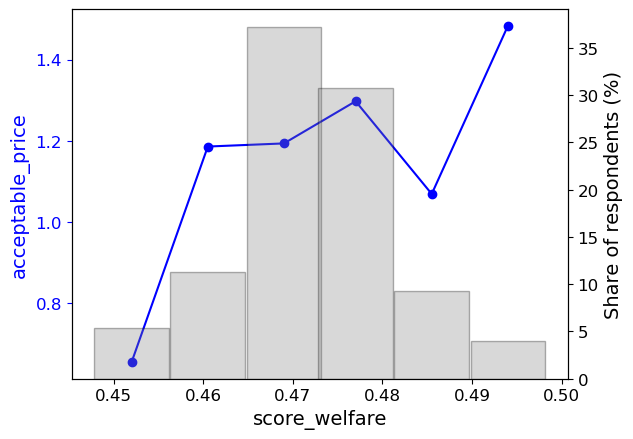

In [ ]:
plot_mobility_loss("score_welfare","acceptable_price", df_reg)
    

c:\Users\1738037\OneDrive - UAB\1- CLIMGROW Charlotte\1- PSC cities\code_barcelona\plotting_tools.py:288: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  df_reg.groupby('bin').apply(lambda g: pd.Series({
c:\Users\1738037\OneDrive - UAB\1- CLIMGROW Charlotte\1- PSC cities\code_barcelona\plotting_tools.py:288: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  df_reg.groupby('bin').apply(lambda g: pd.Series({


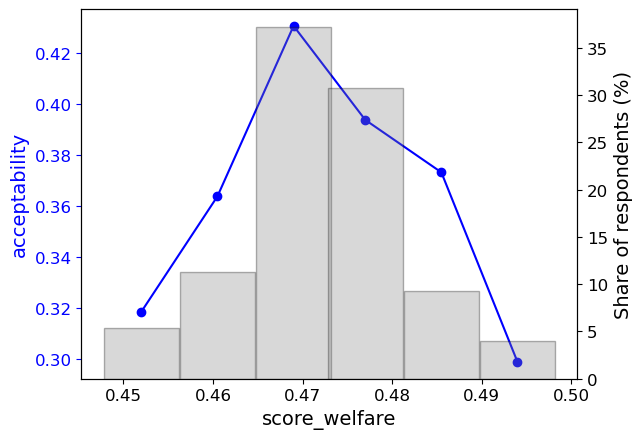

In [ ]:
plot_mobility_loss("score_welfare","acceptability", df_reg)
    

In [ ]:
def plot_mobility_loss(x,y, df_reg):
    label_x = x
    label_y = y
    x = df_reg[x]
    y = df_reg[y]
    w = df_reg.PESAIX   # survey weights

    # Define bins
    bins = np.linspace(x.min(), x.max(), 20)
    df_reg['bin'] = pd.cut(x, bins)

    # Weighted mean function
    def weighted_mean(series, weights):
        return np.average(series, weights=weights)

    # Group by bin and calculate weighted stats
    grouped = (
        df_reg.groupby('bin').apply(lambda g: pd.Series({
            "mean": weighted_mean(g[y.name], g[w.name]),
            "share": g[w.name].sum() / w.sum() * 100  # % of total respondents
            })))

    # Drop bins with too few weighted respondents (optional, e.g. <1% share)
    grouped = grouped[grouped['share'] >= 1]

    # Get bin centers for plotting
    bin_centers = [interval.mid for interval in grouped.index]

        # --- Plot ---
    fig, ax1 = plt.subplots()

    # Line plot: weighted mean acceptable toll
    ax1.plot(bin_centers, grouped['mean'], marker='o', color='blue')
    ax1.set_xlabel(label_x, fontsize=14)
    ax1.set_ylabel(label_y, fontsize=14, color='blue')
    ax1.tick_params(axis='x', labelsize=12)
    ax1.tick_params(axis='y', labelsize=12, colors='blue')

    # Bar plot: share of respondents (%)
    ax2 = ax1.twinx()
    ax2.bar(
        bin_centers,
        grouped['share'],
        width=(bins[1]-bins[0]),  # a bit narrower than bin width
        alpha=0.3,
        color='gray',
        edgecolor='black',
        align="center")
    ax2.set_ylabel('Share of respondents (%)', color='black', fontsize=14)
    ax2.tick_params(axis='y', labelsize=12, colors='black')

    plt.show()

In [ ]:
plot_mobility_loss("score_welfare","acceptable_price", df_reg)

<ipython-input-71-82f1e3eefb9b>:18: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  df_reg.groupby('bin').apply(lambda g: pd.Series({


ZeroDivisionError: Weights sum to zero, can't be normalized

In [ ]:
plot_mobility_loss("score_welfare","acceptability", df_reg)
    

<ipython-input-71-82f1e3eefb9b>:18: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  df_reg.groupby('bin').apply(lambda g: pd.Series({


ZeroDivisionError: Weights sum to zero, can't be normalized

In [ ]:
def plot_mobility_loss(x,y, df_reg):
    label_x = x
    label_y = y
    x = df_reg[x]
    y = df_reg[y]
    w = df_reg.PESAIX   # survey weights

    # Define bins
    bins = np.linspace(x.min(), x.max(), 15)
    df_reg['bin'] = pd.cut(x, bins)

    # Weighted mean function
    def weighted_mean(series, weights):
        return np.average(series, weights=weights)

    # Group by bin and calculate weighted stats
    grouped = (
        df_reg.groupby('bin').apply(lambda g: pd.Series({
            "mean": weighted_mean(g[y.name], g[w.name]),
            "share": g[w.name].sum() / w.sum() * 100  # % of total respondents
            })))

    # Drop bins with too few weighted respondents (optional, e.g. <1% share)
    grouped = grouped[grouped['share'] >= 1]

    # Get bin centers for plotting
    bin_centers = [interval.mid for interval in grouped.index]

        # --- Plot ---
    fig, ax1 = plt.subplots()

    # Line plot: weighted mean acceptable toll
    ax1.plot(bin_centers, grouped['mean'], marker='o', color='blue')
    ax1.set_xlabel(label_x, fontsize=14)
    ax1.set_ylabel(label_y, fontsize=14, color='blue')
    ax1.tick_params(axis='x', labelsize=12)
    ax1.tick_params(axis='y', labelsize=12, colors='blue')

    # Bar plot: share of respondents (%)
    ax2 = ax1.twinx()
    ax2.bar(
        bin_centers,
        grouped['share'],
        width=(bins[1]-bins[0]),  # a bit narrower than bin width
        alpha=0.3,
        color='gray',
        edgecolor='black',
        align="center")
    ax2.set_ylabel('Share of respondents (%)', color='black', fontsize=14)
    ax2.tick_params(axis='y', labelsize=12, colors='black')

    plt.show()

In [ ]:
plot_mobility_loss("score_welfare","acceptable_price", df_reg)

<ipython-input-74-ad041f975811>:18: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  df_reg.groupby('bin').apply(lambda g: pd.Series({


ZeroDivisionError: Weights sum to zero, can't be normalized

In [ ]:
def plot_mobility_loss(x,y, df_reg):
    label_x = x
    label_y = y
    x = df_reg[x]
    y = df_reg[y]
    w = df_reg.PESAIX   # survey weights

    # Define bins
    bins = np.linspace(x.min(), x.max(), 10)
    df_reg['bin'] = pd.cut(x, bins)

    # Weighted mean function
    def weighted_mean(series, weights):
        return np.average(series, weights=weights)

    # Group by bin and calculate weighted stats
    grouped = (
        df_reg.groupby('bin').apply(lambda g: pd.Series({
            "mean": weighted_mean(g[y.name], g[w.name]),
            "share": g[w.name].sum() / w.sum() * 100  # % of total respondents
            })))

    # Drop bins with too few weighted respondents (optional, e.g. <1% share)
    grouped = grouped[grouped['share'] >= 1]

    # Get bin centers for plotting
    bin_centers = [interval.mid for interval in grouped.index]

        # --- Plot ---
    fig, ax1 = plt.subplots()

    # Line plot: weighted mean acceptable toll
    ax1.plot(bin_centers, grouped['mean'], marker='o', color='blue')
    ax1.set_xlabel(label_x, fontsize=14)
    ax1.set_ylabel(label_y, fontsize=14, color='blue')
    ax1.tick_params(axis='x', labelsize=12)
    ax1.tick_params(axis='y', labelsize=12, colors='blue')

    # Bar plot: share of respondents (%)
    ax2 = ax1.twinx()
    ax2.bar(
        bin_centers,
        grouped['share'],
        width=(bins[1]-bins[0]),  # a bit narrower than bin width
        alpha=0.3,
        color='gray',
        edgecolor='black',
        align="center")
    ax2.set_ylabel('Share of respondents (%)', color='black', fontsize=14)
    ax2.tick_params(axis='y', labelsize=12, colors='black')

    plt.show()

<ipython-input-76-fb5fb2eec753>:18: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  df_reg.groupby('bin').apply(lambda g: pd.Series({
<ipython-input-76-fb5fb2eec753>:18: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  df_reg.groupby('bin').apply(lambda g: pd.Series({


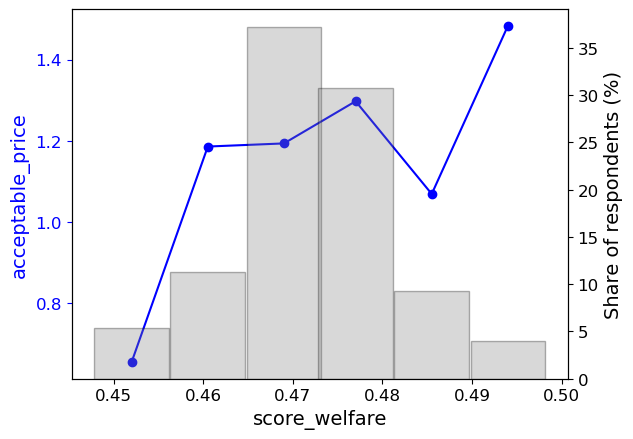

In [ ]:
plot_mobility_loss("score_welfare","acceptable_price", df_reg)

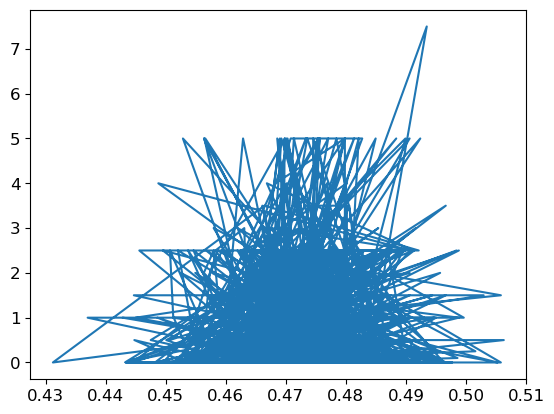

In [ ]:
plt.plot(df_reg.score_welfare, df_reg.acceptable_price)

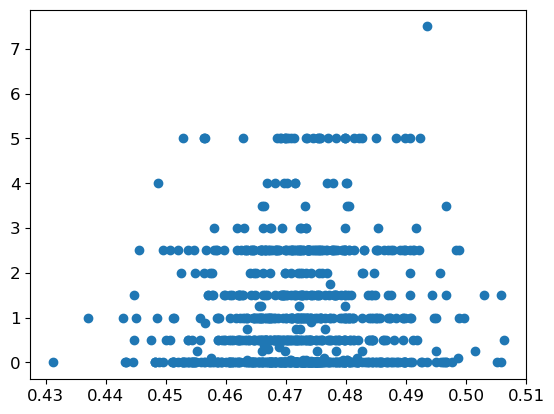

In [ ]:
plt.scatter(df_reg.score_welfare, df_reg.acceptable_price)

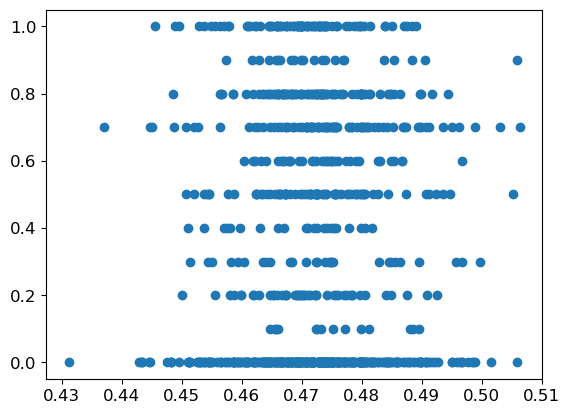

In [ ]:
plt.scatter(df_reg.score_welfare, df_reg.acceptability)

In [ ]:
plot_mobility_loss("acceptable_price","score_welfare", df_reg)
    

<ipython-input-76-fb5fb2eec753>:18: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  df_reg.groupby('bin').apply(lambda g: pd.Series({


ZeroDivisionError: Weights sum to zero, can't be normalized

In [ ]:
def plot_mobility_loss(x,y, df_reg):
    label_x = x
    label_y = y
    x = df_reg[x]
    y = df_reg[y]
    w = df_reg.PESAIX   # survey weights

    # Define bins
    bins = np.linspace(x.min(), x.max(), 5)
    df_reg['bin'] = pd.cut(x, bins)

    # Weighted mean function
    def weighted_mean(series, weights):
        return np.average(series, weights=weights)

    # Group by bin and calculate weighted stats
    grouped = (
        df_reg.groupby('bin').apply(lambda g: pd.Series({
            "mean": weighted_mean(g[y.name], g[w.name]),
            "share": g[w.name].sum() / w.sum() * 100  # % of total respondents
            })))

    # Drop bins with too few weighted respondents (optional, e.g. <1% share)
    grouped = grouped[grouped['share'] >= 1]

    # Get bin centers for plotting
    bin_centers = [interval.mid for interval in grouped.index]

        # --- Plot ---
    fig, ax1 = plt.subplots()

    # Line plot: weighted mean acceptable toll
    ax1.plot(bin_centers, grouped['mean'], marker='o', color='blue')
    ax1.set_xlabel(label_x, fontsize=14)
    ax1.set_ylabel(label_y, fontsize=14, color='blue')
    ax1.tick_params(axis='x', labelsize=12)
    ax1.tick_params(axis='y', labelsize=12, colors='blue')

    # Bar plot: share of respondents (%)
    ax2 = ax1.twinx()
    ax2.bar(
        bin_centers,
        grouped['share'],
        width=(bins[1]-bins[0]),  # a bit narrower than bin width
        alpha=0.3,
        color='gray',
        edgecolor='black',
        align="center")
    ax2.set_ylabel('Share of respondents (%)', color='black', fontsize=14)
    ax2.tick_params(axis='y', labelsize=12, colors='black')

    plt.show()

<ipython-input-82-b7bd4a41f925>:18: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  df_reg.groupby('bin').apply(lambda g: pd.Series({
<ipython-input-82-b7bd4a41f925>:18: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  df_reg.groupby('bin').apply(lambda g: pd.Series({


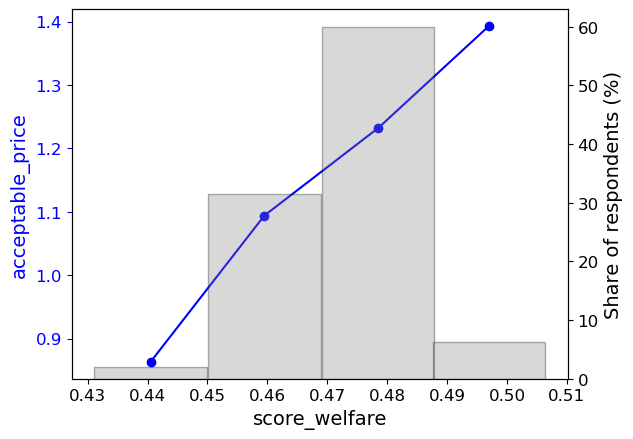

In [ ]:
plot_mobility_loss("score_welfare","acceptable_price", df_reg)

<ipython-input-82-b7bd4a41f925>:18: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  df_reg.groupby('bin').apply(lambda g: pd.Series({
<ipython-input-82-b7bd4a41f925>:18: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  df_reg.groupby('bin').apply(lambda g: pd.Series({


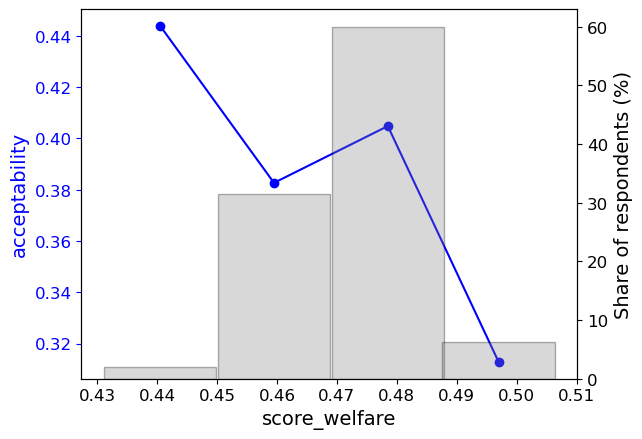

In [ ]:
plot_mobility_loss("score_welfare","acceptability", df_reg)
    

In [ ]:
def plot_mobility_loss(x,y, df_reg):
    label_x = x
    label_y = y
    x = df_reg[x]
    y = df_reg[y]
    w = df_reg.PESAIX   # survey weights

    # Define bins
    bins = np.linspace(x.min(), x.max(), 15)
    df_reg['bin'] = pd.cut(x, bins)

    # Weighted mean function
    def weighted_mean(series, weights):
        return np.average(series, weights=weights)

    # Group by bin and calculate weighted stats
    grouped = (
        df_reg.groupby('bin').apply(lambda g: pd.Series({
            "mean": weighted_mean(g[y.name], g[w.name]),
            "share": g[w.name].sum() / w.sum() * 100  # % of total respondents
            })))

    # Drop bins with too few weighted respondents (optional, e.g. <1% share)
    grouped = grouped[grouped['share'] >= 1]

    # Get bin centers for plotting
    bin_centers = [interval.mid for interval in grouped.index]

        # --- Plot ---
    fig, ax1 = plt.subplots()

    # Line plot: weighted mean acceptable toll
    ax1.plot(bin_centers, grouped['mean'], marker='o', color='blue')
    ax1.set_xlabel(label_x, fontsize=14)
    ax1.set_ylabel(label_y, fontsize=14, color='blue')
    ax1.tick_params(axis='x', labelsize=12)
    ax1.tick_params(axis='y', labelsize=12, colors='blue')

    # Bar plot: share of respondents (%)
    ax2 = ax1.twinx()
    ax2.bar(
        bin_centers,
        grouped['share'],
        width=(bins[1]-bins[0]),  # a bit narrower than bin width
        alpha=0.3,
        color='gray',
        edgecolor='black',
        align="center")
    ax2.set_ylabel('Share of respondents (%)', color='black', fontsize=14)
    ax2.tick_params(axis='y', labelsize=12, colors='black')

    plt.show()

In [ ]:
plot_mobility_loss("score_welfare","acceptable_price", df_reg)

<ipython-input-85-d9c57be9b40b>:18: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  df_reg.groupby('bin').apply(lambda g: pd.Series({


ZeroDivisionError: Weights sum to zero, can't be normalized

In [ ]:
def plot_mobility_loss(x,y, df_reg):
    label_x = x
    label_y = y
    x = df_reg[x]
    y = df_reg[y]
    w = df_reg.PESAIX   # survey weights

    # Define bins
    bins = np.linspace(x.min(), x.max(), 15)
    df_reg['bin'] = pd.cut(x, bins)

    # Weighted mean function
    def weighted_mean(series, weights):
        wsum = weights.sum()
        if wsum == 0:
            return np.nan
        return np.average(series, weights=weights)

    # Group by bin and calculate weighted stats
    grouped = (
        df_reg.groupby('bin').apply(lambda g: pd.Series({
            "mean": weighted_mean(g[y.name], g[w.name]),
            "share": g[w.name].sum() / w.sum() * 100  # % of total respondents
            })))

    # Drop bins with too few weighted respondents (optional, e.g. <1% share)
    grouped = grouped[grouped['share'] >= 1]

    # Get bin centers for plotting
    bin_centers = [interval.mid for interval in grouped.index]

        # --- Plot ---
    fig, ax1 = plt.subplots()

    # Line plot: weighted mean acceptable toll
    ax1.plot(bin_centers, grouped['mean'], marker='o', color='blue')
    ax1.set_xlabel(label_x, fontsize=14)
    ax1.set_ylabel(label_y, fontsize=14, color='blue')
    ax1.tick_params(axis='x', labelsize=12)
    ax1.tick_params(axis='y', labelsize=12, colors='blue')

    # Bar plot: share of respondents (%)
    ax2 = ax1.twinx()
    ax2.bar(
        bin_centers,
        grouped['share'],
        width=(bins[1]-bins[0]),  # a bit narrower than bin width
        alpha=0.3,
        color='gray',
        edgecolor='black',
        align="center")
    ax2.set_ylabel('Share of respondents (%)', color='black', fontsize=14)
    ax2.tick_params(axis='y', labelsize=12, colors='black')

    plt.show()

<ipython-input-87-8b06239bcbde>:21: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  df_reg.groupby('bin').apply(lambda g: pd.Series({
<ipython-input-87-8b06239bcbde>:21: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  df_reg.groupby('bin').apply(lambda g: pd.Series({


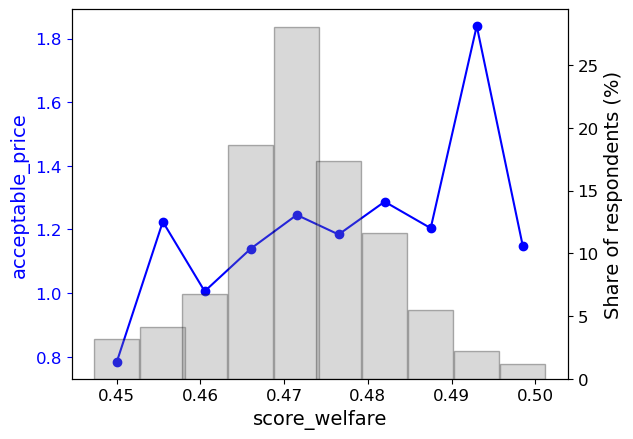

In [ ]:
plot_mobility_loss("score_welfare","acceptable_price", df_reg)
    

<ipython-input-87-8b06239bcbde>:21: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  df_reg.groupby('bin').apply(lambda g: pd.Series({
<ipython-input-87-8b06239bcbde>:21: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  df_reg.groupby('bin').apply(lambda g: pd.Series({


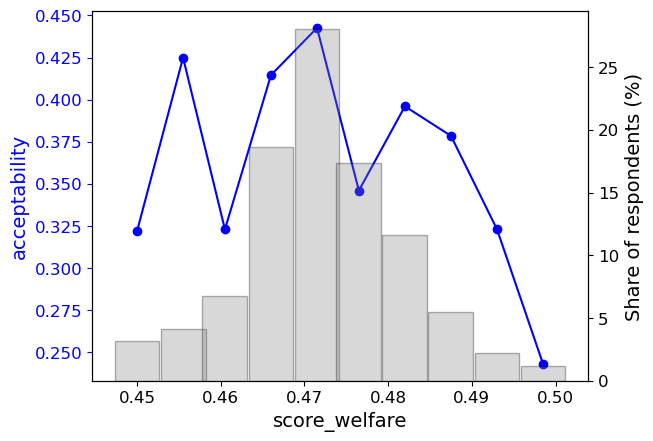

In [ ]:
plot_mobility_loss("score_welfare","acceptability", df_reg)
    

In [ ]:
def plot_mobility_loss(x,y, df_reg):
    label_x = x
    label_y = y
    x = df_reg[x]
    y = df_reg[y]
    w = df_reg.PESAIX   # survey weights

    # Define bins
    bins = np.linspace(x.min(), x.max(), 20)
    df_reg['bin'] = pd.cut(x, bins)

    # Weighted mean function
    def weighted_mean(series, weights):
        wsum = weights.sum()
        if wsum == 0:
            return np.nan
        return np.average(series, weights=weights)

    # Group by bin and calculate weighted stats
    grouped = (
        df_reg.groupby('bin').apply(lambda g: pd.Series({
            "mean": weighted_mean(g[y.name], g[w.name]),
            "share": g[w.name].sum() / w.sum() * 100  # % of total respondents
            })))

    # Drop bins with too few weighted respondents (optional, e.g. <1% share)
    grouped = grouped[grouped['share'] >= 1]

    # Get bin centers for plotting
    bin_centers = [interval.mid for interval in grouped.index]

        # --- Plot ---
    fig, ax1 = plt.subplots()

    # Line plot: weighted mean acceptable toll
    ax1.plot(bin_centers, grouped['mean'], marker='o', color='blue')
    ax1.set_xlabel(label_x, fontsize=14)
    ax1.set_ylabel(label_y, fontsize=14, color='blue')
    ax1.tick_params(axis='x', labelsize=12)
    ax1.tick_params(axis='y', labelsize=12, colors='blue')

    # Bar plot: share of respondents (%)
    ax2 = ax1.twinx()
    ax2.bar(
        bin_centers,
        grouped['share'],
        width=(bins[1]-bins[0]),  # a bit narrower than bin width
        alpha=0.3,
        color='gray',
        edgecolor='black',
        align="center")
    ax2.set_ylabel('Share of respondents (%)', color='black', fontsize=14)
    ax2.tick_params(axis='y', labelsize=12, colors='black')

    plt.show()

In [ ]:
    #Export plots

<ipython-input-90-9db4297b1aa2>:21: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  df_reg.groupby('bin').apply(lambda g: pd.Series({
<ipython-input-90-9db4297b1aa2>:21: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  df_reg.groupby('bin').apply(lambda g: pd.Series({


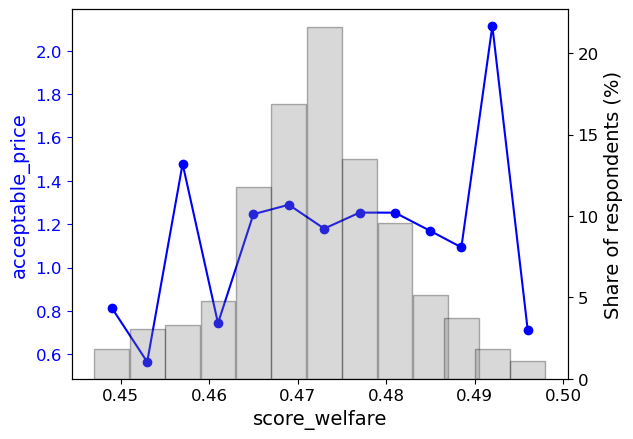

In [ ]:
plot_mobility_loss("score_welfare","acceptable_price", df_reg)
    

<ipython-input-90-9db4297b1aa2>:21: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  df_reg.groupby('bin').apply(lambda g: pd.Series({
<ipython-input-90-9db4297b1aa2>:21: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  df_reg.groupby('bin').apply(lambda g: pd.Series({


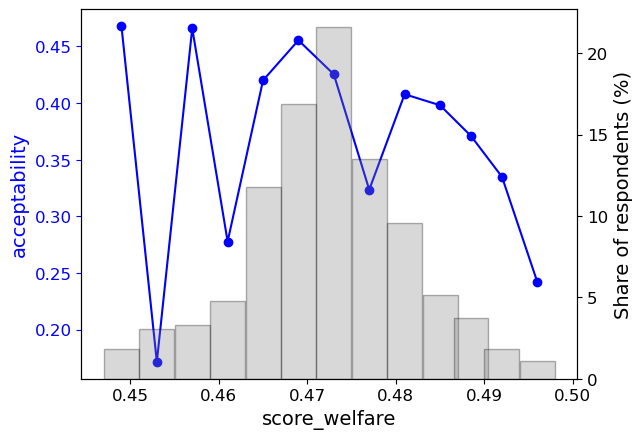

In [ ]:
plot_mobility_loss("score_welfare","acceptability", df_reg)
    

In [ ]:
def plot_mobility_loss(x,y, df_reg):
    label_x = x
    label_y = y
    x = df_reg[x]
    y = df_reg[y]
    w = df_reg.PESAIX   # survey weights

    # Define bins
    bins = np.linspace(x.min(), x.max(), 10)
    df_reg['bin'] = pd.cut(x, bins)

    # Weighted mean function
    def weighted_mean(series, weights):
        wsum = weights.sum()
        if wsum == 0:
            return np.nan
        return np.average(series, weights=weights)

    # Group by bin and calculate weighted stats
    grouped = (
        df_reg.groupby('bin').apply(lambda g: pd.Series({
            "mean": weighted_mean(g[y.name], g[w.name]),
            "share": g[w.name].sum() / w.sum() * 100  # % of total respondents
            })))

    # Drop bins with too few weighted respondents (optional, e.g. <1% share)
    grouped = grouped[grouped['share'] >= 1]

    # Get bin centers for plotting
    bin_centers = [interval.mid for interval in grouped.index]

        # --- Plot ---
    fig, ax1 = plt.subplots()

    # Line plot: weighted mean acceptable toll
    ax1.plot(bin_centers, grouped['mean'], marker='o', color='blue')
    ax1.set_xlabel(label_x, fontsize=14)
    ax1.set_ylabel(label_y, fontsize=14, color='blue')
    ax1.tick_params(axis='x', labelsize=12)
    ax1.tick_params(axis='y', labelsize=12, colors='blue')

    # Bar plot: share of respondents (%)
    ax2 = ax1.twinx()
    ax2.bar(
        bin_centers,
        grouped['share'],
        width=(bins[1]-bins[0]),  # a bit narrower than bin width
        alpha=0.3,
        color='gray',
        edgecolor='black',
        align="center")
    ax2.set_ylabel('Share of respondents (%)', color='black', fontsize=14)
    ax2.tick_params(axis='y', labelsize=12, colors='black')

    plt.show()

In [ ]:
LOGISTIC_PARAM_WELFARE

-0.3

In [ ]:
LOGISTIC_PARAM_WELFARE = - 0.2

In [ ]:
gdf_init, _, _ = compute_transport_cost_poly_i(gdf, travel_time_matrix_car, travel_time_matrix_transit, PRICE_TIME, WORKING_DAYS, FIXED_COST_CAR, PRICE_FUEL, LAMBDA, ARRAY_WAGE_LOW, ARRAY_WAGE_MED, ARRAY_WAGE_HIGH, jobs_in_toll_area, houses_in_toll_area, 0, income_levels, wage_factors, "baseline", 0, 0)
 
utility_init = {lvl: compute_utility_manually(gdf_init[f"wage_{lvl}"],
                                              gdf_init[f"transport_cost_{lvl}"],
                                              q_group[f"{lvl}"],
                                              R_group[f"{lvl}"],
                                              BETA, gdf["amenities"]
                                              ) for lvl in income_levels}

gdf_tax, _, _ = compute_transport_cost_poly_i(gdf, travel_time_matrix_car, travel_time_matrix_transit, PRICE_TIME, WORKING_DAYS, FIXED_COST_CAR, PRICE_FUEL, LAMBDA, ARRAY_WAGE_LOW, ARRAY_WAGE_MED, ARRAY_WAGE_HIGH, jobs_in_toll_area, houses_in_toll_area, 0.5, income_levels, wage_factors, "baseline", 0, 0)
 
utility_tax = {lvl: compute_utility_manually(gdf_tax[f"wage_{lvl}"],
                                              gdf_tax[f"transport_cost_{lvl}"],
                                              q_group[f"{lvl}"],
                                              R_group[f"{lvl}"],
                                              BETA, gdf["amenities"]
                                              ) for lvl in income_levels}

for lvl in income_levels:
    gdf[f"score_welfare_{lvl.lower()}"] = compute_score(compute_change_in_welfare(utility_init[lvl], utility_tax[lvl]), LOGISTIC_PARAM_WELFARE)

expected_welfare_loss = gdf[["ID", "geometry"] + [f"score_welfare_{lvl.lower()}" for lvl in income_levels]]

SignificanceResult(statistic=0.6035851309092074, pvalue=3.229002034877782e-98)


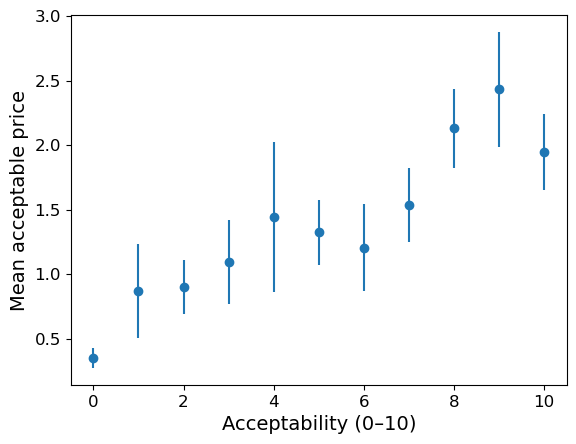

c:\Users\1738037\OneDrive - UAB\1- CLIMGROW Charlotte\1- PSC cities\code_barcelona\plotting_tools.py:288: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  df_reg.groupby('bin').apply(lambda g: pd.Series({
c:\Users\1738037\OneDrive - UAB\1- CLIMGROW Charlotte\1- PSC cities\code_barcelona\plotting_tools.py:288: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  df_reg.groupby('bin').apply(lambda g: pd.Series({


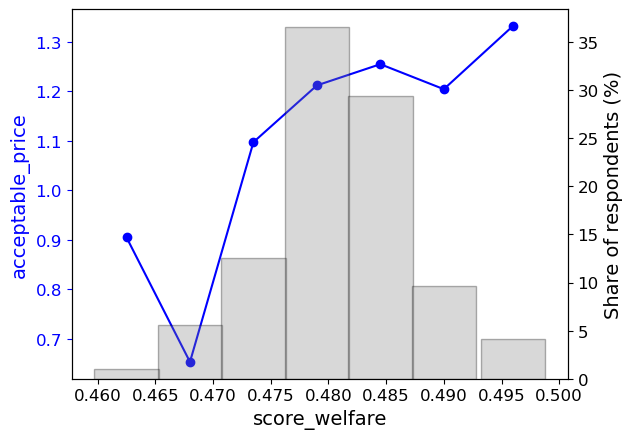

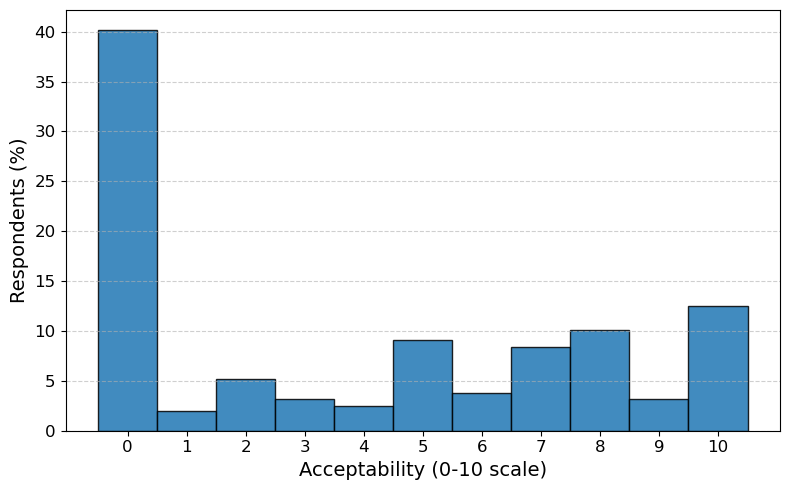

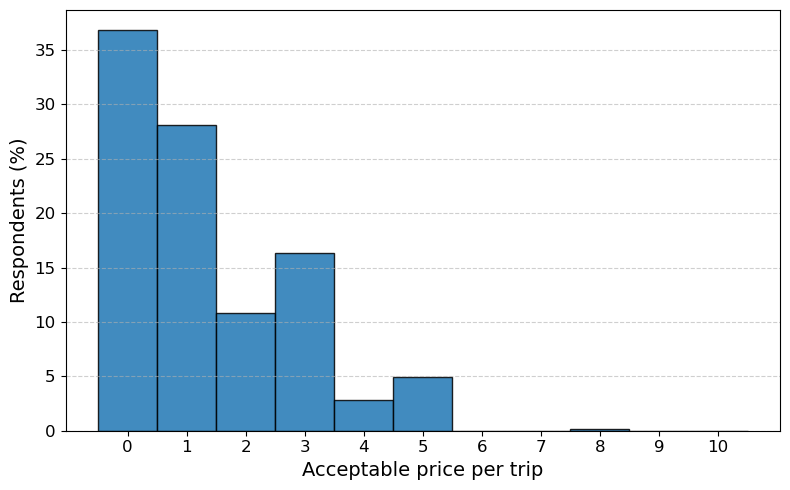

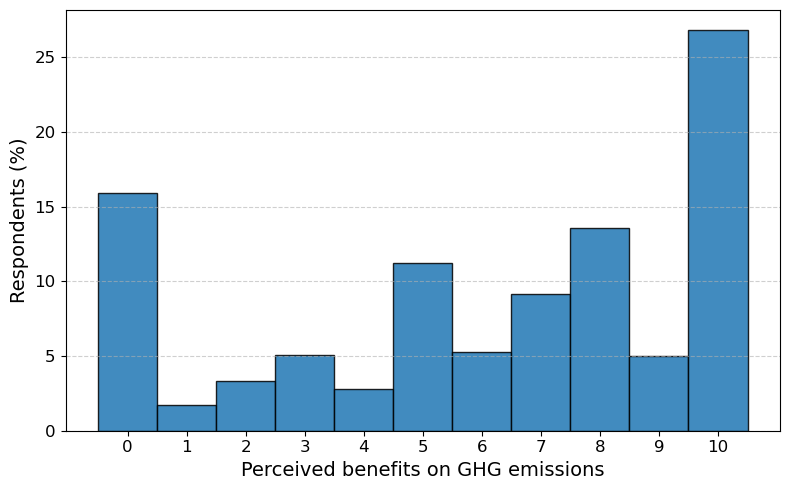

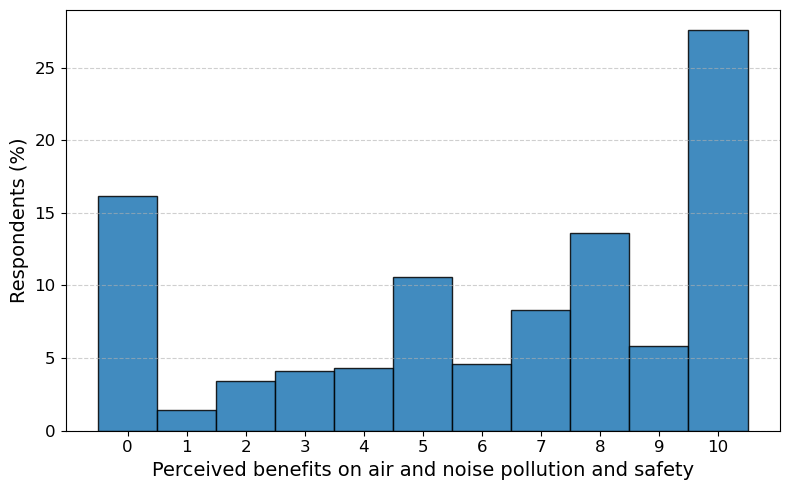

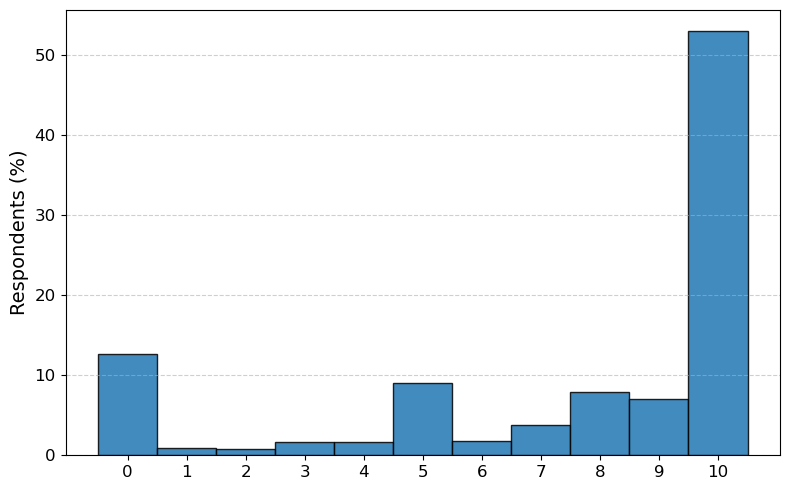

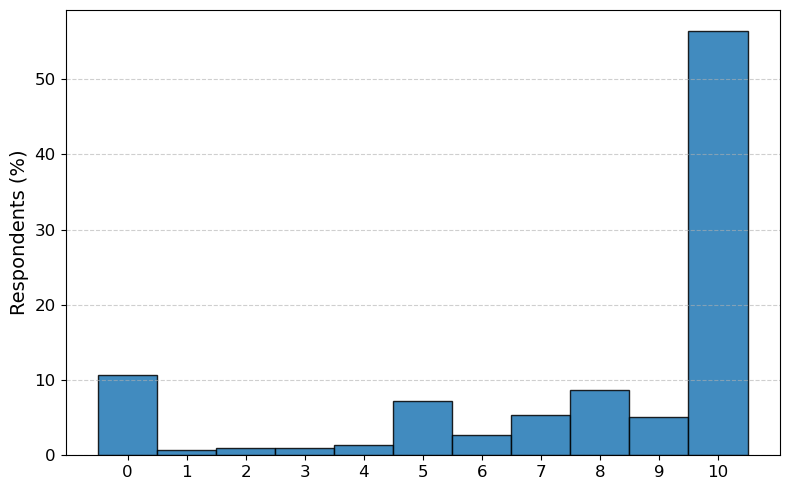

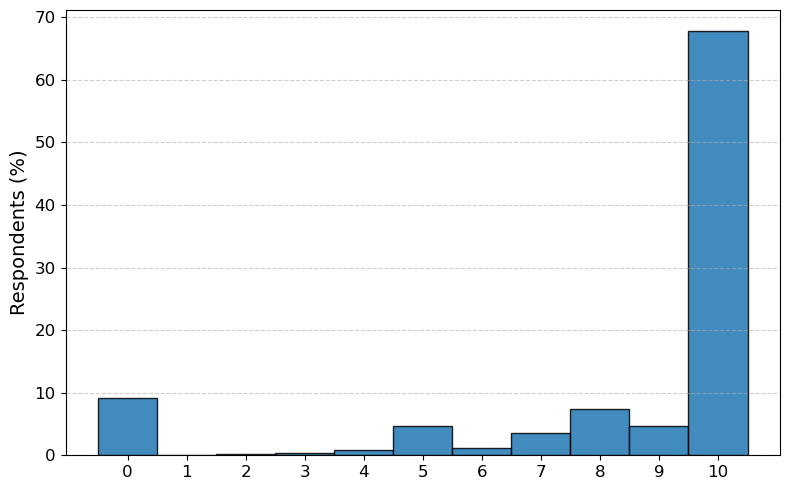

                             WLS Regression Results                            
Dep. Variable:                       y   R-squared:                       0.418
Model:                             WLS   Adj. R-squared:                  0.415
Method:                  Least Squares   F-statistic:                     136.5
Date:              jeu., 12 févr. 2026   Prob (F-statistic):          4.73e-109
Time:                         10:30:28   Log-Likelihood:                -263.60
No. Observations:                  955   AIC:                             539.2
Df Residuals:                      949   BIC:                             568.4
Df Model:                            5                                         
Covariance Type:             nonrobust                                         
                      coef    std err          t      P>|t|      [0.025      0.975]
-----------------------------------------------------------------------------------
const               1.0879      

(array([ 1.08794136,  0.30039923,  0.40888497, -2.40323837,  0.02039865,
         0.07449125]),
 array([-5.52045152,  0.56143683,  1.21499605, 11.51758573,  0.15222984,
         0.16540941]),
 0.3,
 0.5,
 0.7,
 0.48122757073505495,
 0.7,
 0)

In [ ]:
import_opinion_parameters2(path_data, scenario, expected_welfare_loss)

In [ ]:
LOGISTIC_PARAM_WELFARE = - 0.4

In [ ]:
gdf_init, _, _ = compute_transport_cost_poly_i(gdf, travel_time_matrix_car, travel_time_matrix_transit, PRICE_TIME, WORKING_DAYS, FIXED_COST_CAR, PRICE_FUEL, LAMBDA, ARRAY_WAGE_LOW, ARRAY_WAGE_MED, ARRAY_WAGE_HIGH, jobs_in_toll_area, houses_in_toll_area, 0, income_levels, wage_factors, "baseline", 0, 0)
 
utility_init = {lvl: compute_utility_manually(gdf_init[f"wage_{lvl}"],
                                              gdf_init[f"transport_cost_{lvl}"],
                                              q_group[f"{lvl}"],
                                              R_group[f"{lvl}"],
                                              BETA, gdf["amenities"]
                                              ) for lvl in income_levels}

gdf_tax, _, _ = compute_transport_cost_poly_i(gdf, travel_time_matrix_car, travel_time_matrix_transit, PRICE_TIME, WORKING_DAYS, FIXED_COST_CAR, PRICE_FUEL, LAMBDA, ARRAY_WAGE_LOW, ARRAY_WAGE_MED, ARRAY_WAGE_HIGH, jobs_in_toll_area, houses_in_toll_area, 0.5, income_levels, wage_factors, "baseline", 0, 0)
 
utility_tax = {lvl: compute_utility_manually(gdf_tax[f"wage_{lvl}"],
                                              gdf_tax[f"transport_cost_{lvl}"],
                                              q_group[f"{lvl}"],
                                              R_group[f"{lvl}"],
                                              BETA, gdf["amenities"]
                                              ) for lvl in income_levels}

for lvl in income_levels:
    gdf[f"score_welfare_{lvl.lower()}"] = compute_score(compute_change_in_welfare(utility_init[lvl], utility_tax[lvl]), LOGISTIC_PARAM_WELFARE)

expected_welfare_loss = gdf[["ID", "geometry"] + [f"score_welfare_{lvl.lower()}" for lvl in income_levels]]

SignificanceResult(statistic=0.6035851309092074, pvalue=3.229002034877782e-98)


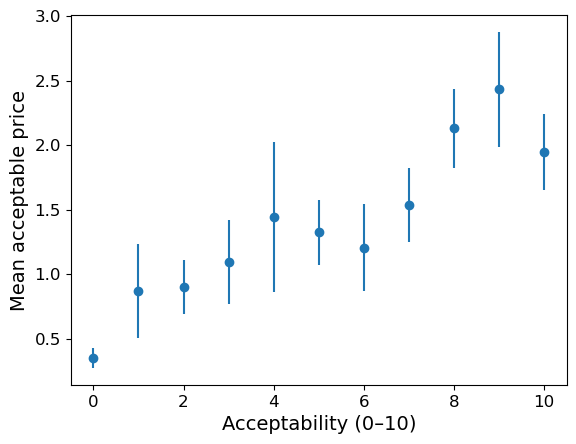

c:\Users\1738037\OneDrive - UAB\1- CLIMGROW Charlotte\1- PSC cities\code_barcelona\plotting_tools.py:288: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  df_reg.groupby('bin').apply(lambda g: pd.Series({
c:\Users\1738037\OneDrive - UAB\1- CLIMGROW Charlotte\1- PSC cities\code_barcelona\plotting_tools.py:288: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  df_reg.groupby('bin').apply(lambda g: pd.Series({


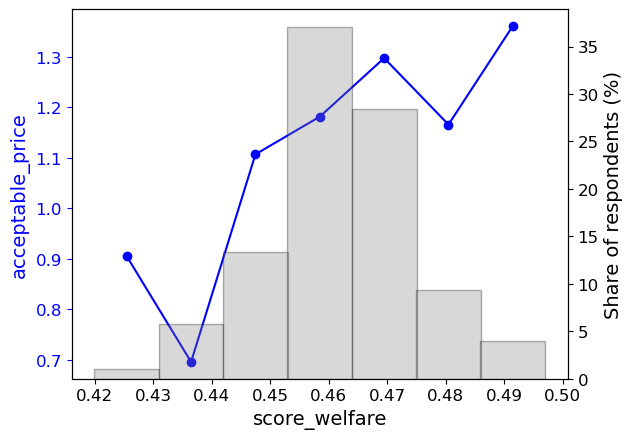

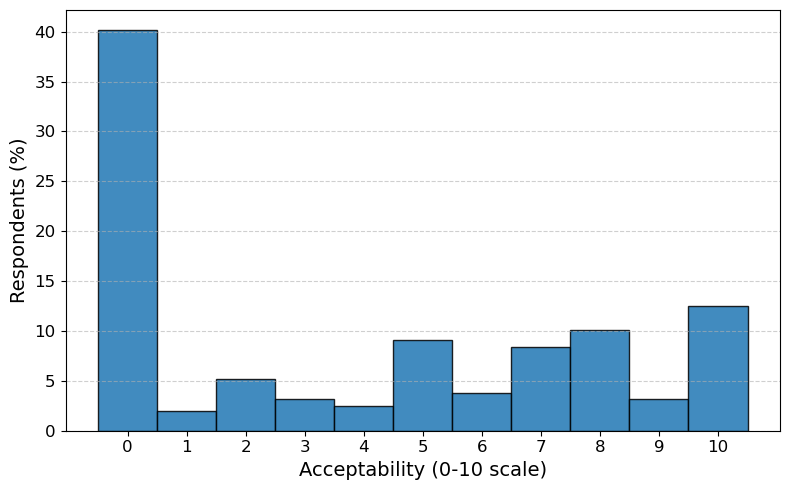

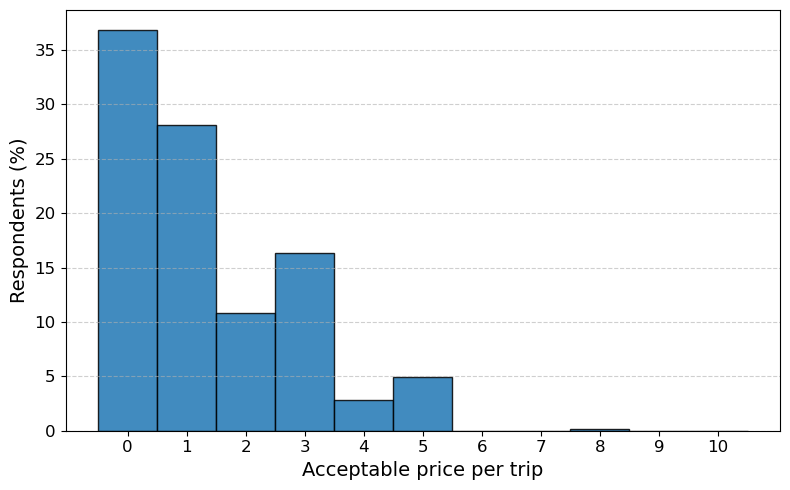

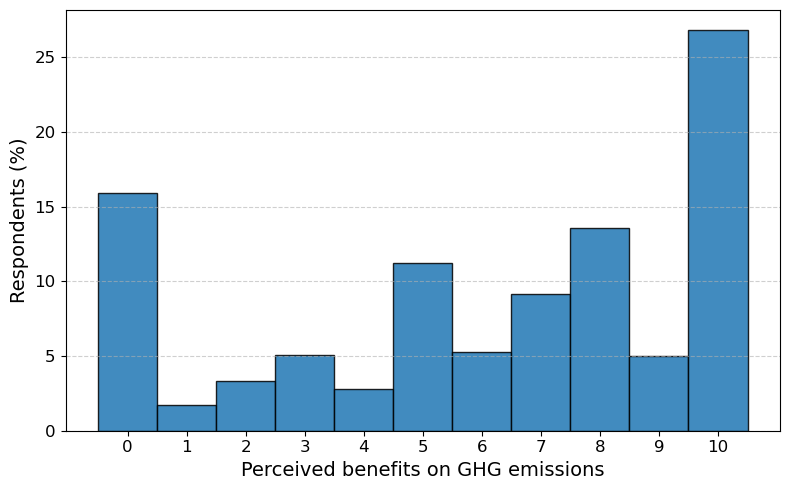

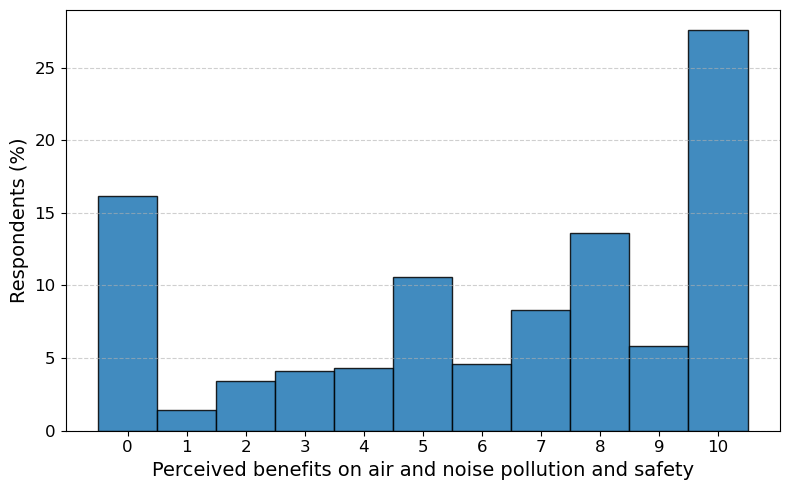

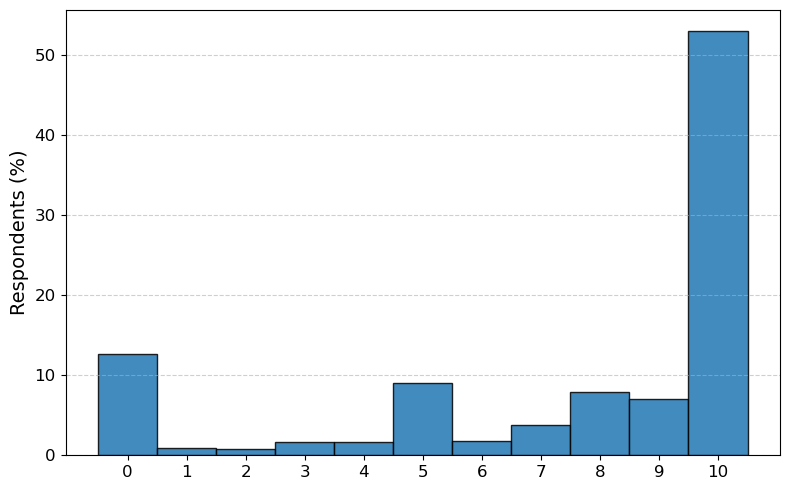

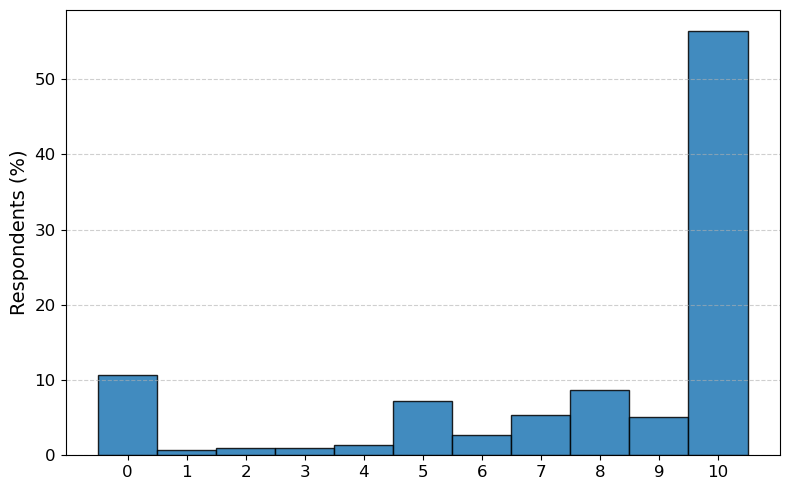

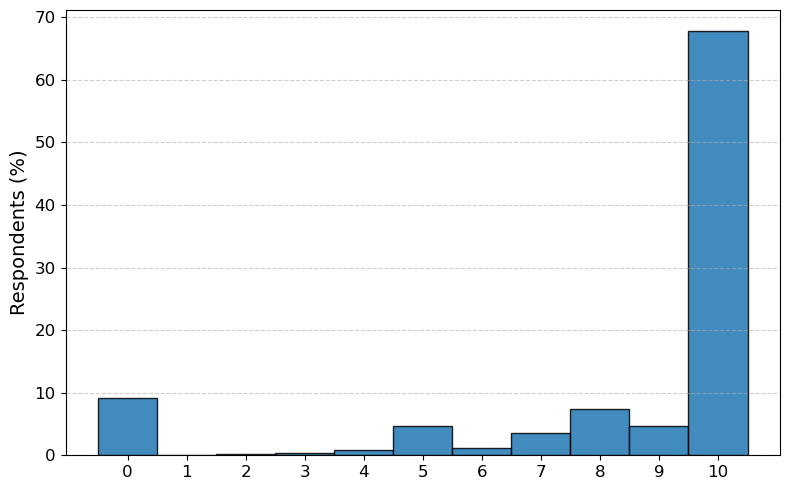

                             WLS Regression Results                            
Dep. Variable:                       y   R-squared:                       0.418
Model:                             WLS   Adj. R-squared:                  0.415
Method:                  Least Squares   F-statistic:                     136.5
Date:              jeu., 12 févr. 2026   Prob (F-statistic):          4.71e-109
Time:                         10:31:30   Log-Likelihood:                -263.60
No. Observations:                  955   AIC:                             539.2
Df Residuals:                      949   BIC:                             568.4
Df Model:                            5                                         
Covariance Type:             nonrobust                                         
                      coef    std err          t      P>|t|      [0.025      0.975]
-----------------------------------------------------------------------------------
const               0.4909      

(array([ 0.49086005,  0.30037842,  0.40889843, -1.20949844,  0.02042299,
         0.07450926]),
 array([-2.64878443,  0.56152367,  1.21497241,  5.77456328,  0.15167505,
         0.16545966]),
 0.3,
 0.5,
 0.7,
 0.4625079908211934,
 0.7,
 0)

In [ ]:
import_opinion_parameters2(path_data, scenario, expected_welfare_loss)

<ipython-input-94-b9aeb33eacd6>:21: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  df_reg.groupby('bin').apply(lambda g: pd.Series({
<ipython-input-94-b9aeb33eacd6>:21: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  df_reg.groupby('bin').apply(lambda g: pd.Series({


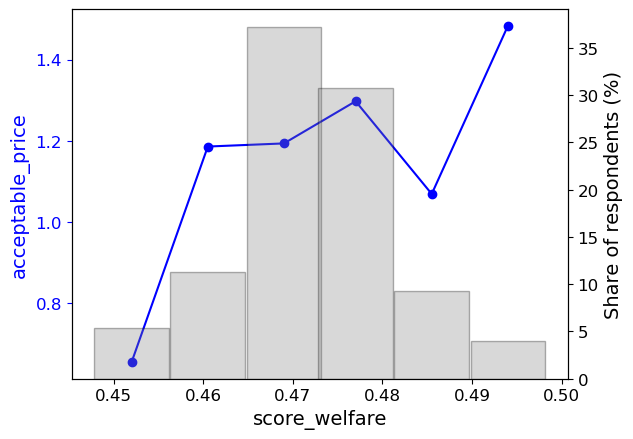

In [ ]:
plot_mobility_loss("score_welfare","acceptable_price", df_reg)
    

<ipython-input-94-b9aeb33eacd6>:21: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  df_reg.groupby('bin').apply(lambda g: pd.Series({
<ipython-input-94-b9aeb33eacd6>:21: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  df_reg.groupby('bin').apply(lambda g: pd.Series({


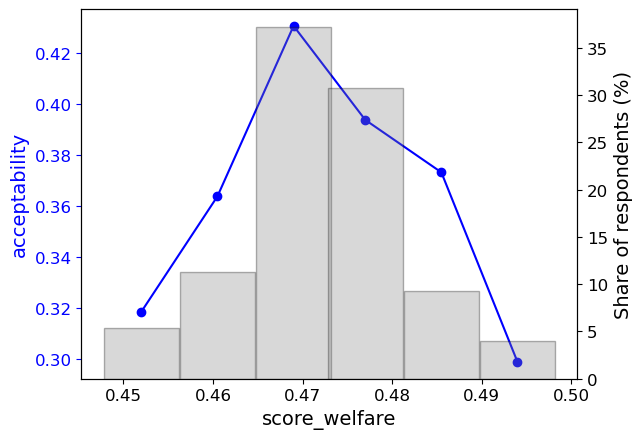

In [ ]:
plot_mobility_loss("score_welfare","acceptability", df_reg)
    

<ipython-input-94-b9aeb33eacd6>:21: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  df_reg.groupby('bin').apply(lambda g: pd.Series({
<ipython-input-94-b9aeb33eacd6>:21: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  df_reg.groupby('bin').apply(lambda g: pd.Series({


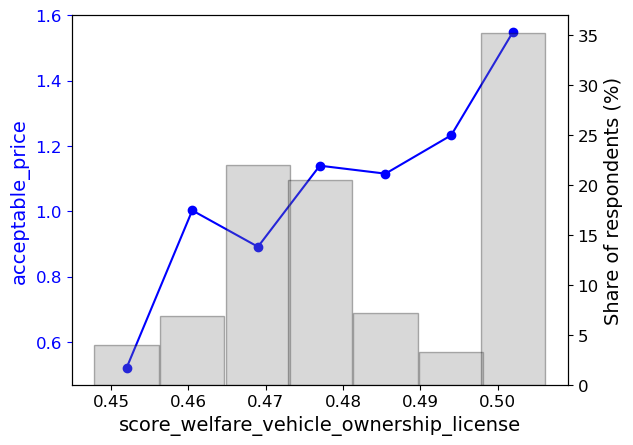

In [ ]:
plot_mobility_loss("score_welfare_vehicle_ownership_license","acceptable_price", df_reg)
    

<ipython-input-94-b9aeb33eacd6>:21: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  df_reg.groupby('bin').apply(lambda g: pd.Series({
<ipython-input-94-b9aeb33eacd6>:21: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  df_reg.groupby('bin').apply(lambda g: pd.Series({


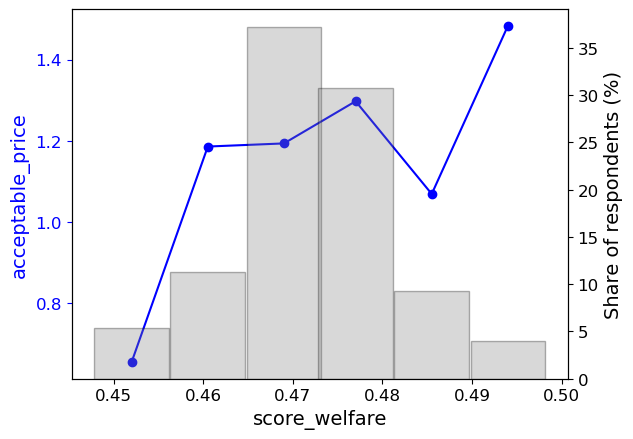

In [ ]:
plot_mobility_loss("score_welfare","acceptable_price", df_reg)

<ipython-input-94-b9aeb33eacd6>:21: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  df_reg.groupby('bin').apply(lambda g: pd.Series({
<ipython-input-94-b9aeb33eacd6>:21: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  df_reg.groupby('bin').apply(lambda g: pd.Series({


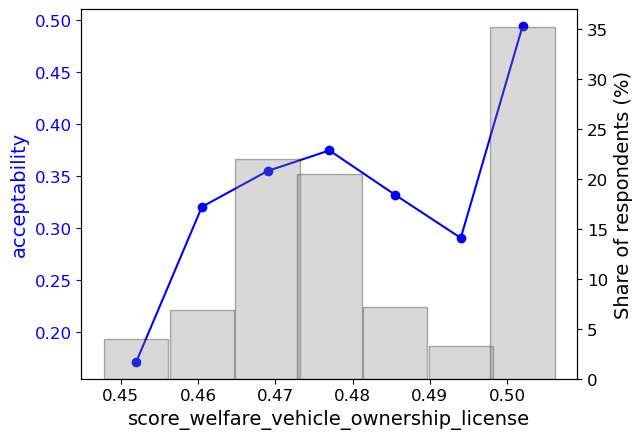

In [ ]:
plot_mobility_loss("score_welfare_vehicle_ownership_license","acceptability", df_reg)

In [ ]:
utility_init

{'LOW': 0       176.950775
 1       176.900681
 2       176.953285
 3       176.949586
 4       176.952015
            ...    
 2144    176.943597
 2145    176.953035
 2146    176.953579
 2147    176.677283
 2148    176.950492
 Length: 2149, dtype: float64,
 'MED': 0       315.698609
 1       315.698681
 2       315.699283
 3       315.698147
 4       315.696657
            ...    
 2144    315.697132
 2145    315.698352
 2146    315.699000
 2147    315.685392
 2148    315.701019
 Length: 2149, dtype: float64,
 'HIGH': 0       454.692656
 1       454.752327
 2       454.660037
 3       454.698199
 4       454.738859
            ...    
 2144    454.731920
 2145    454.667956
 2146    454.643234
 2147    454.748802
 2148    454.634231
 Length: 2149, dtype: float64}

In [ ]:
utility_tax

{'LOW': 0       175.821982
 1       175.482647
 2       175.907189
 3       175.828695
 4       175.712952
            ...    
 2144    176.280657
 2145    176.164924
 2146    176.391432
 2147    175.742907
 2148    176.296544
 Length: 2149, dtype: float64,
 'MED': 0       314.002074
 1       313.441124
 2       314.170365
 3       314.003204
 4       313.885370
            ...    
 2144    314.936433
 2145    314.572250
 2146    315.054118
 2147    314.589752
 2148    314.879209
 Length: 2149, dtype: float64,
 'HIGH': 0       452.523306
 1       451.848787
 2       452.731925
 3       452.524015
 4       452.583048
            ...    
 2144    454.082423
 2145    453.321616
 2146    454.030301
 2147    453.985558
 2148    453.783556
 Length: 2149, dtype: float64}

KeyError: 'score_welfare_LOW'

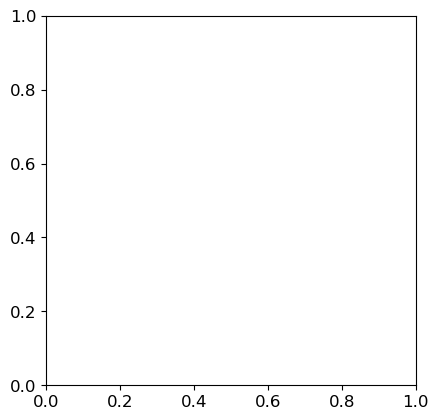

In [ ]:
gdf.plot("score_welfare_LOW")

<Axes: >

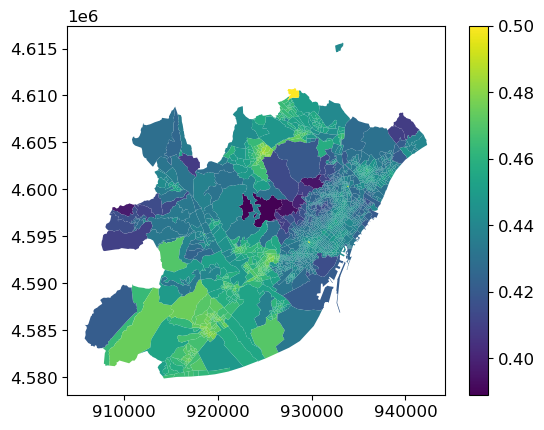

In [ ]:
gdf.plot("score_welfare_low", legend = True)

<Axes: >

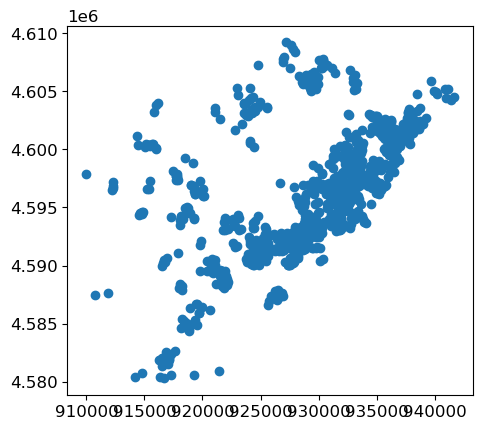

In [ ]:
df_reg.plot()

<Axes: >

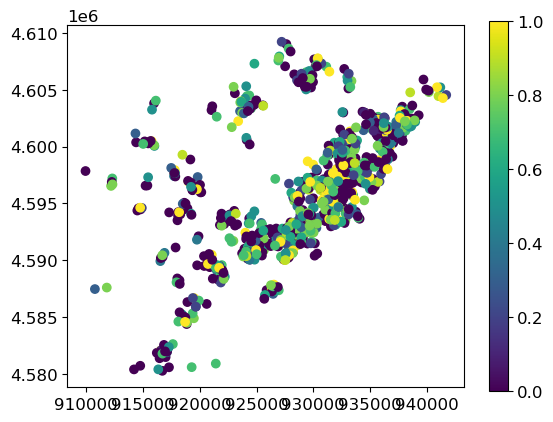

In [ ]:
df_reg.plot("acceptability", legend = True)

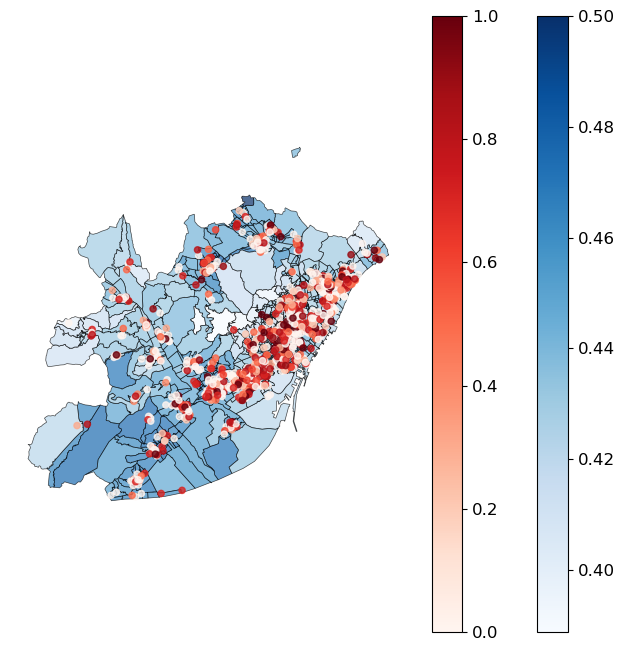

In [ ]:
fig, ax = plt.subplots(figsize=(8, 8))

# First layer: polygons
gdf.plot(
    column="score_welfare_low",
    cmap="Blues",
    linewidth=0.5,
    edgecolor="black",
    alpha=0.7,
    legend=True,
    ax=ax
)

# Second layer: points
df_reg.plot(
    column="acceptability",
    cmap="Reds",
    markersize=20,
    alpha=0.8,
    legend=True,
    ax=ax
)

ax.set_axis_off()
plt.show()

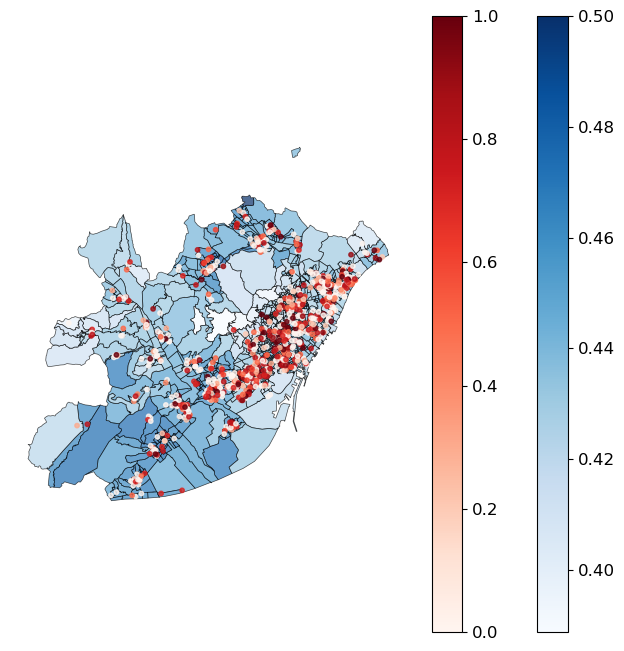

In [ ]:
fig, ax = plt.subplots(figsize=(8, 8))

# First layer: polygons
gdf.plot(
    column="score_welfare_low",
    cmap="Blues",
    linewidth=0.5,
    edgecolor="black",
    alpha=0.7,
    legend=True,
    ax=ax
)

# Second layer: points
df_reg.plot(
    column="acceptability",
    cmap="Reds",
    markersize=10,
    alpha=0.8,
    legend=True,
    ax=ax
)

ax.set_axis_off()
plt.show()

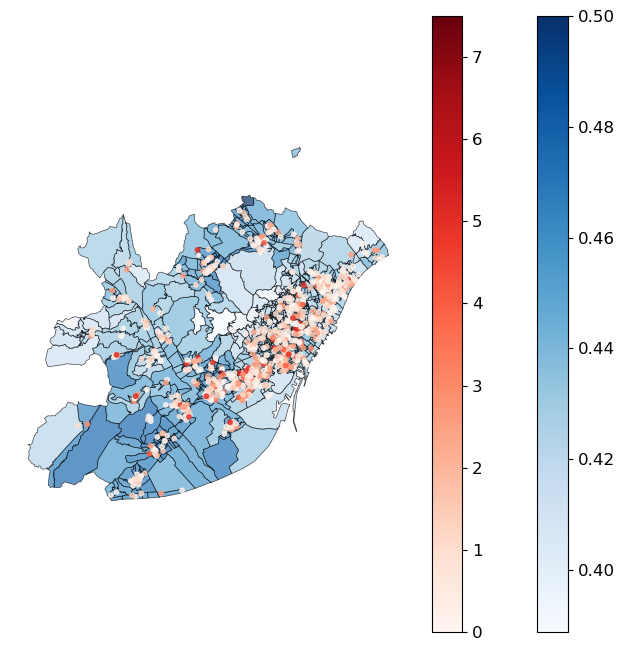

In [ ]:
fig, ax = plt.subplots(figsize=(8, 8))

# First layer: polygons
gdf.plot(
    column="score_welfare_low",
    cmap="Blues",
    linewidth=0.5,
    edgecolor="black",
    alpha=0.7,
    legend=True,
    ax=ax
)

# Second layer: points
df_reg.plot(
    column="acceptable_price",
    cmap="Reds",
    markersize=10,
    alpha=0.8,
    legend=True,
    ax=ax
)

ax.set_axis_off()
plt.show()

SignificanceResult(statistic=0.6035851309092074, pvalue=3.229002034877782e-98)


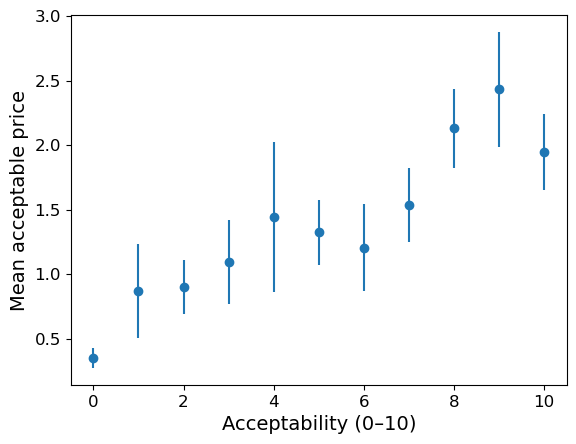

c:\Users\1738037\OneDrive - UAB\1- CLIMGROW Charlotte\1- PSC cities\code_barcelona\plotting_tools.py:288: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  df_reg.groupby('bin').apply(lambda g: pd.Series({
c:\Users\1738037\OneDrive - UAB\1- CLIMGROW Charlotte\1- PSC cities\code_barcelona\plotting_tools.py:288: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  df_reg.groupby('bin').apply(lambda g: pd.Series({


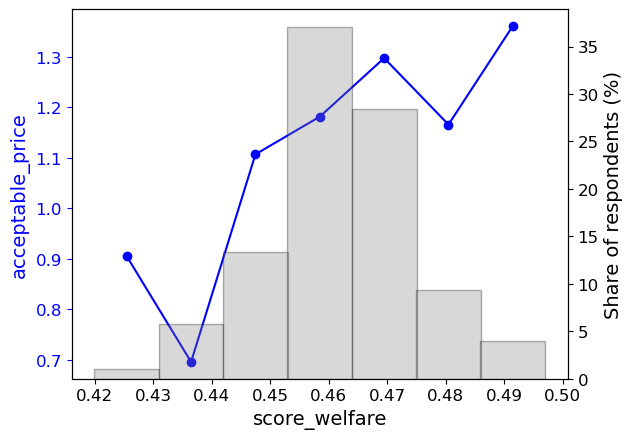

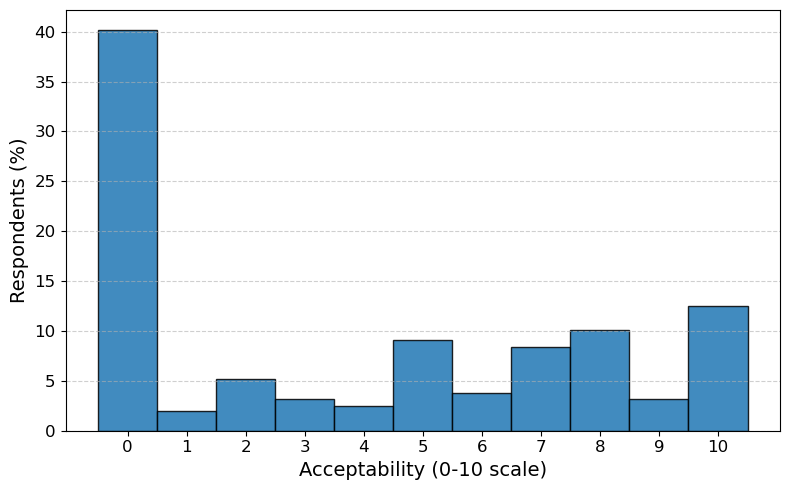

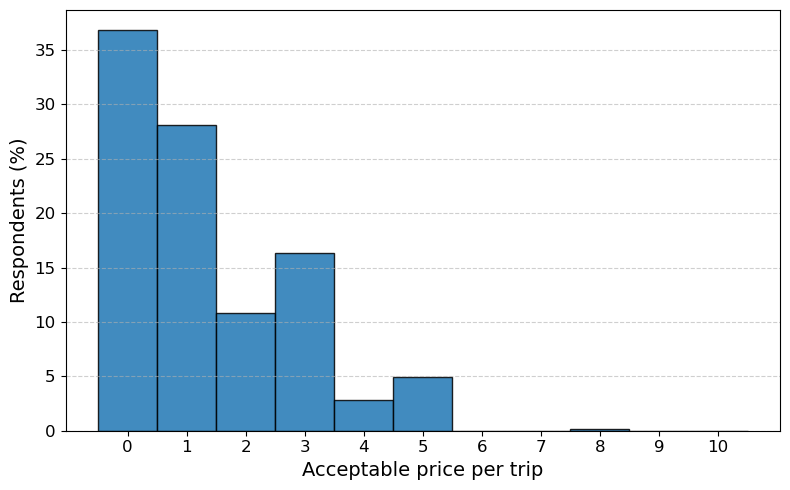

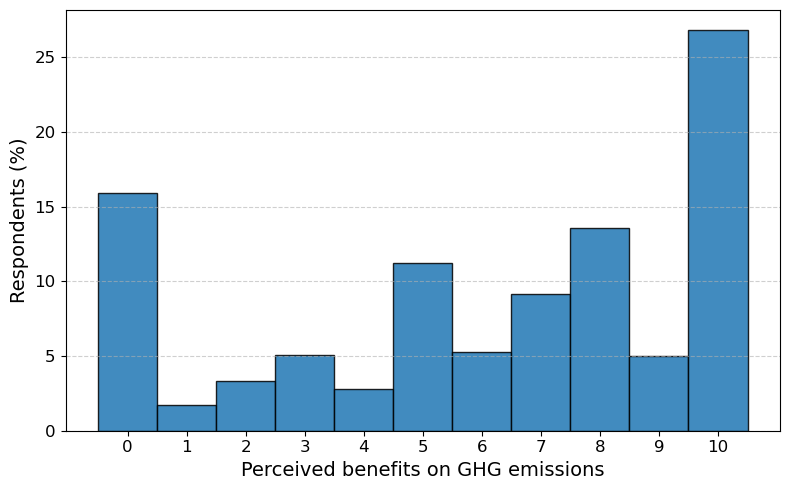

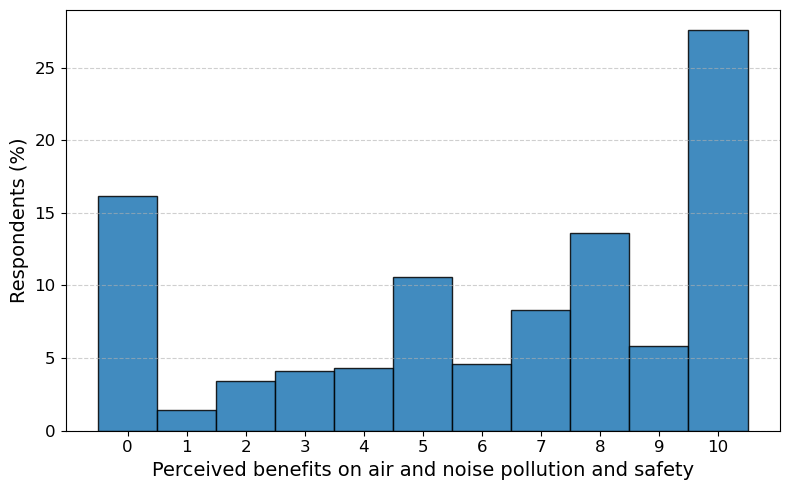

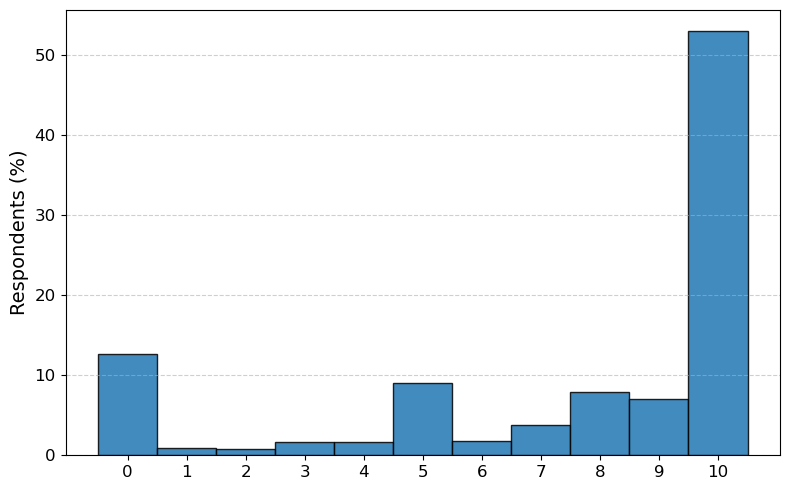

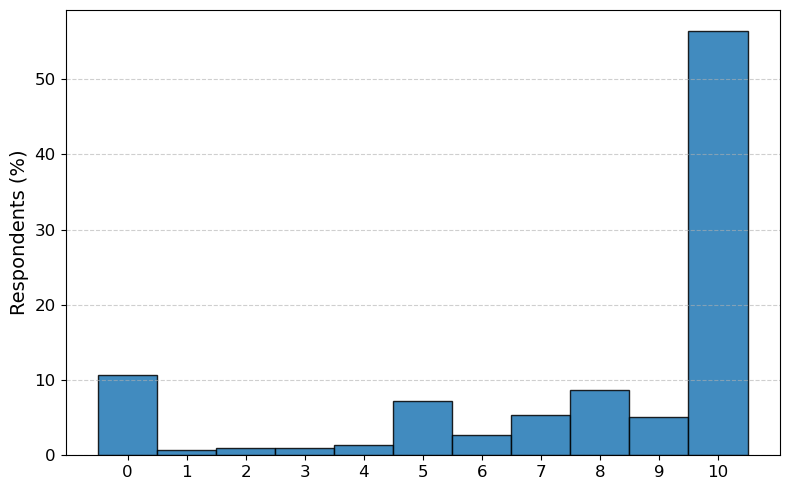

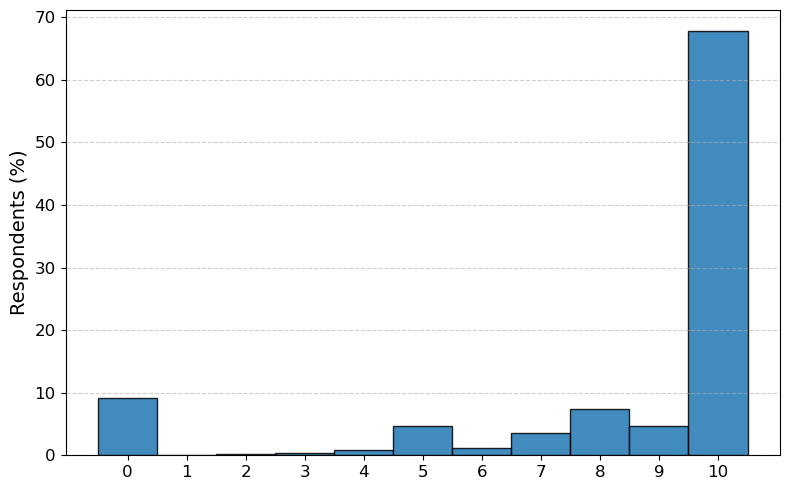

                             WLS Regression Results                            
Dep. Variable:                       y   R-squared:                       0.418
Model:                             WLS   Adj. R-squared:                  0.415
Method:                  Least Squares   F-statistic:                     136.5
Date:              jeu., 12 févr. 2026   Prob (F-statistic):          4.71e-109
Time:                         10:43:55   Log-Likelihood:                -263.60
No. Observations:                  955   AIC:                             539.2
Df Residuals:                      949   BIC:                             568.4
Df Model:                            5                                         
Covariance Type:             nonrobust                                         
                      coef    std err          t      P>|t|      [0.025      0.975]
-----------------------------------------------------------------------------------
const               0.4909      

In [ ]:
BETA_OPINION, BETA_PRICE, INITIAL_OPINION, INITIAL_PRICE, INITIAL_CC, INITIAL_WELFARE, INITIAL_QOL, INITIAL_KNOWLEDGE = import_opinion_parameters2(path_data, scenario, expected_welfare_loss)

c:\Users\1738037\AppData\Local\anaconda3\envs\geo_env\Lib\site-packages\shapely\io.py:353: RuntimeWarning: divide by zero encountered in from_wkb
  return lib.from_wkb(geometry, invalid_handler, **kwargs)
c:\Users\1738037\AppData\Local\anaconda3\envs\geo_env\Lib\site-packages\shapely\io.py:353: RuntimeWarning: overflow encountered in from_wkb
  return lib.from_wkb(geometry, invalid_handler, **kwargs)
c:\Users\1738037\AppData\Local\anaconda3\envs\geo_env\Lib\site-packages\shapely\io.py:353: RuntimeWarning: invalid value encountered in from_wkb
  return lib.from_wkb(geometry, invalid_handler, **kwargs)
<ipython-input-117-d9c07778baf5>:62: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True

CBD coordinates: (929792.741, 4594324.262)


c:\Users\1738037\AppData\Local\anaconda3\envs\geo_env\Lib\site-packages\shapely\constructive.py:375: RuntimeWarning: divide by zero encountered in centroid
  return lib.centroid(geometry, **kwargs)
c:\Users\1738037\AppData\Local\anaconda3\envs\geo_env\Lib\site-packages\shapely\constructive.py:375: RuntimeWarning: overflow encountered in centroid
  return lib.centroid(geometry, **kwargs)
c:\Users\1738037\AppData\Local\anaconda3\envs\geo_env\Lib\site-packages\shapely\constructive.py:375: RuntimeWarning: invalid value encountered in centroid
  return lib.centroid(geometry, **kwargs)


                             OLS Regression Results                            
Dep. Variable:              ln_density   R-squared:                       0.111
Model:                             OLS   Adj. R-squared:                  0.076
Method:                  Least Squares   F-statistic:                     3.193
Date:              jeu., 12 févr. 2026   Prob (F-statistic):           7.06e-19
Time:                         10:46:06   Log-Likelihood:                -5819.8
No. Observations:                 2149   AIC:                         1.180e+04
Df Residuals:                     2067   BIC:                         1.227e+04
Df Model:                           81                                         
Covariance Type:             nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const         35.9008     11.405      3.14

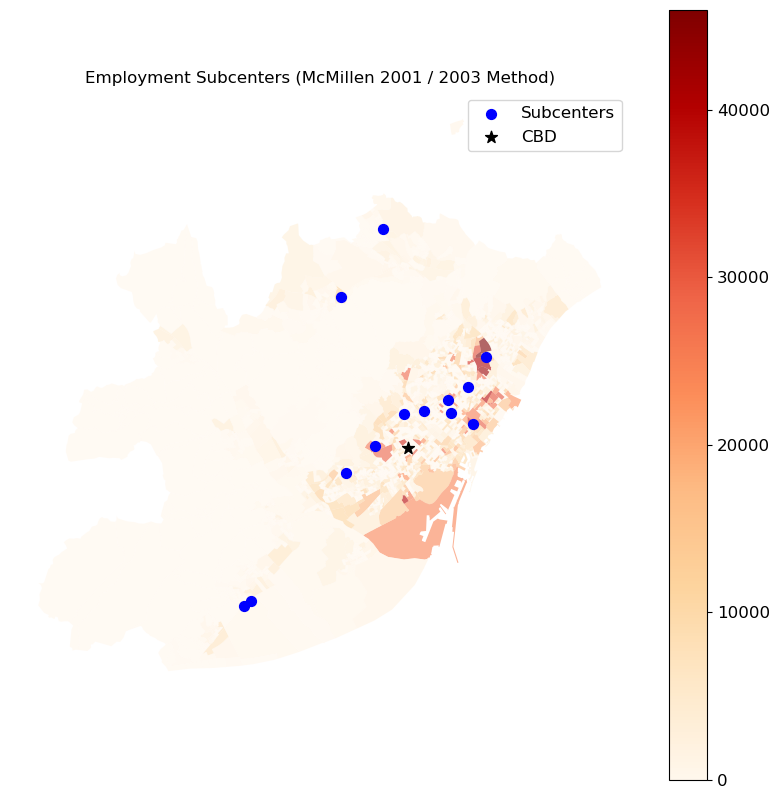

   jobs_buffered  share_total
0    9842.560764     0.006643
1   48932.714593     0.033024
2   13004.633998     0.008777
3   94075.026744     0.063490
4  367703.884334     0.248159
5   26866.356545     0.018132
6   83152.418660     0.056119
Total share of jobs in subcenters: 43.43%
   center_id     total_jobs  jobs_buffered  share_total
0         -1  527975.700471   1.481724e+06     0.356325
1          0   74380.468912   9.842561e+03     0.050199
2          1  220287.912566   4.893271e+04     0.148670
3          2   83209.597707   1.300463e+04     0.056157
4          3   90812.671531   9.407503e+04     0.061289
5          4  214831.287066   3.677039e+05     0.144987
6          5   49044.815655   2.686636e+04     0.033100
7          6  221181.546091   8.315242e+04     0.149273


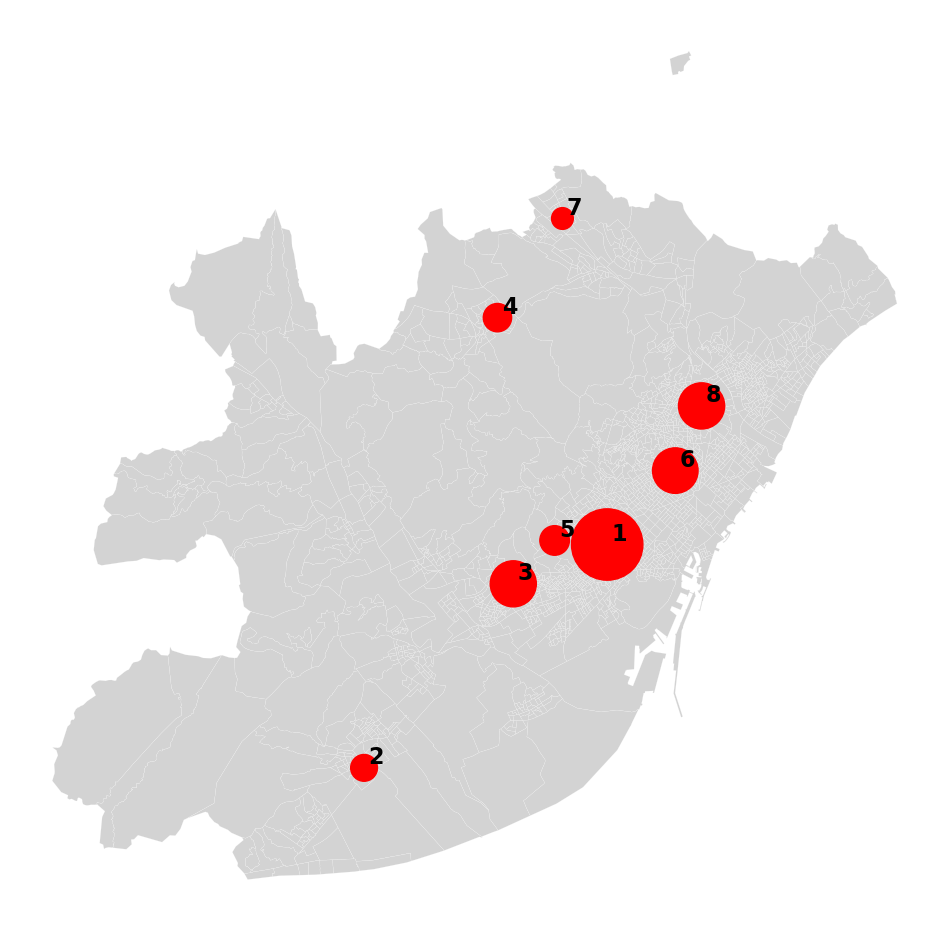

<ipython-input-117-d9c07778baf5>:340: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  comparison["jobs_in_centers"].fillna(0, inplace=True)


   code_city  total_jobs  jobs_in_centers  share_in_centers
0      08015     49830.0     0.000000e+00          0.000000
1      08019    969777.0     1.054801e+06          1.087674
2      08169     50109.0     0.000000e+00          0.000000
3      08020         NaN     0.000000e+00               NaN
4      08054         NaN     0.000000e+00               NaN
5      08056     13416.0     0.000000e+00          0.000000
6      08068         NaN     0.000000e+00               NaN
7      08072         NaN     0.000000e+00               NaN
8      08073     38880.0     0.000000e+00          0.000000
9      08077     19725.0     2.202879e+05         11.167955
10     08089     14094.0     7.438047e+04          5.277456
11     08101     85407.0     0.000000e+00          0.000000
12     08123      7635.0     0.000000e+00          0.000000
13     08125     19581.0     0.000000e+00          0.000000
14     08126         NaN     0.000000e+00               NaN
15     08157         NaN     0.000000e+0

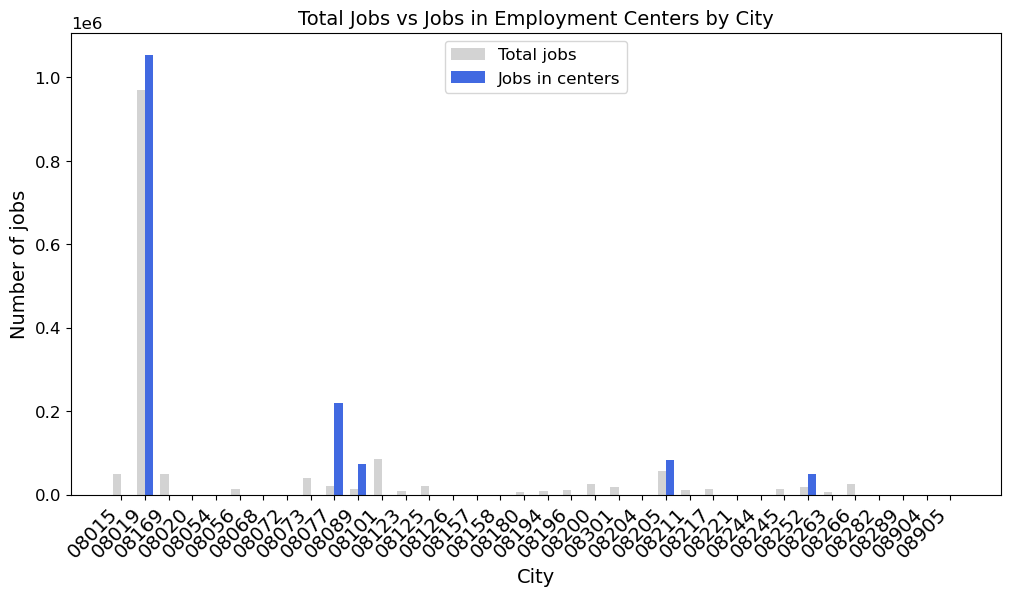

In [ ]:
import geopandas as gpd  # type: ignore
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import statsmodels.api as sm
from statsmodels.nonparametric.smoothers_lowess import lowess
from sklearn.neighbors import KernelDensity
from sklearn.cluster import DBSCAN
from shapely.geometry import Point

from import_data import *
from plotting_tools import *

path_data = "../data_barcelona/"
center = "0801901025"

# ============================================================
# STEP 1: Import employment and land use data (unchanged)
# ============================================================

gdf = import_data(path_data, center, option="SECTION")

jobs = pd.read_csv(path_data + 'employment_distrib.csv')
jobs = jobs.loc[:, ["SPERSONAS", "ID_LUGAR_TRAB_N3"]]
jobs["code_city"] = jobs["ID_LUGAR_TRAB_N3"].str[:5]
jobs = jobs.loc[:, ["SPERSONAS", "code_city"]]

land_cover = gpd.read_file(path_data + "cobertes-sol-v1r0-2023.gpkg", layer="cobertes_sol")
categories = gpd.read_file(path_data + "cobertes-sol-v1r0-2023.gpkg", layer="cobertes_sol_categories")
gdf = import_data(path_data, center, option="SECTION")
land_cover = land_cover.to_crs(gdf.crs)

intersection = gpd.overlay(land_cover, gdf, how='intersection')
intersection['area_lc'] = intersection.geometry.area

grouped = intersection.groupby(['ID', 'nivell_2'])['area_lc'].sum().reset_index()
pivot = grouped.pivot(index='ID', columns='nivell_2', values='area_lc').fillna(0).reset_index()

land_use = gdf.loc[:, ['ID', 'geometry', 'area']].merge(pivot, on="ID", how="left")
gdf = gdf.merge(land_use.loc[:, ["ID", 347]], on="ID", how="left")

gdf["code_city"] = gdf["ID"].str[:5]
gdf = gdf.merge(jobs, on="code_city", how="left")

size_city = gdf.loc[:, ["code_city", 347]].groupby("code_city").sum()
size_city.columns = ["area_comm"]
gdf = gdf.merge(size_city, on="code_city", how="left")

gdf["density_employment"] = gdf["SPERSONAS"] / gdf["area_comm"]
gdf["employment"] = gdf["SPERSONAS"] * (gdf[347] / gdf["area_comm"])
gdf = gdf.drop(columns=["SPERSONAS", "area_comm"])
gdf["density_employment"] = gdf["employment"] / gdf["area"]
gdf.loc[np.isnan(gdf.density_employment), "density_employment"] = 0

# ============================================================
# STEP 2: Find CBD (unchanged)
# ============================================================

gdf["centroid"] = gdf.geometry.centroid
gdf["x"] = gdf.centroid.x
gdf["y"] = gdf.centroid.y
gdf["employment"].fillna(0, inplace=True)

x_cbd = np.average(gdf["x"], weights=gdf["employment"])
y_cbd = np.average(gdf["y"], weights=gdf["employment"])
CBD = Point(x_cbd, y_cbd)
print(f"CBD coordinates: ({x_cbd:.3f}, {y_cbd:.3f})")

gdf["dist_cbd"] = gdf.centroid.distance(CBD)

# ============================================================
# STEP 3: McMillen Method (adapted)
# ============================================================

# --- Step 3.1: Compute density and log density
gdf["area_km2"] = gdf.geometry.area / 1e6
gdf["density"] = gdf["employment"] / gdf["area_km2"]
gdf["ln_density"] = np.log(gdf["density"] + 1)
gdf["dist_km"] = gdf["dist_cbd"] / 1000

# --- Step 3.2: Estimate monocentric gradient with LOESS (McMillen 2003)
# Replaces the simple OLS ln(density) = α + β * distance
smoothed = lowess(gdf["ln_density"], gdf["dist_km"], frac=0.3, return_sorted=False)
gdf["fitted_ln_density"] = smoothed
gdf["residual"] = gdf["ln_density"] - gdf["fitted_ln_density"]

# --- Step 3.3: Spatial smoothing of residuals (Gaussian kernel)
coords = np.vstack([gdf["x"], gdf["y"]]).T
# Only positive residuals contribute to local employment "excess"
positive_weights = gdf["residual"].clip(lower=0)









# Parameters (tune c between 2 and 4; see recommendations below)
c = 2.5   # multiplier for sqrt(area)
eps = 1e-9

# Prepare arrays
coords = np.vstack([gdf["x"].values, gdf["y"].values]).T   # (n,2)
pos_w = gdf["residual"].clip(lower=0).values               # (n,)
areas = gdf["area"].values                                 # (n,) in m^2

# compute adaptive bandwidth per *target* cell (h_i)
h = c * np.sqrt(areas)            # (n,) in meters

# pairwise distances (n x n). If n large (> ~5000) consider block / KD-tree approach
from scipy.spatial.distance import cdist
D = cdist(coords, coords)         # D[i,j] = dist from target i to source j

# Gaussian kernel: K(d, h_i) = exp(-0.5 * (d / h_i)^2)
# For each target i, compute weights across all j using h_i
H = h[:, None]                    # (n,1)
K = np.exp(-0.5 * (D / (H + eps))**2)    # (n,n)  (broadcasting)

# weighted sum of positive residuals
num = (K * pos_w[None, :]).sum(axis=1)   # (n,)
den = K.sum(axis=1) + eps                # (n,)
gdf["smoothed_resid_adaptive"] = num / den

# Now use this 'smoothed_resid_adaptive' for candidate detection
threshold = np.percentile(gdf["smoothed_resid_adaptive"], 85)   # try 85% or 90%
gdf["candidate"] = gdf["smoothed_resid_adaptive"] >= threshold


#BALLON
#weights = gdf["residual"].clip(lower=0).values  # only positive residuals

# Step 1: Compute location-specific bandwidths (distance to k-th nearest neighbor)
#k = 8 # adjust depending on tract density
#nbrs = NearestNeighbors(n_neighbors=k+1).fit(coords)  # include self
#distances, indices = nbrs.kneighbors(coords)
# Use distance to k-th neighbor as bandwidth for balloon
#h_x = distances[:, -1]
#gdf["bandwidth_balloon"] = h_x

# Step 2: Compute balloon KDE at each centroid
#def balloon_kde(coords, weights, h_x):
#    n = len(coords)
#    dens = np.zeros(n)
#    for i in range(n):
        # compute squared distance from estimation location i to all points
#        diff = coords - coords[i]
#        dist2 = np.sum(diff**2, axis=1)
#        # Gaussian kernel with location-specific bandwidth
#        kern = np.exp(-0.5 * dist2 / (h_x[i]**2))
#        dens[i] = np.sum(weights * kern / (2 * np.pi * h_x[i]**2))
#    return dens

##gdf["smoothed_resid_balloon"] = balloon_kde(coords, weights, h_x)
#gdf.plot("smoothed_resid_balloon")
## Step 3: Identify candidate subcenters (e.g., top 10% of balloon KDE)
#threshold = np.percentile(gdf["smoothed_resid_balloon"], 85)
#gdf["candidate"] = gdf["smoothed_resid_balloon"] >= threshold

#Option2
#kde = KernelDensity(kernel="gaussian", bandwidth=500).fit(coords, sample_weight=positive_weights)
#gdf["smoothed_resid"] = np.exp(kde.score_samples(coords))
#gdf.plot("smoothed_resid")


# --- Step 3.4: Identify candidate subcenters (top 5% smoothed residuals)
#threshold = np.percentile(gdf["smoothed_resid"], 85)
#gdf["candidate"] = gdf["smoothed_resid"] >= threshold
#gdf.plot("candidate")
#####

# --- Step 3.5: Cluster adjacent high-residual tracts (DBSCAN)
candidate_coords = np.vstack([gdf.loc[gdf["candidate"], "x"], gdf.loc[gdf["candidate"], "y"]]).T
clustering = DBSCAN(eps=500, min_samples=1).fit(candidate_coords)
gdf.loc[gdf["candidate"], "cluster"] = clustering.labels_

# --- Step 3.6: Extract subcenter centroids
subcenters = (
    gdf[gdf["candidate"] & (gdf["cluster"] != -1)]
    .groupby("cluster")[["x", "y", "smoothed_resid_adaptive"]]
    .mean()
    .reset_index()
)

# ============================================================
# STEP 4: Validation Regression (McMillen confirmatory step)
# ============================================================

for idx, row in subcenters.iterrows():
    gdf[f"dist_{idx}"] = gdf.centroid.distance(Point(row["x"], row["y"])) / 1000

X = sm.add_constant(gdf[[f"dist_{idx}" for idx in subcenters.index]])
y = gdf["ln_density"]
model = sm.OLS(y, X).fit()
print(model.summary())

# Keep only statistically significant subcenters
significant_idx = [subcenters.index[i] for i, p in enumerate(model.pvalues[1:]) if p < 0.1]
true_subcenters = subcenters.loc[significant_idx]


# ============================================================
# STEP 5: Plot results
# ============================================================

fig, ax = plt.subplots(figsize=(10, 10))
gdf.plot(ax=ax, column="density", cmap="OrRd", alpha=0.6, legend=True)
plt.scatter(true_subcenters["x"], true_subcenters["y"], c="blue", s=50, label="Subcenters")
plt.scatter(x_cbd, y_cbd, c="black", s=80, marker="*", label="CBD")
plt.legend()
plt.title("Employment Subcenters (McMillen 2001 / 2003 Method)")
plt.axis("off")
plt.show()




# ============================================================
# STEP 6: Dissolve adjacent subcenter tracts
# ============================================================

#gdf["subcenter"] = gdf.ID.isin(list(true_subcenters.ID))
#sub = gdf[gdf["subcenter"]].copy()
##sub["geometry"] = sub.buffer(0)  # fix geometries
#merged = sub.dissolve().explode(index_parts=True).buffer(0)
#merged = gpd.GeoDataFrame(geometry=merged, crs=gdf.crs).reset_index(drop=True)

# --- Identify tracts belonging to a subcenter (within 1 km of a cluster centroid)
buffer_radius = 1000  # meters
gdf["subcenter"] = False

for _, row in true_subcenters.iterrows():
    center_point = Point(row["x"], row["y"])
    within_buffer = gdf.centroid.distance(center_point) <= buffer_radius
    gdf.loc[within_buffer, "subcenter"] = True

# Proceed with dissolve etc.
sub = gdf[gdf["subcenter"]].copy()
sub["geometry"] = sub.buffer(0)
merged = sub.dissolve().explode(index_parts=True).buffer(0)
merged = gpd.GeoDataFrame(geometry=merged, crs=gdf.crs).reset_index(drop=True)



# Jobs per subcenter
def jobs_in_poly(poly):
    return gdf[gdf.centroid.within(poly)]["employment"].sum()

merged["jobs"] = merged.geometry.apply(jobs_in_poly)
merged["buffered_geom"] = merged.geometry.buffer(1000)  # 1 km buffer
merged["jobs_buffered"] = merged["buffered_geom"].apply(jobs_in_poly)

total_jobs = gdf["employment"].sum()
merged["share_total"] = merged["jobs_buffered"] / total_jobs
print(merged[["jobs_buffered", "share_total"]])
print(f"Total share of jobs in subcenters: {merged['share_total'].sum():.2%}")

# ============================================================
# STEP 7: Assign each tract to nearest center (subcenters + CBD)
# ============================================================

centers = merged.copy()
centers["centroid"] = centers.geometry.centroid
centers["center_id"] = range(len(centers))
centers = centers[["center_id", "centroid", "jobs_buffered"]].copy()

CBD_point = Point(x_cbd, y_cbd)
cbd_df = gpd.GeoDataFrame({
    "center_id": [-1],
    "jobs_buffered": [gdf["employment"].sum()],
    "geometry": [CBD_point]
}, crs=gdf.crs)

merged["center_id"] = merged.index
centers = pd.concat([merged, cbd_df], ignore_index=True)

def nearest_center(row, centers):
    distances = centers.centroid.distance(row.geometry.centroid)
    return centers.loc[distances.idxmin(), "center_id"]

gdf["center_id"] = gdf.apply(lambda row: nearest_center(row, centers), axis=1)

# ============================================================
# STEP 8: Aggregate jobs by assigned center
# ============================================================

allocation = (
    gdf.groupby("center_id", as_index=False)
       .agg(total_jobs=("employment", "sum"))
       .merge(centers[["center_id", "jobs_buffered"]], on="center_id", how="left")
)
allocation["share_total"] = allocation["total_jobs"] / total_jobs
print(allocation)

allocation_plot = allocation.merge(centers[["geometry", "center_id"]], on="center_id")
allocation_plot["total"] = allocation_plot["share_total"] * total_jobs

allocation_plot = gpd.GeoDataFrame(allocation_plot, geometry=allocation_plot["geometry"], crs=gdf.crs)
allocation_plot["geometry"] = allocation_plot["geometry"].centroid

# Reset center_id to start at 1
allocation_plot = allocation_plot.reset_index(drop=True)
allocation_plot['center_id'] = allocation_plot.index + 1  # IDs start at 1

# Plot map with bold, black, larger numbers
fig, ax = plt.subplots(figsize=(12, 12))
gdf.plot(ax=ax, color='lightgrey', edgecolor='white', linewidth=0.1)
allocation_plot.plot(ax=ax, markersize=allocation_plot['total']/200, color='red', label='Cluster Centroids')

# Annotate each subcenter
for idx, row in allocation_plot.iterrows():
    ax.annotate(
        str(row['center_id']),
        xy=(row.geometry.x, row.geometry.y),
        xytext=(3, 3),  # offset
        textcoords="offset points",
        fontsize=16, 
        color='black',
        fontweight='bold'
    )

plt.axis("off")
plt.show()


# ============================================================
# STEP 9: Compare predicted vs actual jobs per municipality
# ============================================================

total_jobs_city = gdf.merge(jobs, on="code_city", how="left")
total_jobs_city = total_jobs_city.loc[:,["code_city", "SPERSONAS"]].drop_duplicates()
total_jobs_city = total_jobs_city.rename(columns={"SPERSONAS": "total_jobs"})

centers_in_city = gpd.sjoin(allocation_plot, gdf[["code_city", "geometry"]], how="left", predicate="within")
jobs_centers_city = centers_in_city.groupby("code_city")["total"].sum().reset_index()
jobs_centers_city = jobs_centers_city.rename(columns={"total": "jobs_in_centers"})

comparison = total_jobs_city.merge(jobs_centers_city, on="code_city", how="left")
comparison["jobs_in_centers"].fillna(0, inplace=True)
comparison["share_in_centers"] = comparison["jobs_in_centers"] / comparison["total_jobs"]

print(comparison)

# Plot total jobs vs jobs in centers per city
cities = comparison["code_city"]
total = comparison["total_jobs"]
in_centers = comparison["jobs_in_centers"]

x = np.arange(len(cities))  # the label locations
width = 0.35  # bar width

plt.rcParams.update({'font.size': 14})
fig, ax = plt.subplots(figsize=(12, 6))
rects1 = ax.bar(x - width/2, total, width, label="Total jobs", color="lightgrey")
rects2 = ax.bar(x + width/2, in_centers, width, label="Jobs in centers", color="royalblue")

# Add labels and formatting
ax.set_ylabel("Number of jobs", fontsize=14)
ax.set_xlabel("City", fontsize=14)
ax.set_title("Total Jobs vs Jobs in Employment Centers by City", fontsize=14)
ax.set_xticks(x)
ax.set_xticklabels(cities, rotation=45, ha="right", fontsize=14)
ax.legend(fontsize=12)




allocation_plot["employment_cluster"] = allocation_plot["total"] * np.nansum(gdf["pop"]) / np.nansum(allocation_plot["total"])

In [ ]:
print("done")

done
